# Advanced Data Analysis and Fold-Local Feature Engineering

This notebook harmonizes cross-machine semantics, constructs causal static prefixes and masked temporal tensors, and performs development-only dependency, shift, anomaly, and interpretability analyses. The scientific hypothesis is that complementary sensor dynamics are informative while design/schedule proxies must not enter the primary pool. No global outcome-selected feature set is frozen for modeling: Notebook 03 must learn cleaning, imputation, scaling, feature selection, calibration, and thresholds inside each training fold.


In [1]:
# Reproducible scientific runtime
from __future__ import annotations
from collections import defaultdict
from collections.abc import Mapping, Sequence
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import gc
import json
import math
import os
import random
import re
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import Normalize
from matplotlib.container import BarContainer
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import Markdown, display
from scipy import stats
from scipy.spatial.distance import jensenshannon
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import balanced_accuracy_score, log_loss, normalized_mutual_info_score, r2_score, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import RobustScaler
from xgboost import DMatrix, XGBClassifier, XGBRegressor
import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="IProgress not found.*")
    from umap import UMAP
CWD = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (CWD, *CWD.parents)
    if (path / "notebooks").is_dir() and (path / "dataset").is_dir())

FONT_FAMILY = ("Times New Roman" if "Times New Roman" in font_manager.get_font_names()
               else "DejaVu Serif")
for folder in ("figures/generated", "dataset/predictions", "dataset/protocols"):
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)


In [2]:
FIGURE_DPI = 350
SINGLE_COLUMN_MM = 88.0
DOUBLE_COLUMN_MM = 178.0
FONT_SIZE = 18
TITLE_SIZE = 20
FIGURE_PALETTE = {
    "baseline": "#2F6B8F", "baseline_secondary": "#6E7378",
    "sota": "#6D5A8D", "sota_secondary": "#4A8C8A",
    "proposed": "#4F7F3A", "validation": "#C77C2B",
    "error": "#B45A55", "grid": "#E7EAED",
    "black": "#222222", "white": "#FFFFFF",
    "lab": "#2F6B8F", "external": "#B45A55",
}

def configure_figure_style(notebook_id: str, tables_dir: Path) -> Path:
    """Configure figure typography and raster resolution."""
    font_path = Path(font_manager.findfont(FONT_FAMILY, fallback_to_default=False))
    mpl.rcParams.update({
        "font.family": FONT_FAMILY, "font.size": FONT_SIZE,
        "axes.titlesize": TITLE_SIZE, "axes.labelsize": 19,
        "xtick.labelsize": FONT_SIZE, "ytick.labelsize": FONT_SIZE,
        "legend.fontsize": FONT_SIZE, "figure.titlesize": TITLE_SIZE,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.unicode_minus": True, "figure.dpi": FIGURE_DPI,
        "savefig.dpi": FIGURE_DPI, "figure.facecolor": "white",
        "savefig.facecolor": "white", "axes.facecolor": "white",
    })
    assert float(mpl.rcParams["figure.dpi"]) == FIGURE_DPI
    assert float(mpl.rcParams["savefig.dpi"]) == FIGURE_DPI
    return font_path


In [3]:
def figure_subplots(
    nrows: int = 1, ncols: int = 1, *, span: str = "double",
    labels=None, legend_items: int = 0, annotation_rows: int = 0,
    square_panel: bool = False, square_axes: bool | None = None,
    height_mm: float | None = None, **kwargs,
):
    """Create one panel or two vertically aligned figure panels."""
    assert span in {"single", "double"}
    assert ncols == 1 and nrows in {1, 2}
    width_mm = SINGLE_COLUMN_MM if span == "single" else DOUBLE_COLUMN_MM
    use_square = nrows == 2 if square_axes is None else bool(square_axes)
    if height_mm is None:
        if nrows == 2:
            height_mm = 330.0 if use_square else 255.0
        elif square_panel:
            height_mm = 170.0
        else:
            height_mm = 150.0
    assert 70.0 <= float(height_mm) <= 385.0
    kwargs.pop("figsize", None)
    kwargs.pop("dpi", None)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(width_mm / 25.4, height_mm / 25.4),
        dpi=FIGURE_DPI, layout="constrained", **kwargs,
    )
    axis_array = np.atleast_1d(axes)
    if use_square or square_panel:
        for axis in axis_array:
            axis.set_box_aspect(1)
    return fig, axes


In [4]:
def scientific_number(value: float, digits: int = 3) -> str:
    """Format one finite number with a scientific minus and no negative zero."""
    rounded = round(float(value), digits)
    if abs(rounded) < 0.5 * 10 ** (-digits):
        rounded = 0.0
    return f"{rounded:.{digits}f}".replace("-", "−")

def annotate_bar_values(axis, digits: int = 1, padding_points: float = 2.0) -> None:
    """Place complete numeric labels above visible bars."""
    for container in axis.containers:
        if not isinstance(container, BarContainer):
            continue
        labels = [scientific_number(bar.get_height(), digits) for bar in container]
        axis.bar_label(container, labels=labels, padding=padding_points, fontsize=FONT_SIZE)


In [5]:
def save_show_figure(fig, output_path: Path, *, span: str = "double") -> Path:
    """Save and display one exact-width, exact-DPI Matplotlib canvas."""
    expected_mm = SINGLE_COLUMN_MM if span == "single" else DOUBLE_COLUMN_MM
    fig.savefig(output_path, dpi=FIGURE_DPI, facecolor="white")
    with Image.open(output_path) as image:
        dpi = image.info.get("dpi", (0.0, 0.0))
        width_mm = image.width / dpi[0] * 25.4
        assert abs(dpi[0] - FIGURE_DPI) < 0.1
        assert abs(dpi[1] - FIGURE_DPI) < 0.1
        assert abs(width_mm - expected_mm) < 0.2
    plt.show()
    plt.close(fig)
    return output_path


In [6]:
def display_grouped_tables(
    dataframe: pd.DataFrame, identifier_columns: Sequence[str],
    column_groups: Mapping[str, Sequence[str]], digits: int = 4,
) -> None:
    """Display complete, non-truncated scientific result tables."""
    identifiers = list(identifier_columns)
    grouped = [column for columns in column_groups.values() for column in columns]
    assert len(grouped) == len(set(grouped))
    assert set(grouped) == set(dataframe.columns) - set(identifiers)
    assert dataframe[identifiers].notna().all().all()
    with pd.option_context(
        "display.max_rows", None, "display.max_columns", None,
        "display.max_colwidth", None, "display.width", None,
        "display.expand_frame_repr", False,
    ):
        for group_name, metric_columns in column_groups.items():
            table = dataframe.loc[:, identifiers + list(metric_columns)].copy()
            for column in metric_columns:
                if pd.api.types.is_integer_dtype(table[column]):
                    table[column] = table[column].map(lambda value: str(int(value)))
                elif pd.api.types.is_numeric_dtype(table[column]):
                    table[column] = table[column].map(
                        lambda value: "NA" if pd.isna(value)
                        else scientific_number(value, digits)
                    )
            rendered = table.astype("string")
            assert not rendered.apply(
                lambda series: series.str.contains("...", regex=False, na=False).any()
                or series.str.contains("…", regex=False, na=False).any()
            ).any()
            display(Markdown(f"#### {group_name}"))
            display(table.reset_index(drop=True))


In [7]:
def typographic_text(value: object, digits: int = 3, signed: bool = False) -> str:
    """Format finite scientific values with a true minus sign."""
    number = float(value)
    if not np.isfinite(number):
        return "NA"
    rounded = round(number, digits)
    if abs(rounded) < 0.5 * 10 ** (-digits):
        rounded = 0.0
    magnitude = f"{abs(rounded):.{digits}f}"
    if rounded < 0:
        return "−" + magnitude
    return "+" + magnitude if signed and rounded > 0 else magnitude

def legend_below(axis, ncol: int = 2, y: float = -0.18, **kwargs):
    """Place a complete legend below its axis without covering observations."""
    existing = axis.get_legend()
    if existing is not None:
        existing.remove()
    return axis.legend(
        loc="upper center", bbox_to_anchor=(0.5, y),
        ncol=max(1, int(ncol)), frameon=False, borderaxespad=0.0,
        **kwargs,
    )


In [8]:
def annotate_heatmap_values(image, digits: int = 2) -> None:
    """Annotate finite matrix cells using luminance-aware contrast."""
    values = np.asarray(image.get_array(), dtype=float)
    assert values.ndim == 2
    for row_index in range(values.shape[0]):
        for column_index in range(values.shape[1]):
            value = values[row_index, column_index]
            if np.isfinite(value):
                red, green, blue, _ = image.cmap(image.norm(value))
                luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
                label = typographic_text(value, digits=digits)
                color = PALETTE["black"] if luminance >= 0.52 else PALETTE["white"]
            else:
                label, color = "NA", PALETTE["black"]
            image.axes.text(
                column_index, row_index, label, ha="center", va="center",
                fontsize=FONT_SIZE, color=color,
            )

def compact_label(name: object) -> str:
    """Wrap a long feature name without reducing font size."""
    words = str(name).replace("__", " · ").replace("_", " ").split()
    lines, current = [], []
    for word in words:
        if len(" ".join(current + [word])) > 16 and current:
            lines.append(" ".join(current)); current = [word]
        else:
            current.append(word)
    if current:
        lines.append(" ".join(current))
    return "\n".join(lines[:3])


In [9]:
def plot_scientific_matrix(
    matrix: np.ndarray, labels: Sequence[str], title: str,
    colorbar_label: str, output_name: str, *, vmin: float, vmax: float,
    cmap: str, column_labels: Sequence[str] | None = None,
) -> None:
    """Render one square matrix without unreadable dense annotations."""
    columns = list(labels) if column_labels is None else list(column_labels)
    fig, axis = figure_subplots(
        1, 1, span="double", labels=list(labels) + columns,
        annotation_rows=max(len(labels), len(columns)),
        square_panel=True, height_mm=178.0,
    )
    color_map = mpl.colormaps[cmap].copy()
    color_map.set_bad("#D9D9D9")
    image = axis.imshow(matrix, vmin=vmin, vmax=vmax, cmap=color_map, aspect="equal")
    axis.set_xticks(np.arange(len(columns)), columns, rotation=45, ha="right")
    axis.set_yticks(np.arange(len(labels)), labels)
    axis.set_xlabel("Feature code")
    axis.set_ylabel("Feature code")
    axis.set_title(title)
    if max(matrix.shape) <= 8:
        annotate_heatmap_values(image, digits=2)
    colorbar = fig.colorbar(image, ax=axis, fraction=0.046, pad=0.025)
    colorbar.set_label(colorbar_label)
    _ = save_show_figure(fig, FIGURES / output_name, span="double")


In [10]:
SEED = 20260807
CPU_COUNT = os.cpu_count() or 1
N_JOBS = max(1, min(CPU_COUNT - 1, 8))
for variable in [
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
]:
    os.environ[variable] = str(N_JOBS)
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
RAW = PROJECT_ROOT / "dataset" / "raw"
PROCESSED = PROJECT_ROOT / "dataset" / "processed"
UNIFIED = PROJECT_ROOT / "dataset" / "unified"
TABLES = PROJECT_ROOT / "artifacts"
FIGURES = PROJECT_ROOT / "figures" / "generated"
for directory in [PROCESSED, UNIFIED, TABLES, FIGURES]:
    directory.mkdir(parents=True, exist_ok=True)
PALETTE = FIGURE_PALETTE.copy()
_FONT_PATH = configure_figure_style("02", TABLES)
def compact_label(name: object) -> str:
    '''Return a readable scientific label without changing feature identity.'''

    words = str(name).replace("__", " · ").replace("_", " ").split()
    lines = []
    current = []
    for word in words:
        if len(" ".join(current + [word])) > 16 and current:
            lines.append(" ".join(current))
            current = [word]
        else:
            current.append(word)
    if current:
        lines.append(" ".join(current))
    return "\n".join(lines[:3])


## Exact semantic harmonization

How much of the two-machine feature space survives exact agreement of XML type, subtype, units, component, axis, data nature, and minimum experiment availability?

In [11]:
path_index = pd.read_parquet(PROCESSED / "cutting_path_index.parquet")
split_assignments = pd.read_parquet(PROCESSED / "split_assignments.parquet")
feature_inventory = pd.read_csv(TABLES / "mtc_feature_inventory.csv")
semantic_metadata = pd.read_csv(TABLES / "mtc_semantic_metadata.csv")
assert path_index["cutting_path_id"].is_unique
assert split_assignments["cutting_path_id"].is_unique
assert set(path_index["cutting_path_id"]) == set(split_assignments["cutting_path_id"])
paths_with_split = path_index.merge(
    split_assignments[["cutting_path_id", "split"]],
    on="cutting_path_id",
    how="left",
    validate="one_to_one",
)
CV_EXPERIMENTS = {
    0: {"dataset6", "dataset15", "dataset16"},
    1: {"dataset11", "dataset12", "dataset14"},
    2: {"dataset2", "dataset4", "dataset8", "dataset17", "dataset18"},
}
paths_with_split["cv_fold"] = np.int16(-1)
for fold, experiment_ids in CV_EXPERIMENTS.items():
    train_rows = (
        paths_with_split["machine_id"].eq("imi_vmx30ui")
        & paths_with_split["split"].eq("train")
        & paths_with_split["experiment_id"].isin(experiment_ids)
    )
    paths_with_split.loc[train_rows, "cv_fold"] = np.int16(fold)
assert set(paths_with_split.loc[paths_with_split["split"].eq("train"), "cv_fold"]) == {0, 1, 2}
assert paths_with_split.loc[~paths_with_split["split"].eq("train"), "cv_fold"].eq(-1).all()
SEMANTIC_FIELDS = ["semantic_type", "semantic_subtype", "units", "component", "axis"]
MACHINES = ["imi_vmx30ui", "imi_vm20i"]
def normalized_semantics(frame: pd.DataFrame) -> pd.DataFrame:
    '''Normalize XML descriptors without weakening exact semantic equality.'''

    normalized = frame.copy()
    for column in SEMANTIC_FIELDS:
        normalized[column] = (
            normalized[column].astype("string").fillna("").str.strip().str.upper()
        )
    return normalized


In [12]:
semantics = normalized_semantics(
    semantic_metadata[semantic_metadata["machine_id"].isin(MACHINES)]
)
development_semantics = (
    semantics[semantics["machine_id"].eq("imi_vmx30ui")][["feature"] + SEMANTIC_FIELDS]
    .drop_duplicates("feature")
)
external_semantics = (
    semantics[semantics["machine_id"].eq("imi_vm20i")][["feature"] + SEMANTIC_FIELDS]
    .drop_duplicates("feature")
)
paired_semantics = development_semantics.merge(
    external_semantics,
    on="feature",
    suffixes=("_development", "_external"),
    validate="one_to_one",
)
exact_match = np.ones(len(paired_semantics), dtype=bool)
for field in SEMANTIC_FIELDS:
    exact_match &= paired_semantics[f"{field}_development"].eq(
        paired_semantics[f"{field}_external"]
    ).to_numpy()
paired_semantics = paired_semantics.loc[exact_match].copy()
nature = feature_inventory[feature_inventory["machine_id"].isin(MACHINES)].pivot_table(
    index="feature", columns="machine_id", values="nature", aggfunc="first"
)
availability = feature_inventory[feature_inventory["machine_id"].isin(MACHINES)].pivot_table(
    index="feature", columns="machine_id", values="availability_rate", aggfunc="max"
)
paired_semantics = paired_semantics[paired_semantics["feature"].isin(nature.dropna().index)].copy()
paired_semantics["nature_development"] = paired_semantics["feature"].map(nature["imi_vmx30ui"])
paired_semantics["nature_external"] = paired_semantics["feature"].map(nature["imi_vm20i"])
paired_semantics = paired_semantics[
    paired_semantics["nature_development"].eq(paired_semantics["nature_external"])
].copy()
paired_semantics["minimum_availability"] = paired_semantics["feature"].map(
    availability.min(axis=1)
)


In [13]:
paired_semantics = paired_semantics[
    paired_semantics["minimum_availability"].ge(0.80)
].sort_values("feature").reset_index(drop=True)
def canonical_name(raw_name: object) -> str:
    '''Create a stable model-facing name from an XML feature identifier.'''

    return re.sub(r"[^a-z0-9]+", "_", str(raw_name).lower()).strip("_")
paired_semantics["canonical_feature"] = paired_semantics["feature"].map(canonical_name)
assert paired_semantics["canonical_feature"].is_unique
NUMERIC_MAP = {
    row.canonical_feature: {machine: row.feature for machine in MACHINES}
    for row in paired_semantics.itertuples()
    if row.nature_development == "numeric"
}
CATEGORICAL_MAP = {
    row.canonical_feature: {machine: row.feature for machine in MACHINES}
    for row in paired_semantics.itertuples()
    if row.nature_development != "numeric"
}
assert NUMERIC_MAP and CATEGORICAL_MAP
semantic_harmonization = pd.DataFrame(
    {
        "canonical_feature": paired_semantics["canonical_feature"],
        "nature": paired_semantics["nature_development"],
        "raw_feature": paired_semantics["feature"],
        "semantic_type": paired_semantics["semantic_type_development"],
        "semantic_subtype": paired_semantics["semantic_subtype_development"],
        "units": paired_semantics["units_development"],
        "component": paired_semantics["component_development"],
        "axis": paired_semantics["axis_development"],
        "minimum_experiment_availability": paired_semantics["minimum_availability"],
        "semantic_match": "exact",
    }
)
development_raw = set(
    feature_inventory.loc[feature_inventory["machine_id"].eq("imi_vmx30ui"), "feature"]
)
external_raw = set(
    feature_inventory.loc[feature_inventory["machine_id"].eq("imi_vm20i"), "feature"]
)


In [14]:
feature_group_summary = pd.DataFrame(
    {
        "feature_set": [
            "Exact shared numeric",
            "Exact shared categorical/state",
            "Development-only raw",
            "External-only raw",
        ],
        "count": [
            len(NUMERIC_MAP),
            len(CATEGORICAL_MAP),
            len(development_raw - external_raw),
            len(external_raw - development_raw),
        ],
    }
)


In [15]:
semantic_attrition = pd.DataFrame(
    [
        {"stage": "Development raw features", "remaining_features": len(development_raw), "excluded_at_stage": 0},
        {"stage": "Raw-name intersection", "remaining_features": len(development_raw & external_raw), "excluded_at_stage": len(development_raw) - len(development_raw & external_raw)},
        {"stage": "Exact XML semantic match", "remaining_features": int(len(paired_semantics)), "excluded_at_stage": len(development_raw & external_raw) - len(paired_semantics)},
        {"stage": "Shared numeric canonical", "remaining_features": len(NUMERIC_MAP), "excluded_at_stage": int(len(paired_semantics) - len(NUMERIC_MAP) - len(CATEGORICAL_MAP))},
        {"stage": "Shared categorical canonical", "remaining_features": len(CATEGORICAL_MAP), "excluded_at_stage": 0},
    ]
)
display_grouped_tables(
    semantic_attrition,
    identifier_columns=["stage"],
    column_groups={"Harmonization attrition": ["remaining_features", "excluded_at_stage"]},
    digits=0,
)


#### Harmonization attrition

,stage,remaining_features,excluded_at_stage
0,Development raw features,55,0
1,Raw-name intersection,47,8
2,Exact XML semantic match,43,4
3,Shared numeric canonical,35,0
4,Shared categorical canonical,8,0


Cross-machine compatibility is defined semantically rather than by raw name alone. The attrition table makes the surviving evidence boundary explicit; excluded external-only channels are not silently imputed into the development representation.

## Causal prefix engineering

Does each 25%, 50%, 75%, and 100% representation use only observations available by its declared decision time, with no future/full-path fields?

In [16]:
PREFIXES = [0.25, 0.50, 0.75, 1.00]
STATISTIC_NAMES = [
    "mean", "std", "median", "iqr", "min", "max", "range", "rms", "cv",
    "slope_index", "trend_time", "delta", "abs_derivative_mean",
    "derivative_std", "rate_of_change", "q10", "q25", "q75", "q90",
    "peak_to_rms", "missing_ratio", "energy", "entropy", "acf1", "acf2",
    "skew", "kurtosis", "mad", "abrupt_changes",
]
META_NUMERIC = ["N", "ap", "ae", "F", "Z", "D"]
META_CATEGORICAL = ["direction", "Tool", "Workpiece"]
def safe_lag_autocorrelation(values: np.ndarray, lag: int) -> float:
    """Return a finite lag correlation without zero-variance division."""
    assert lag >= 1
    if values.size <= lag:
        return 0.0
    left = values[:-lag] - np.mean(values[:-lag])
    right = values[lag:] - np.mean(values[lag:])
    left_energy = float(np.dot(left, left))
    right_energy = float(np.dot(right, right))
    denominator = math.sqrt(left_energy * right_energy)
    tolerance = np.finfo(float).eps * max(1.0, left_energy, right_energy)
    if denominator <= tolerance:
        return 0.0
    correlation = float(np.dot(left, right) / denominator)
    return float(np.clip(correlation, -1.0, 1.0)) if np.isfinite(correlation) else 0.0
def prepare_signal(raw_values: object, raw_times: object):
    """Return finite signal values, ordered times, and missingness."""
    values = pd.to_numeric(pd.Series(raw_values), errors="coerce").to_numpy(float)
    times = pd.to_numeric(pd.Series(raw_times), errors="coerce").to_numpy(float)
    finite = np.isfinite(values) & np.isfinite(times)
    missing_ratio = 1.0 - finite.sum() / max(len(values), 1)
    values, times = values[finite], times[finite]
    order = np.argsort(times)
    return values[order], times[order], float(missing_ratio)


In [17]:
def basic_signal_statistics(values: np.ndarray) -> dict[str, float]:
    """Calculate location, dispersion, energy, and quantile summaries."""
    quantiles = np.quantile(values, [0.10, 0.25, 0.75, 0.90])
    mean = float(np.mean(values))
    standard_deviation = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
    rms = float(np.sqrt(np.mean(values * values)))
    median = float(np.median(values))
    return {
        "mean": mean, "std": standard_deviation, "median": median,
        "iqr": float(quantiles[2] - quantiles[1]), "min": float(np.min(values)),
        "max": float(np.max(values)), "range": float(np.ptp(values)), "rms": rms,
        "cv": standard_deviation / abs(mean) if abs(mean) > 1e-12 else np.nan,
        "delta": float(values[-1] - values[0]), "q10": float(quantiles[0]),
        "q25": float(quantiles[1]), "q75": float(quantiles[2]),
        "q90": float(quantiles[3]),
        "peak_to_rms": float(np.max(np.abs(values)) / rms) if rms > 1e-12 else np.nan,
        "energy": float(np.sum(values * values)),
        "mad": float(np.median(np.abs(values - median))),
    }


In [18]:
def dynamic_signal_statistics(values: np.ndarray, times: np.ndarray) -> dict[str, float]:
    """Calculate causal trend, derivative, and abrupt-change summaries."""
    if len(values) <= 1:
        return {}
    result = {
        "slope_index": float(np.polyfit(np.linspace(0.0, 1.0, len(values)), values, 1)[0])
    }
    if np.unique(times).size > 1:
        result["trend_time"] = float(np.polyfit(times - times[0], values, 1)[0])
        time_difference, value_difference = np.diff(times), np.diff(values)
        positive_time = time_difference > 0
        derivative = value_difference[positive_time] / time_difference[positive_time]
        if len(derivative):
            result["abs_derivative_mean"] = float(np.mean(np.abs(derivative)))
            result["derivative_std"] = (
                float(np.std(derivative, ddof=1)) if len(derivative) > 1 else 0.0
            )
        if times[-1] > times[0]:
            result["rate_of_change"] = float(
                (values[-1] - values[0]) / (times[-1] - times[0])
            )
    differences = np.diff(values)
    median_difference = np.median(differences)
    threshold = np.median(np.abs(differences)) + 3.0 * max(
        np.median(np.abs(differences - median_difference)), 1e-12
    )
    result["abrupt_changes"] = int(np.sum(np.abs(differences) > threshold))
    return result


In [19]:
def distribution_signal_statistics(values: np.ndarray) -> dict[str, float]:
    """Calculate entropy, autocorrelation, skewness, and kurtosis safely."""
    histogram, _ = np.histogram(values, bins=min(10, max(2, int(np.sqrt(len(values))))))
    probabilities = histogram[histogram > 0] / max(histogram.sum(), 1)
    mean = float(np.mean(values))
    deviation = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
    stable = deviation > 1e-9 * max(1.0, float(np.max(np.abs(values))), abs(mean))
    return {
        "entropy": float(stats.entropy(probabilities)) if len(probabilities) else np.nan,
        "acf1": safe_lag_autocorrelation(values, 1),
        "acf2": safe_lag_autocorrelation(values, 2),
        "skew": float(stats.skew(values, bias=False)) if len(values) > 2 and stable else 0.0,
        "kurtosis": (
            float(stats.kurtosis(values, bias=False)) if len(values) > 3 and stable else 0.0
        ),
    }
def safe_statistics(raw_values: object, raw_times: object) -> dict[str, float]:
    """Calculate finite, causal summary statistics for one signal segment."""
    values, times, missing_ratio = prepare_signal(raw_values, raw_times)
    result = {name: np.nan for name in STATISTIC_NAMES}
    result["missing_ratio"] = missing_ratio
    if len(values) == 0:
        return result
    result.update(basic_signal_statistics(values))
    result.update(dynamic_signal_statistics(values, times))
    result.update(distribution_signal_statistics(values))
    return result
def read_numeric_experiment(paths: pd.DataFrame, machine_id: str):
    """Load only the harmonized numeric signals needed for one experiment."""
    mtc_path = PROJECT_ROOT / paths["mtc_file"].iloc[0]
    header = pd.read_csv(mtc_path, encoding="utf-8-sig", nrows=0)
    header.columns = [str(column).strip().lstrip("﻿") for column in header.columns]
    raw_map = {canonical: NUMERIC_MAP[canonical][machine_id] for canonical in NUMERIC_MAP}
    use_columns = ["time"] + [name for name in raw_map.values() if name in header.columns]
    frame = pd.read_csv(mtc_path, encoding="utf-8-sig", usecols=use_columns, low_memory=False)
    frame.columns = [str(column).strip().lstrip("﻿") for column in frame.columns]
    frame["time"] = pd.to_numeric(frame["time"], errors="coerce")
    return raw_map, frame


In [20]:
def build_prefix_record(path, prefix_fraction: float, raw_map: dict, frame: pd.DataFrame):
    """Build one causal static-feature record and its provenance audit."""
    source_end = float(path["start"] + prefix_fraction * (path["end"] - path["start"]))
    segment = frame[frame["time"].between(path["start"], source_end, inclusive="both")]
    row = {
        "cutting_path_id": path["cutting_path_id"], "machine_id": path["machine_id"],
        "experiment_id": path["experiment_id"],
        "experiment_group_id": f'{path["machine_id"]}::{path["experiment_id"]}',
        "split": path["split"], "cv_fold": int(path["cv_fold"]),
        "StateLabel": int(path["StateLabel"]),
        "InterventionRequired": int(path["InterventionRequired"]),
        "prefix_fraction": np.float32(prefix_fraction),
        "available_duration_s": np.float32(source_end - path["start"]),
    }
    for column in META_NUMERIC:
        row[column] = pd.to_numeric(path.get(column, np.nan), errors="coerce")
    for column in META_CATEGORICAL:
        value = path.get(column, pd.NA)
        row[column] = str(value) if pd.notna(value) else "<MISSING>"
    for canonical, raw_name in raw_map.items():
        statistics = safe_statistics(
            segment[raw_name] if raw_name in segment else [], segment["time"] if len(segment) else []
        )
        row.update({f"{canonical}__{name}": value for name, value in statistics.items()})
    audit = {
        "cutting_path_id": path["cutting_path_id"], "prefix_fraction": prefix_fraction,
        "source_end_s": source_end, "true_end_s": float(path["end"]),
        "rows_used": len(segment),
    }
    return row, audit


In [21]:
def engineer_experiment(group_item: tuple[tuple[str, str], pd.DataFrame]):
    """Build causal static features for every path and prefix in one experiment."""
    (machine_id, _), paths = group_item
    raw_map, mtc_data = read_numeric_experiment(paths, machine_id)
    rows, audits = [], []
    for _, path in paths.iterrows():
        for prefix_fraction in PREFIXES:
            row, audit = build_prefix_record(path, prefix_fraction, raw_map, mtc_data)
            rows.append(row)
            audits.append(audit)
    return rows, audits
experiment_groups = list(
    paths_with_split.groupby(["machine_id", "experiment_id"], sort=True)
)
with ThreadPoolExecutor(max_workers=N_JOBS) as pool:
    engineered_parts = list(pool.map(engineer_experiment, experiment_groups))
prefix_features = pd.DataFrame(
    [row for rows, _ in engineered_parts for row in rows]
).sort_values(["cutting_path_id", "prefix_fraction"]).reset_index(drop=True)
prefix_audit = pd.DataFrame(
    [row for _, audits in engineered_parts for row in audits]
)
development_train_path_ids = set(
    paths_with_split.loc[paths_with_split["split"].eq("train"), "cutting_path_id"]
)
full_prefix_metadata = prefix_features[np.isclose(prefix_features["prefix_fraction"], 1.0)]
frequency_maps = {}
for column in META_CATEGORICAL:
    mapping = (
        full_prefix_metadata[
            full_prefix_metadata["cutting_path_id"].isin(development_train_path_ids)
        ][column]
        .value_counts(normalize=True)
        .to_dict()
    )
    frequency_maps[column] = mapping
    prefix_features[f"{column}__train_frequency"] = (
        prefix_features[column].map(mapping).fillna(0.0).astype("float32")
    )


In [22]:
IDENTIFIER_COLUMNS = [
    "cutting_path_id", "machine_id", "experiment_id", "experiment_group_id",
    "split", "cv_fold", "StateLabel", "InterventionRequired",
] + META_CATEGORICAL
MODEL_FEATURE_COLUMNS = [
    column for column in prefix_features.columns if column not in IDENTIFIER_COLUMNS
]
forbidden_exact = {"end", "path_duration_s", "time_end_s", "true_end_s", "source_end_s"}
forbidden_features = [
    column
    for column in MODEL_FEATURE_COLUMNS
    if column in forbidden_exact or column.startswith("future_") or column.startswith("full_")
]
leakage_rows = []
for prefix_fraction in PREFIXES:
    audit = prefix_audit[np.isclose(prefix_audit["prefix_fraction"], prefix_fraction)]
    leakage_rows.append(
        {
            "prefix_fraction": prefix_fraction,
            "cutting_paths": audit["cutting_path_id"].nunique(),
            "feature_count": len(MODEL_FEATURE_COLUMNS),
            "forbidden_features": len(forbidden_features),
            "max_source_fraction": prefix_fraction,
            "all_source_times_causal": bool(
                (audit["source_end_s"] <= audit["true_end_s"] + 1e-9).all()
            ),
            "rows_without_raw_samples": int(audit["rows_used"].eq(0).sum()),
        }
    )
leakage_check = pd.DataFrame(leakage_rows)
assert not forbidden_features
assert leakage_check["all_source_times_causal"].all()
assert prefix_features.groupby("prefix_fraction")["cutting_path_id"].nunique().eq(len(path_index)).all()
modeling_dataset = (
    prefix_features[np.isclose(prefix_features["prefix_fraction"], 1.0)]
    .sort_values("cutting_path_id")
    .reset_index(drop=True)
)


In [23]:
assert leakage_check["forbidden_features"].eq(0).all()
assert leakage_check["all_source_times_causal"].all()
display_grouped_tables(
    leakage_check[["prefix_fraction", "cutting_paths", "feature_count",
                   "rows_without_raw_samples", "max_source_fraction"]],
    identifier_columns=["prefix_fraction"],
    column_groups={
        "Causal path support": ["cutting_paths", "feature_count",
                               "rows_without_raw_samples", "max_source_fraction"],
    },
    digits=4,
)


#### Causal path support

,prefix_fraction,cutting_paths,feature_count,rows_without_raw_samples,max_source_fraction
0,0.25,2512,1026,22,0.2500
1,0.50,2512,1026,4,0.5000
2,0.75,2512,1026,4,0.7500
3,1.00,2512,1026,4,1.0000


Every causal prefix ends no later than its true path endpoint and excludes known full/future fields. This time-bound assertion is necessary but will later be complemented by array-order and future-perturbation invariance checks.

## Temporal tensor support and train-only vocabularies

How do observed numeric coverage and categorical missing/unknown support evolve with the available path fraction in each split?

In [24]:
SEQUENCE_LENGTH = 128
train_experiments = set(
    paths_with_split.loc[paths_with_split["split"].eq("train"), "experiment_id"]
)
category_values = {canonical: set() for canonical in CATEGORICAL_MAP}
for experiment_id in sorted(
    train_experiments,
    key=lambda value: int(re.search(r"\d+", value).group()),
):
    experiment_paths = paths_with_split[
        paths_with_split["machine_id"].eq("imi_vmx30ui")
        & paths_with_split["experiment_id"].eq(experiment_id)
    ]
    mtc_path = PROJECT_ROOT / experiment_paths["mtc_file"].iloc[0]
    raw_names = [CATEGORICAL_MAP[key]["imi_vmx30ui"] for key in CATEGORICAL_MAP]
    category_data = pd.read_csv(
        mtc_path,
        encoding="utf-8-sig",
        usecols=["time"] + raw_names,
        low_memory=False,
    )
    for canonical, raw_name in [
        (key, CATEGORICAL_MAP[key]["imi_vmx30ui"]) for key in CATEGORICAL_MAP
    ]:
        category_values[canonical].update(
            category_data[raw_name].dropna().astype(str).unique()
        )
category_vocabs = {
    canonical: {
        "<MISSING>": 0,
        "<UNK>": 1,
        **{value: index + 2 for index, value in enumerate(sorted(values))},
    }
    for canonical, values in category_values.items()
}
ordered_paths = modeling_dataset[["cutting_path_id", "machine_id", "experiment_id"]].copy()
NUMERIC_SEQUENCE_NAMES = list(NUMERIC_MAP)
CATEGORICAL_SEQUENCE_NAMES = list(CATEGORICAL_MAP)


In [25]:
def read_sequence_experiment(paths: pd.DataFrame, machine_id: str):
    """Load harmonized temporal channels for one experiment."""
    mtc_path = PROJECT_ROOT / paths["mtc_file"].iloc[0]
    numeric_raw = {name: NUMERIC_MAP[name][machine_id] for name in NUMERIC_SEQUENCE_NAMES}
    categorical_raw = {
        name: CATEGORICAL_MAP[name][machine_id] for name in CATEGORICAL_SEQUENCE_NAMES
    }
    use_columns = ["time"] + list(numeric_raw.values()) + list(categorical_raw.values())
    frame = pd.read_csv(mtc_path, encoding="utf-8-sig", usecols=use_columns, low_memory=False)
    frame.columns = [str(column).strip().lstrip("﻿") for column in frame.columns]
    frame["time"] = pd.to_numeric(frame["time"], errors="coerce")
    return numeric_raw, categorical_raw, frame
def interpolate_numeric_channels(segment, grid, numeric_raw):
    """Interpolate numeric channels only inside their observed temporal support."""
    values_out = np.zeros((SEQUENCE_LENGTH, len(NUMERIC_SEQUENCE_NAMES)), dtype=np.float32)
    mask_out = np.zeros_like(values_out, dtype=np.uint8)
    for index, canonical in enumerate(NUMERIC_SEQUENCE_NAMES):
        values = pd.to_numeric(segment[numeric_raw[canonical]], errors="coerce").to_numpy(float)
        times = segment["time"].to_numpy(float)
        valid = np.isfinite(values) & np.isfinite(times)
        if valid.sum() < 2:
            continue
        order = np.argsort(times[valid])
        unique_times, unique_indices = np.unique(times[valid][order], return_index=True)
        unique_values = values[valid][order][unique_indices]
        if len(unique_times) < 2:
            continue
        inside = (grid >= unique_times[0]) & (grid <= unique_times[-1])
        values_out[inside, index] = np.interp(
            grid[inside], unique_times, unique_values
        ).astype(np.float32)
        mask_out[inside, index] = 1
    return values_out, mask_out


In [26]:
def encode_categorical_channels(segment, grid, categorical_raw):
    """Forward-fill categorical channels using the training vocabulary only."""
    values_out = np.zeros((SEQUENCE_LENGTH, len(CATEGORICAL_SEQUENCE_NAMES)), dtype=np.int16)
    mask_out = np.zeros_like(values_out, dtype=np.uint8)
    for index, canonical in enumerate(CATEGORICAL_SEQUENCE_NAMES):
        values = segment[categorical_raw[canonical]].astype("string")
        times = segment["time"].to_numpy(float)
        valid = values.notna().to_numpy() & np.isfinite(times)
        if not valid.any():
            continue
        valid_times, valid_values = times[valid], values.to_numpy()[valid].astype(str)
        order = np.argsort(valid_times)
        valid_times, valid_values = valid_times[order], valid_values[order]
        indices = np.searchsorted(valid_times, grid, side="right") - 1
        inside = (indices >= 0) & (grid <= valid_times[-1])
        encoded = np.asarray(
            [category_vocabs[canonical].get(value, 1) for value in valid_values], dtype=np.int16
        )
        values_out[inside, index] = encoded[indices[inside]]
        mask_out[inside, index] = 1
    return values_out, mask_out
def extract_sequences(group_item: tuple[tuple[str, str], pd.DataFrame]):
    """Resample one experiment to masked train-vocabulary temporal tensors."""
    (machine_id, _), paths = group_item
    numeric_raw, categorical_raw, mtc_data = read_sequence_experiment(paths, machine_id)
    result = {}
    for _, path in paths.iterrows():
        grid = np.linspace(float(path["start"]), float(path["end"]), SEQUENCE_LENGTH)
        segment = mtc_data[
            mtc_data["time"].between(path["start"], path["end"], inclusive="both")
        ]
        numeric, numeric_mask = interpolate_numeric_channels(segment, grid, numeric_raw)
        categorical, categorical_mask = encode_categorical_channels(
            segment, grid, categorical_raw
        )
        result[path["cutting_path_id"]] = (
            numeric, numeric_mask, categorical, categorical_mask
        )
    return result
sequence_groups = list(paths_with_split.groupby(["machine_id", "experiment_id"], sort=True))


In [27]:
with ThreadPoolExecutor(max_workers=N_JOBS) as pool:
    sequence_parts = list(pool.map(extract_sequences, sequence_groups))
sequence_lookup = {key: value for part in sequence_parts for key, value in part.items()}
path_count = len(ordered_paths)
prefix_steps = np.array([32, 64, 96, 128], dtype=np.int16)
X_num = np.zeros(
    (path_count, len(PREFIXES), SEQUENCE_LENGTH, len(NUMERIC_SEQUENCE_NAMES)),
    dtype=np.float32,
)
M_num = np.zeros_like(X_num, dtype=np.uint8)
X_cat = np.zeros(
    (path_count, len(PREFIXES), SEQUENCE_LENGTH, len(CATEGORICAL_SEQUENCE_NAMES)),
    dtype=np.int16,
)
M_cat = np.zeros_like(X_cat, dtype=np.uint8)
for path_index_position, path_id in enumerate(ordered_paths["cutting_path_id"]):
    numeric, numeric_mask, categorical, categorical_mask = sequence_lookup[path_id]
    for prefix_index, steps in enumerate(prefix_steps):
        X_num[path_index_position, prefix_index, :steps] = numeric[:steps]
        M_num[path_index_position, prefix_index, :steps] = numeric_mask[:steps]
        X_cat[path_index_position, prefix_index, :steps] = categorical[:steps]
        M_cat[path_index_position, prefix_index, :steps] = categorical_mask[:steps]
assert np.all(X_num[:, 0, 32:] == 0)
assert np.all(M_num[:, 0, 32:] == 0)
assert np.all(X_cat[:, 2, 96:] == 0)
# Candidate cleaning and feature selection are fitted on development-train rows only.
excluded = set(IDENTIFIER_COLUMNS + META_CATEGORICAL + ["prefix_fraction"])
numeric_candidates = [
    column
    for column in modeling_dataset.columns
    if column not in excluded and pd.api.types.is_numeric_dtype(modeling_dataset[column])
]
train_mask = modeling_dataset["split"].eq("train")
X_train_raw = modeling_dataset.loc[train_mask, numeric_candidates].copy()
y_train = modeling_dataset.loc[train_mask, "InterventionRequired"].to_numpy()
all_missing_columns = [column for column in X_train_raw if X_train_raw[column].notna().sum() == 0]
X_train_raw = X_train_raw.drop(columns=all_missing_columns)
train_medians = X_train_raw.median()
X_train_imputed = X_train_raw.fillna(train_medians)


In [28]:
constant_columns = [
    column for column in X_train_imputed if X_train_imputed[column].nunique(dropna=False) <= 1
]
X_train_imputed = X_train_imputed.drop(columns=constant_columns)
duplicate_mask = X_train_imputed.T.duplicated()
duplicate_columns = list(X_train_imputed.columns[duplicate_mask])
X_train_imputed = X_train_imputed.loc[:, ~duplicate_mask]
absolute_correlation = X_train_imputed.corr().abs()
deterministic_columns = []
for column_index, column in enumerate(absolute_correlation.columns):
    if any(absolute_correlation.iloc[:column_index, column_index] >= 0.999999):
        deterministic_columns.append(column)
X_train_imputed = X_train_imputed.drop(columns=deterministic_columns)
clean_feature_columns = list(X_train_imputed.columns)
mutual_information_values = mutual_info_classif(
    X_train_imputed,
    y_train,
    random_state=SEED,
)
mutual_information_rank = pd.Series(
    mutual_information_values,
    index=clean_feature_columns,
).sort_values(ascending=False)
selected_features = []
family_counts = defaultdict(int)
for feature in mutual_information_rank.index:
    family = feature.split("__", 1)[0] if "__" in feature else "process_metadata"
    if family_counts[family] < 2:
        selected_features.append(feature)
        family_counts[family] += 1
    if len(selected_features) == 12:
        break
assert len(selected_features) == 12


In [29]:
train_imputer = SimpleImputer(strategy="median")
train_scaler = RobustScaler()
selected_train = modeling_dataset.loc[train_mask, selected_features]
selected_train_imputed = train_imputer.fit_transform(selected_train)
selected_train_scaled = train_scaler.fit_transform(selected_train_imputed)
selected_all_imputed = train_imputer.transform(modeling_dataset[selected_features])
selected_all_scaled = train_scaler.transform(selected_all_imputed)


## Proxy exclusion and candidate-space contract

Which variables can act as experiment-design proxies, and which complete cleaned numeric pool remains eligible for fold-local modeling?


In [30]:
# Design variables can encode experimental scheduling rather than sensor mechanisms.
design_proxy_names = {
    "available_duration_s", "N", "ap", "ae", "F", "Z", "D",
}
design_proxy_names.update(
    feature for feature in numeric_candidates
    if feature.endswith("__train_frequency")
)
proxy_sensitivity_columns = sorted(set(numeric_candidates) & design_proxy_names)
candidate_feature_columns = [
    feature for feature in numeric_candidates
    if feature not in proxy_sensitivity_columns
]
assert candidate_feature_columns
assert not set(candidate_feature_columns) & set(proxy_sensitivity_columns)
proxy_policy = pd.DataFrame({
    "feature": proxy_sensitivity_columns,
    "status": "excluded from primary candidate pool",
    "scientific_reason": "design/schedule proxy; retained for sensitivity analysis",
})
display_grouped_tables(
    proxy_policy,
    identifier_columns=["feature"],
    column_groups={"Leakage-proxy policy": ["status", "scientific_reason"]},
    digits=4,
)


#### Leakage-proxy policy

,feature,status,scientific_reason
0,D,excluded from primary candidate pool,design/schedule proxy; retained for sensitivity analysis
1,F,excluded from primary candidate pool,design/schedule proxy; retained for sensitivity analysis
2,N,excluded from primary candidate pool,design/schedule proxy; retained for sensitivity analysis
3,Tool__train_frequency,excluded from primary candidate pool,design/schedule proxy; retained for sensitivity analysis
4,Workpiece__train_frequency,excluded from primary candidate pool,design/schedule proxy; retained for sensitivity analysis
5,Z,excluded from primary candidate pool,design/schedule proxy; retained for sensitivity analysis
6,ae,excluded from primary candidate pool,design/schedule proxy; retained for sensitivity analysis
7,ap,excluded from primary candidate pool,design/schedule proxy; retained for sensitivity analysis
8,available_duration_s,excluded from primary candidate pool,design/schedule proxy; retained for sensitivity analysis
9,direction__train_frequency,excluded from primary candidate pool,design/schedule proxy; retained for sensitivity analysis


Design settings and train-frequency encodings are retained only for the explicit sensitivity analysis. The primary candidate pool contains all remaining train-cleaned engineered sensor features; it is not reduced by a pooled target ranking.


In [31]:
split_order = ["train", "validation", "internal_test", "external"]
path_split_lookup = ordered_paths["cutting_path_id"].map(
    modeling_dataset.set_index("cutting_path_id")["split"]
).to_numpy()
support_rows = []
for split_name in split_order:
    path_rows = path_split_lookup == split_name
    for prefix_index, prefix_fraction in enumerate(PREFIXES):
        numeric_mask = M_num[path_rows, prefix_index]
        categorical_mask = M_cat[path_rows, prefix_index]
        categorical_values = X_cat[path_rows, prefix_index]
        observed_categorical = categorical_mask.astype(bool)
        unknown_rate = (
            np.mean(categorical_values[observed_categorical] == 1)
            if observed_categorical.any() else np.nan
        )
        support_rows.append(
            {
                "split": split_name,
                "prefix_fraction": prefix_fraction,
                "numeric_observed_share": float(numeric_mask.mean()),
                "categorical_observed_share": float(categorical_mask.mean()),
                "categorical_unknown_share": float(unknown_rate),
            }
        )
prefix_tensor_support = pd.DataFrame(support_rows)


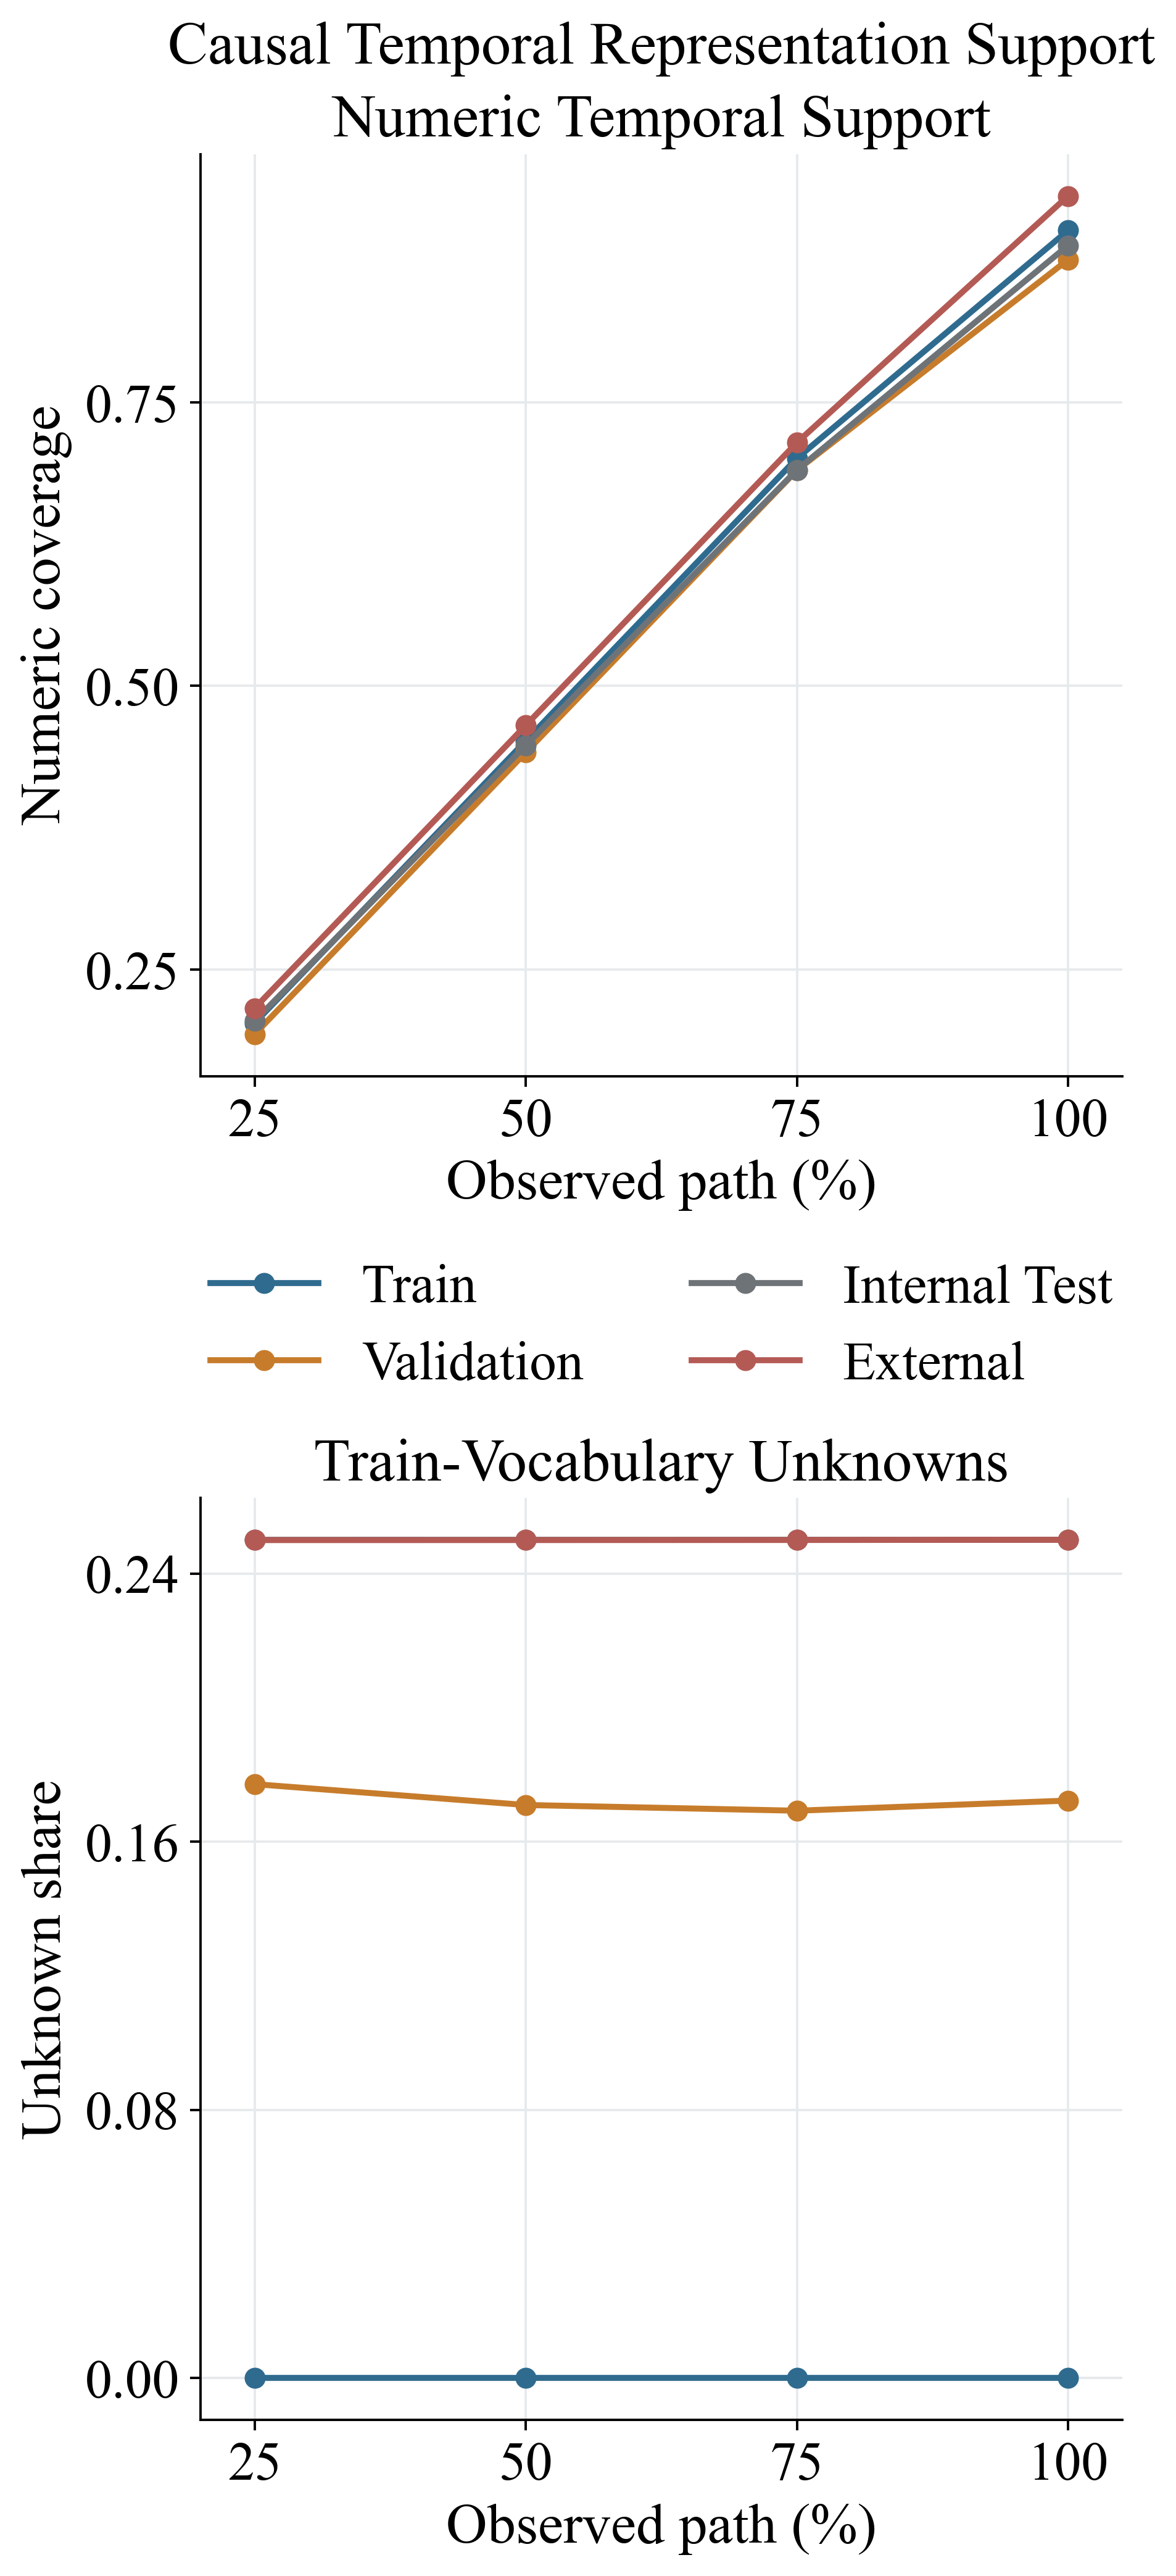

In [32]:
fig, axes = figure_subplots(
    2, 1, span="double", legend_items=4, annotation_rows=4,
    square_axes=True, height_mm=300.0,
)
split_colors = {
    "train": PALETTE["baseline"], "validation": PALETTE["validation"],
    "internal_test": PALETTE["baseline_secondary"],
    "external": PALETTE["external"],
}
for split_name in split_order:
    rows = prefix_tensor_support[prefix_tensor_support["split"].eq(split_name)]
    axes[0].plot(
        100.0 * rows["prefix_fraction"], rows["numeric_observed_share"],
        marker="o", linewidth=2.0, color=split_colors[split_name],
        label=split_name.replace("_", " ").title(),
    )
    axes[1].plot(
        100.0 * rows["prefix_fraction"], rows["categorical_unknown_share"],
        marker="o", linewidth=2.0, color=split_colors[split_name],
    )
for axis in axes:
    axis.set_xticks([25, 50, 75, 100])
    axis.set_xlim(20, 105)
    axis.yaxis.set_major_locator(
        mpl.ticker.MaxNLocator(nbins=4, prune="both")
    )
axes[0].set_xlabel("Observed path (%)")
axes[0].set_ylabel("Numeric coverage")
axes[0].set_title("Numeric Temporal Support")
axes[0].grid(color=PALETTE["grid"])
legend_below(axes[0], ncol=2)
axes[1].set_xlabel("Observed path (%)")
axes[1].set_ylabel("Unknown share")
axes[1].set_title("Train-Vocabulary Unknowns")
axes[1].grid(color=PALETTE["grid"])
fig.suptitle("Causal Temporal Representation Support")
_ = save_show_figure(fig, FIGURES / "02_causal_tensor_support.png", span="double")


Prefix support is shown separately from static-feature missingness. Unknown categorical values are defined only against the training vocabulary, so external unknown rates quantify transport difficulty without expanding the vocabulary from held-out data.

## Train-fitted feature-space attrition

Which cleaning and selection rules reduce the engineered numeric candidates to the representative 12-feature diagnostic shortlist?

In [33]:
cleaning_attrition = pd.DataFrame([
    {"stage": "Numeric engineered pool", "remaining_features": len(numeric_candidates),
     "excluded_at_stage": 0},
    {"stage": "Primary pool after proxy policy", "remaining_features": len(candidate_feature_columns),
     "excluded_at_stage": len(proxy_sensitivity_columns)},
    {"stage": "Descriptive train: remove all-missing", "remaining_features": len(numeric_candidates) - len(all_missing_columns),
     "excluded_at_stage": len(all_missing_columns)},
    {"stage": "Descriptive train: remove constants", "remaining_features": len(numeric_candidates) - len(all_missing_columns) - len(constant_columns),
     "excluded_at_stage": len(constant_columns)},
    {"stage": "Descriptive train: remove exact duplicates", "remaining_features": len(numeric_candidates) - len(all_missing_columns) - len(constant_columns) - len(duplicate_columns),
     "excluded_at_stage": len(duplicate_columns)},
    {"stage": "Descriptive train: deterministic redundancy", "remaining_features": len(clean_feature_columns),
     "excluded_at_stage": len(deterministic_columns)},
    {"stage": "Representative diagnostic shortlist", "remaining_features": len(selected_features),
     "excluded_at_stage": len(clean_feature_columns) - len(selected_features)},
])
display_grouped_tables(
    cleaning_attrition, identifier_columns=["stage"],
    column_groups={"Candidate and descriptive attrition": [
        "remaining_features", "excluded_at_stage",
    ]}, digits=0,
)

#### Candidate and descriptive attrition

,stage,remaining_features,excluded_at_stage
0,Numeric engineered pool,1025,0
1,Primary pool after proxy policy,1015,10
2,Descriptive train: remove all-missing,1023,2
3,Descriptive train: remove constants,849,174
4,Descriptive train: remove exact duplicates,780,69
5,Descriptive train: deterministic redundancy,748,32
6,Representative diagnostic shortlist,12,736


Cleaning and the representative shortlist are fitted only on development-train rows. The 12-feature set is a diagnostic summary, not a license to hold feature selection fixed inside later cross-validation; learned feature selection is repeated within each model-training fold.

## Complete descriptive statistics

What are the central tendency, variability, range, quartiles, and completeness of every selected diagnostic feature in every split?

In [34]:
feature_codes = {feature: f"F{index + 1}" for index, feature in enumerate(selected_features)}
descriptive_rows = []
for split_name in split_order:
    split_data = modeling_dataset[modeling_dataset["split"].eq(split_name)]
    for feature in selected_features:
        values = pd.to_numeric(split_data[feature], errors="coerce").replace(
            [np.inf, -np.inf], np.nan
        )
        descriptive_rows.append(
            {
                "split": split_name,
                "feature_code": feature_codes[feature],
                "feature": feature,
                "n": len(split_data),
                "mean": values.mean(),
                "standard_deviation": values.std(ddof=1),
                "median": values.median(),
                "minimum": values.min(),
                "q25": values.quantile(0.25),
                "q75": values.quantile(0.75),
                "maximum": values.max(),
                "missing_percent": 100.0 * values.isna().mean(),
            }
        )
descriptive_statistics = pd.DataFrame(descriptive_rows)
display_grouped_tables(
    descriptive_statistics,
    identifier_columns=["split", "feature_code", "feature", "n"],
    column_groups={
        "Central tendency and variability": ["mean", "standard_deviation", "median"],
        "Range and quartiles": ["minimum", "q25", "q75", "maximum"],
        "Completeness": ["missing_percent"],
    },
    digits=4,
)


#### Central tendency and variability

,split,feature_code,feature,n,mean,standard_deviation,median
0,train,F1,machine_time__mean,563,1620800.0407,14576.7464,1618999.2710
1,train,F2,z_position__mean,563,−302.4893,19.8600,−297.4461
2,train,F3,Tool__train_frequency,563,0.2427,0.1272,0.2274
3,train,F4,available_duration_s,563,2.7279,1.8416,1.7500
4,train,F5,smarms__energy,563,86349074.7331,152300027.0067,15750000.0000
5,train,F6,part_count__mean,563,714.0196,5.2091,714.0000
6,train,F7,smapeak__energy,563,1321773558.7189,2402423415.2868,237425000.0000
7,train,F8,ymapeak__energy,563,179213398.5765,243978108.7547,68325000.0000
8,train,F9,machine_time__energy,563,46591819584139.3047,30928178355488.1016,31300125453989.7031
9,train,F10,zmapeak__energy,563,820491227.7580,2207315613.7116,48970000.0000


#### Range and quartiles

,split,feature_code,feature,n,minimum,q25,q75,maximum
0,train,F1,machine_time__mean,563,1600628.5270,1612515.1480,1640250.2200,1642771.9670
1,train,F2,z_position__mean,563,−340.6976,−307.6466,−289.8215,−271.0957
2,train,F3,Tool__train_frequency,563,0.0213,0.1137,0.3890,0.3890
3,train,F4,available_duration_s,563,0.8320,1.2800,4.8215,7.2960
4,train,F5,smarms__energy,563,630000.0000,8895000.0000,96917500.0000,1128680000.0000
5,train,F6,part_count__mean,563,706.0000,711.0000,720.0000,722.0000
6,train,F7,smapeak__energy,563,11830000.0000,136507500.0000,1291830000.0000,17669320000.0000
7,train,F8,ymapeak__energy,563,4520000.0000,33245000.0000,211147500.0000,1475180000.0000
8,train,F9,machine_time__energy,563,10761683136840.1934,21589597884488.3906,70205537768295.4688,125983699452448.2031
9,train,F10,zmapeak__energy,563,440000.0000,16270000.0000,291985000.0000,16287070000.0000


#### Completeness

,split,feature_code,feature,n,missing_percent
0,train,F1,machine_time__mean,563,0.1776
1,train,F2,z_position__mean,563,0.1776
2,train,F3,Tool__train_frequency,563,0.0000
3,train,F4,available_duration_s,563,0.0000
4,train,F5,smarms__energy,563,0.1776
5,train,F6,part_count__mean,563,0.1776
6,train,F7,smapeak__energy,563,0.1776
7,train,F8,ymapeak__energy,563,0.1776
8,train,F9,machine_time__energy,563,0.1776
9,train,F10,zmapeak__energy,563,0.1776


Exact values are reported without truncation. Feature codes connect the table to compact visual panels while preserving the full feature names here.

## Train distribution shape by intervention state

Do representative features show skew, heavy tails, multimodality, or class-conditional separation within the development-training boundary?

In [35]:
distribution_features = selected_features[:4]
def feature_scale(feature: str, mask: pd.Series) -> tuple[float, float, int]:
    """Return robust plotting limits and a readable engineering exponent."""
    values = pd.to_numeric(modeling_dataset.loc[mask, feature], errors="coerce")
    values = values.replace([np.inf, -np.inf], np.nan).dropna()
    lower, upper = values.quantile([0.01, 0.99])
    magnitude = max(abs(float(lower)), abs(float(upper)))
    exponent = int(3 * np.floor(np.log10(magnitude) / 3.0)) if magnitude > 0.0 else 0
    exponent = exponent if abs(exponent) >= 3 else 0
    return float(lower), float(upper), exponent
def plot_class_ecdf_axis(axis, feature: str) -> None:
    """Draw one train-only class-conditional ECDF panel."""
    lower, upper, exponent = feature_scale(feature, train_mask)
    scale = float(10.0 ** exponent)
    for target, label, color in [
        (0, "No intervention", PALETTE["baseline"]),
        (1, "Intervention", PALETTE["error"]),
    ]:
        mask = train_mask & modeling_dataset["InterventionRequired"].eq(target)
        values = pd.to_numeric(modeling_dataset.loc[mask, feature], errors="coerce")
        values = values.replace([np.inf, -np.inf], np.nan).dropna()
        visible = np.sort(values[values.between(lower, upper)].to_numpy(float)) / scale
        cumulative = np.arange(1, len(visible) + 1) / max(len(visible), 1)
        axis.plot(visible, cumulative, linewidth=2.1, color=color, label=label)
    axis.margins(x=0.10)
    axis.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, prune="both"))
    axis.set_title(feature_codes[feature])
    axis.set_xlabel(
        f"Feature value / $10^{{{exponent}}}$\n(central 98% train)"
        if exponent else "Feature value\n(central 98% train)"
    )
    axis.ticklabel_format(axis="x", style="plain", useOffset=False)
    axis.tick_params(axis="x", pad=8)
    axis.set_ylabel(r"ECDF, $F(x)$", labelpad=10)
    axis.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=4, prune="both"))
    axis.grid(color=PALETTE["grid"])


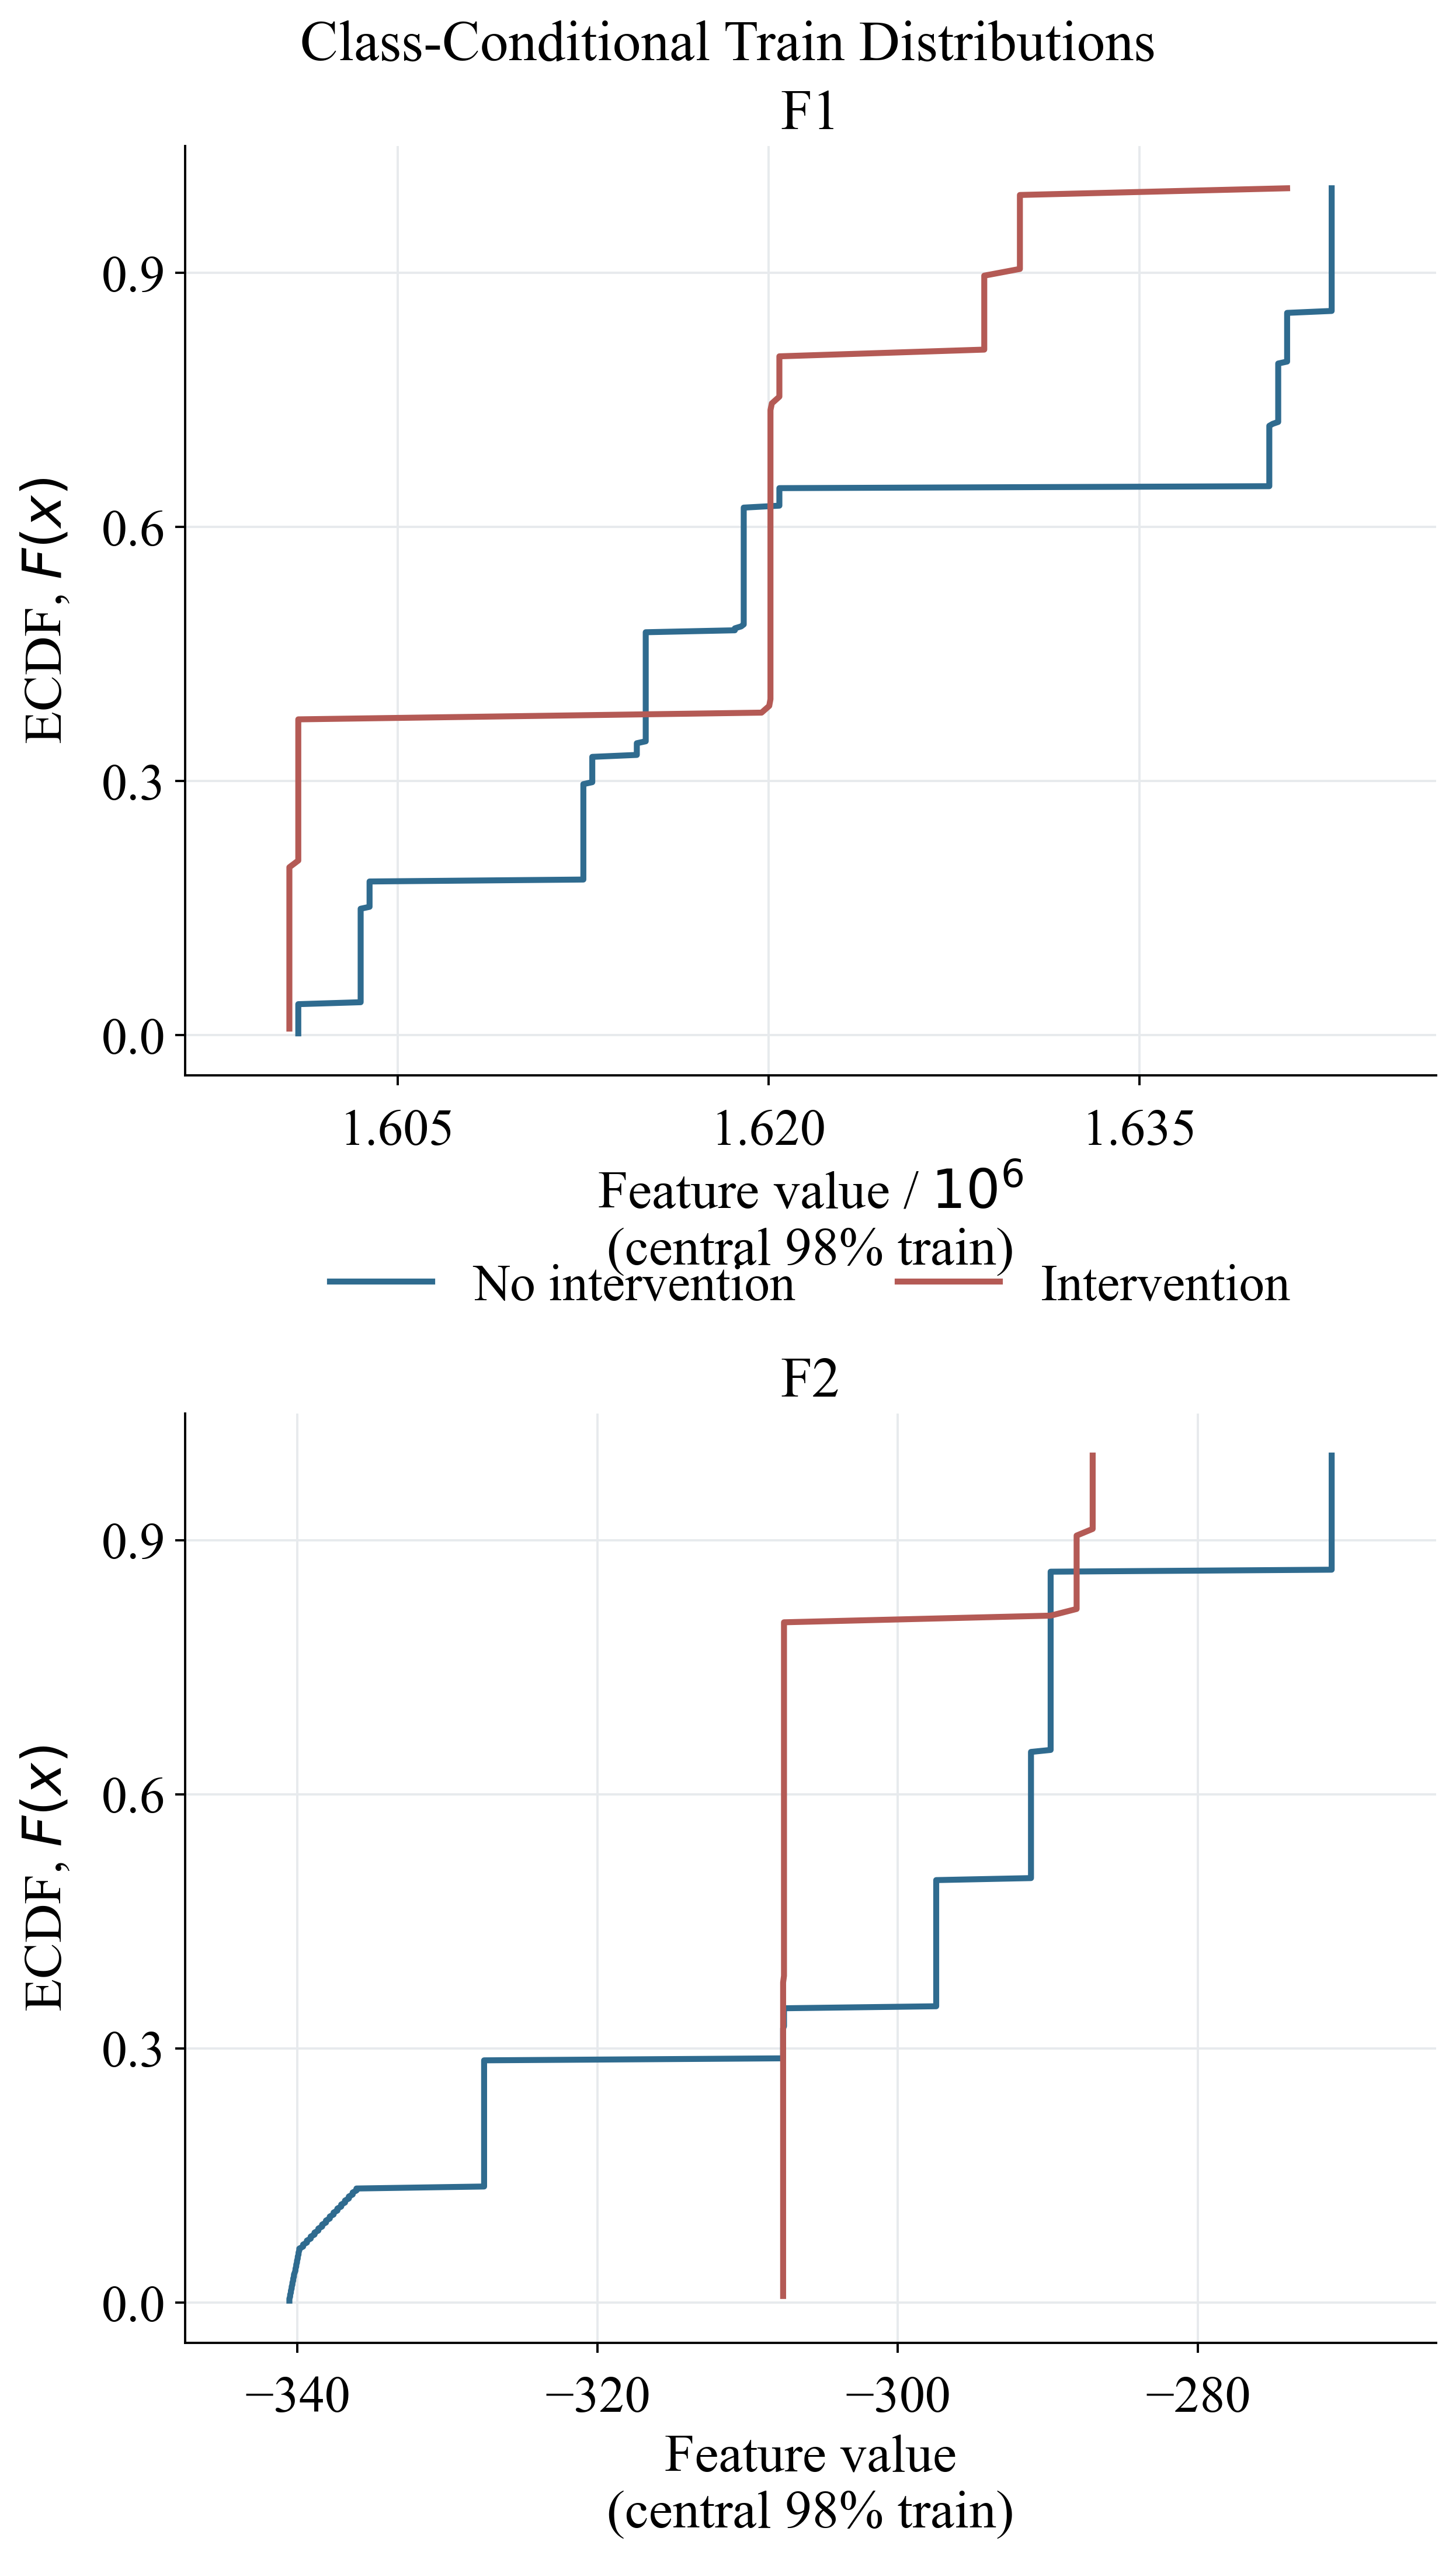

In [36]:
def plot_class_conditional_ecdfs(features, output_name):
    """Plot two vertically aligned train-only class-conditional ECDFs."""
    fig, axes = figure_subplots(
        2, 1, span="double", legend_items=2, annotation_rows=2,
        square_axes=False, height_mm=315.0,
    )
    for axis, feature in zip(axes, features, strict=True):
        plot_class_ecdf_axis(axis, feature)
    legend_below(axes[0], ncol=2)
    fig.suptitle("Class-Conditional Train Distributions")
    return save_show_figure(fig, FIGURES / output_name, span="double")
_ = plot_class_conditional_ecdfs(
    distribution_features[:2], "02_train_feature_distributions.png"
)


### Additional class-conditional feature distributions

Do the third and fourth diagnostic features reproduce or contradict the separation patterns observed above?

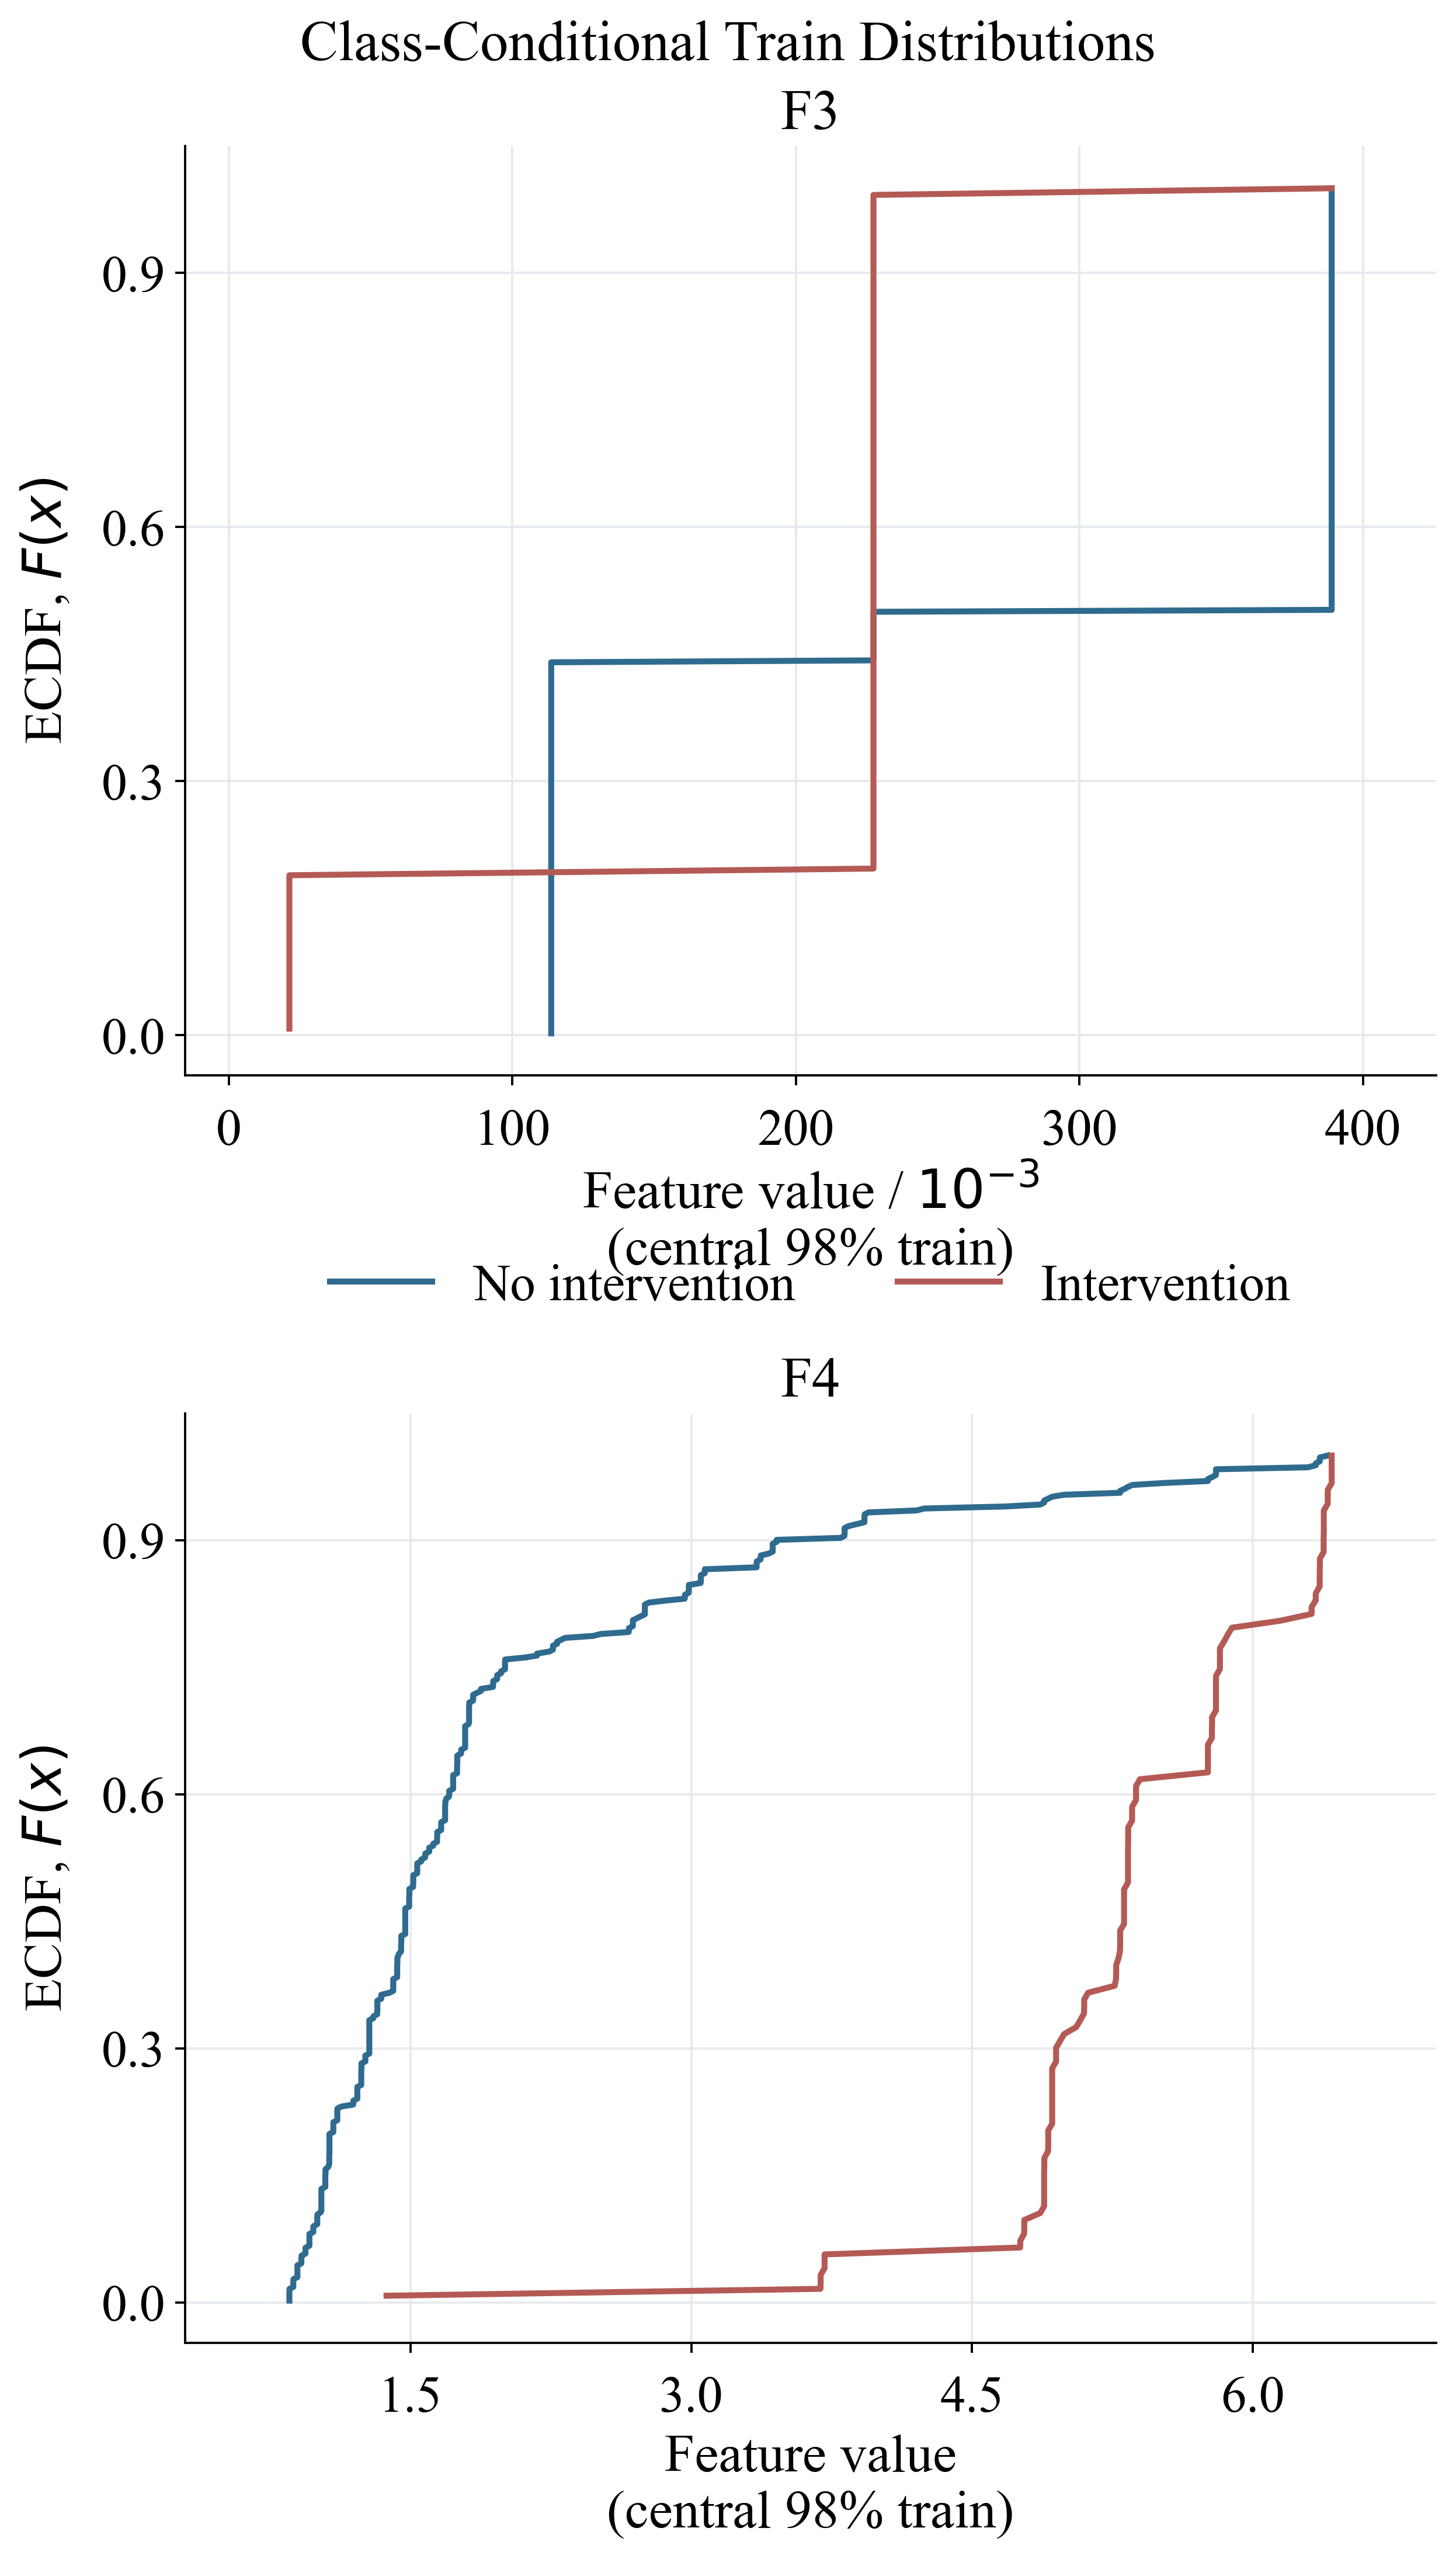

In [37]:
_ = plot_class_conditional_ecdfs(
    distribution_features[2:4],
    "02_train_feature_distributions_additional.png",
)


ECDFs avoid unstable density normalization for nearly constant features and expose tails and stochastic ordering directly. The central train range is used only for visual readability; the retained fractions are declared and no observations are deleted from modeling.

## Linear and nonlinear dependency triangulation

Do Pearson correlation, mutual information, and cross-fitted XGBoost interactions identify the same or complementary structure among the 12 development-only diagnostic features?


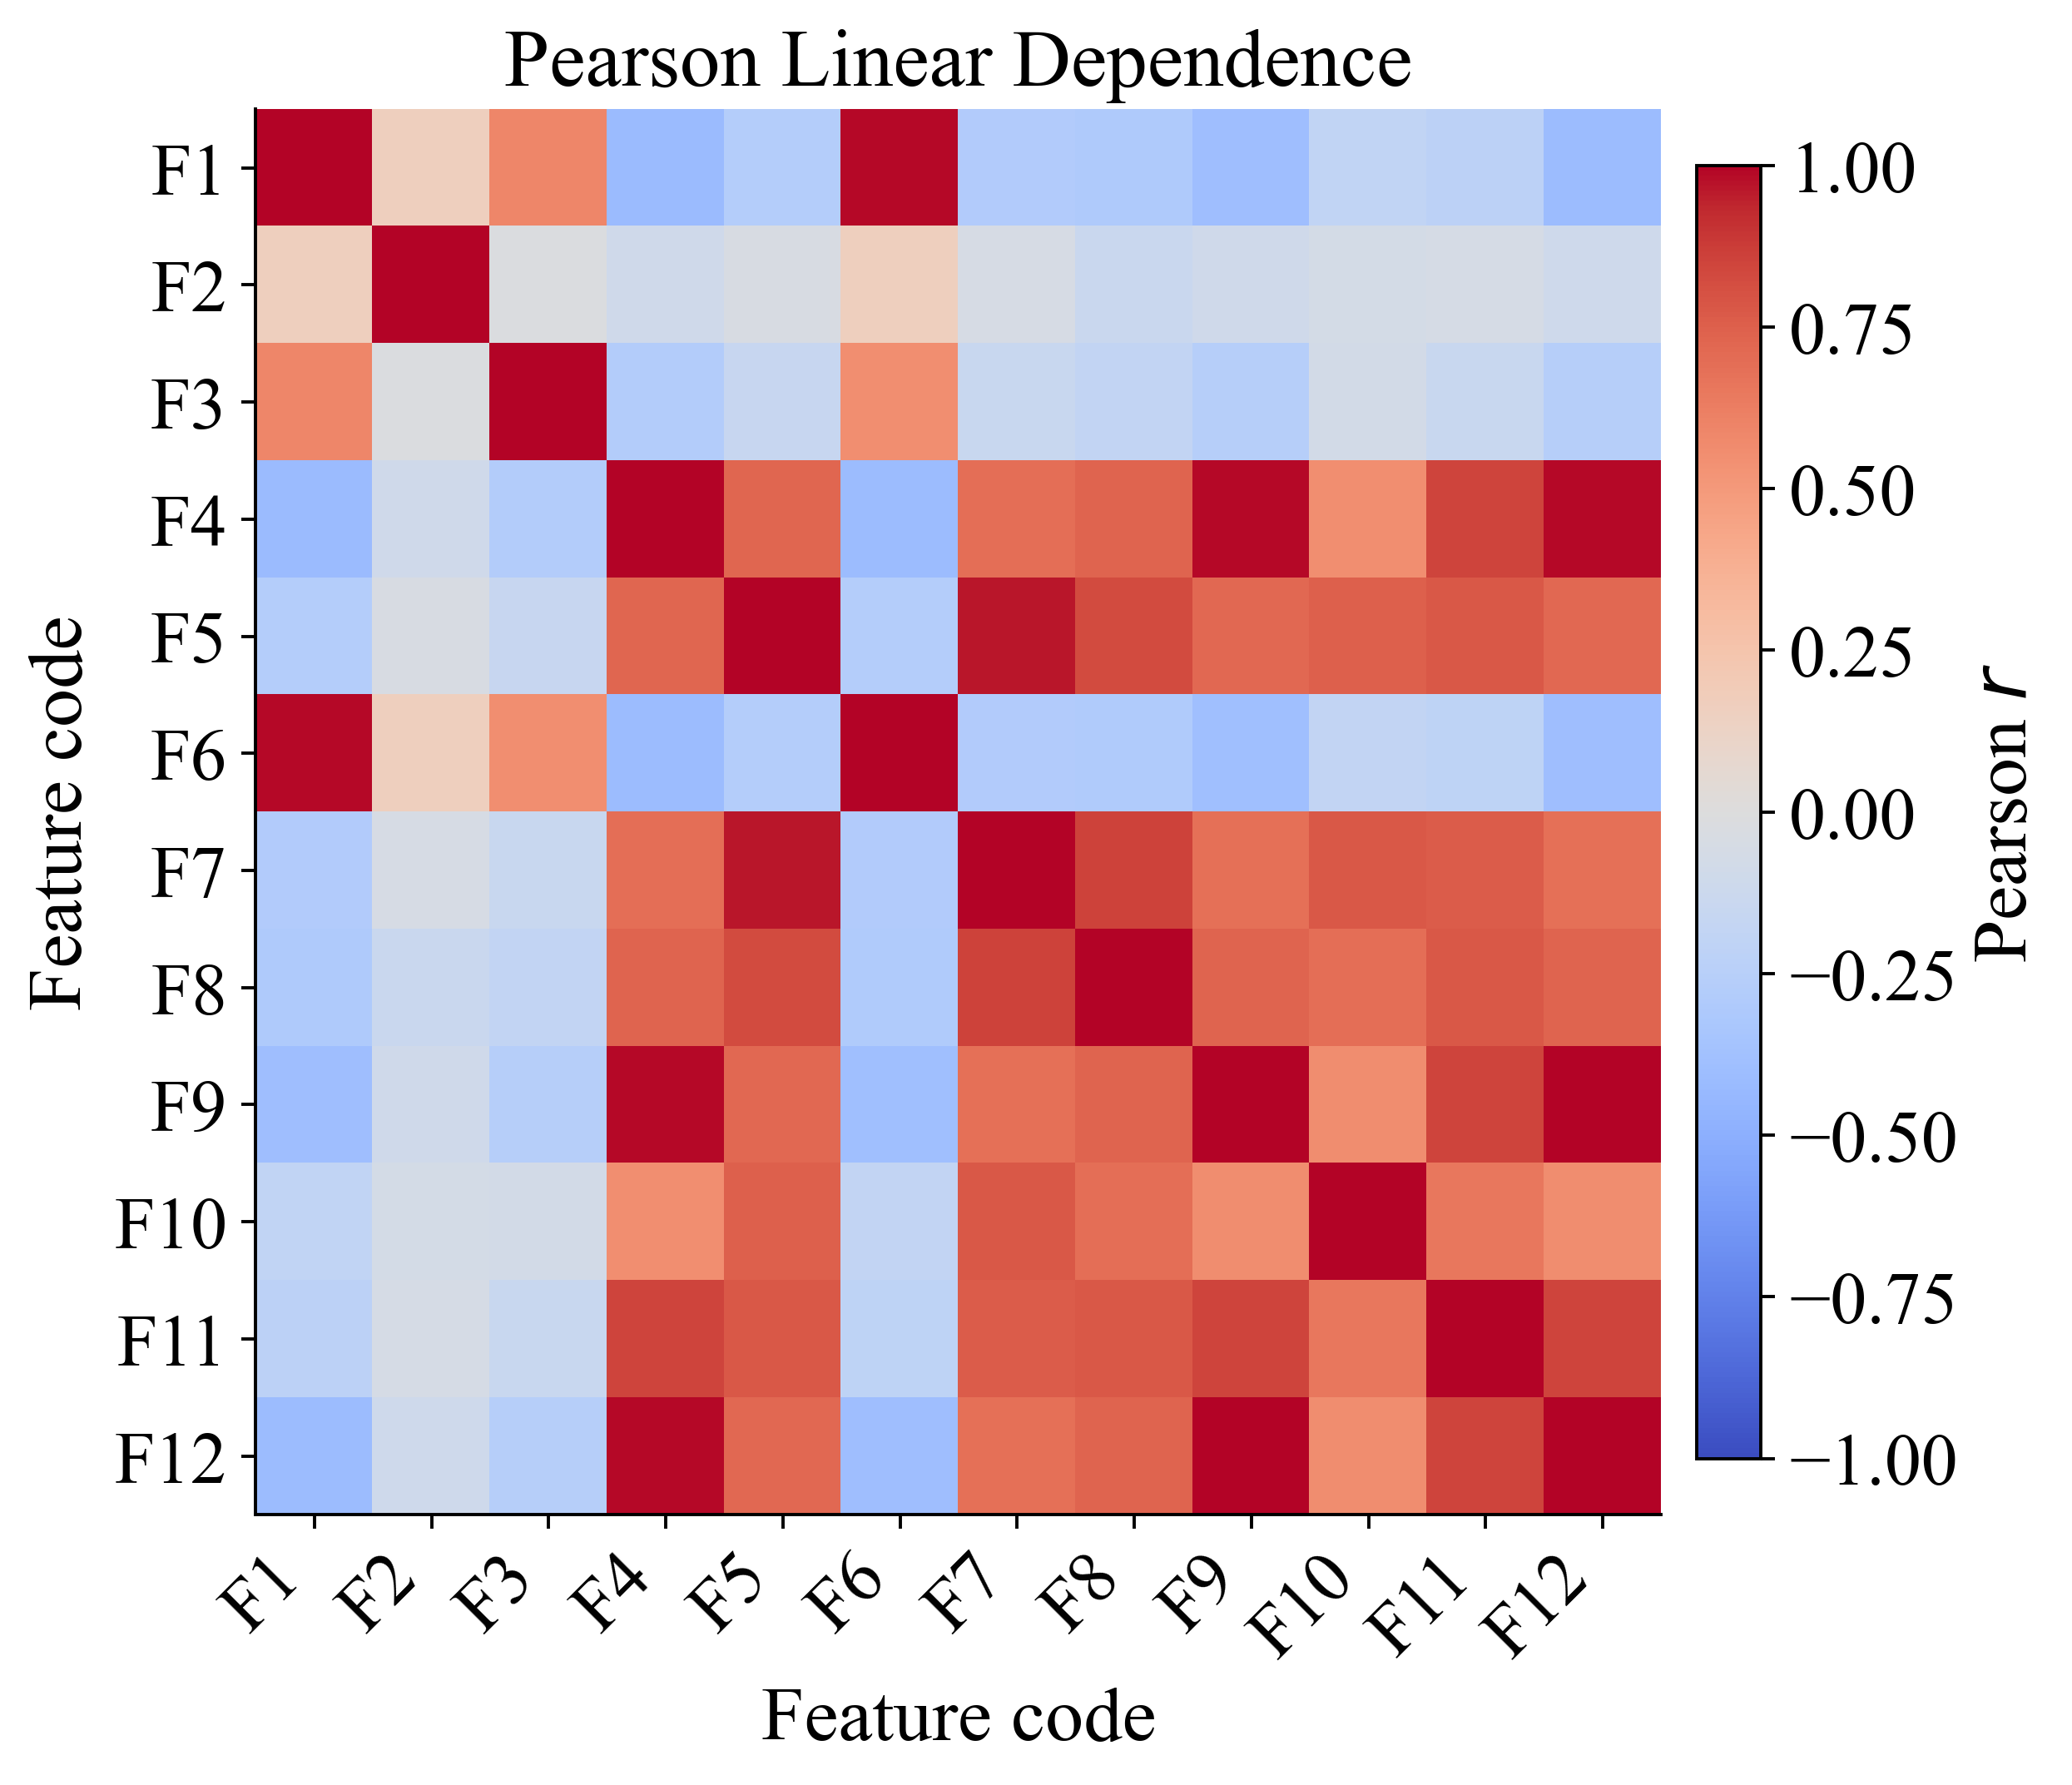

In [38]:
diagnostic_train = modeling_dataset.loc[train_mask, selected_features].copy()
diagnostic_train_imputed = diagnostic_train.fillna(diagnostic_train.median())
relationship_codes = [feature_codes[feature] for feature in selected_features]
pearson_matrix = diagnostic_train_imputed.corr(method="pearson").to_numpy(float)
plot_scientific_matrix(
    pearson_matrix, relationship_codes, "Pearson Linear Dependence",
    r"Pearson $r$", "02_pearson_dependence_matrix.png",
    vmin=-1.0, vmax=1.0, cmap="coolwarm",
)

Pearson coefficients isolate linear redundancy. The complete annotated matrix is descriptive and does not determine the modeling feature set.


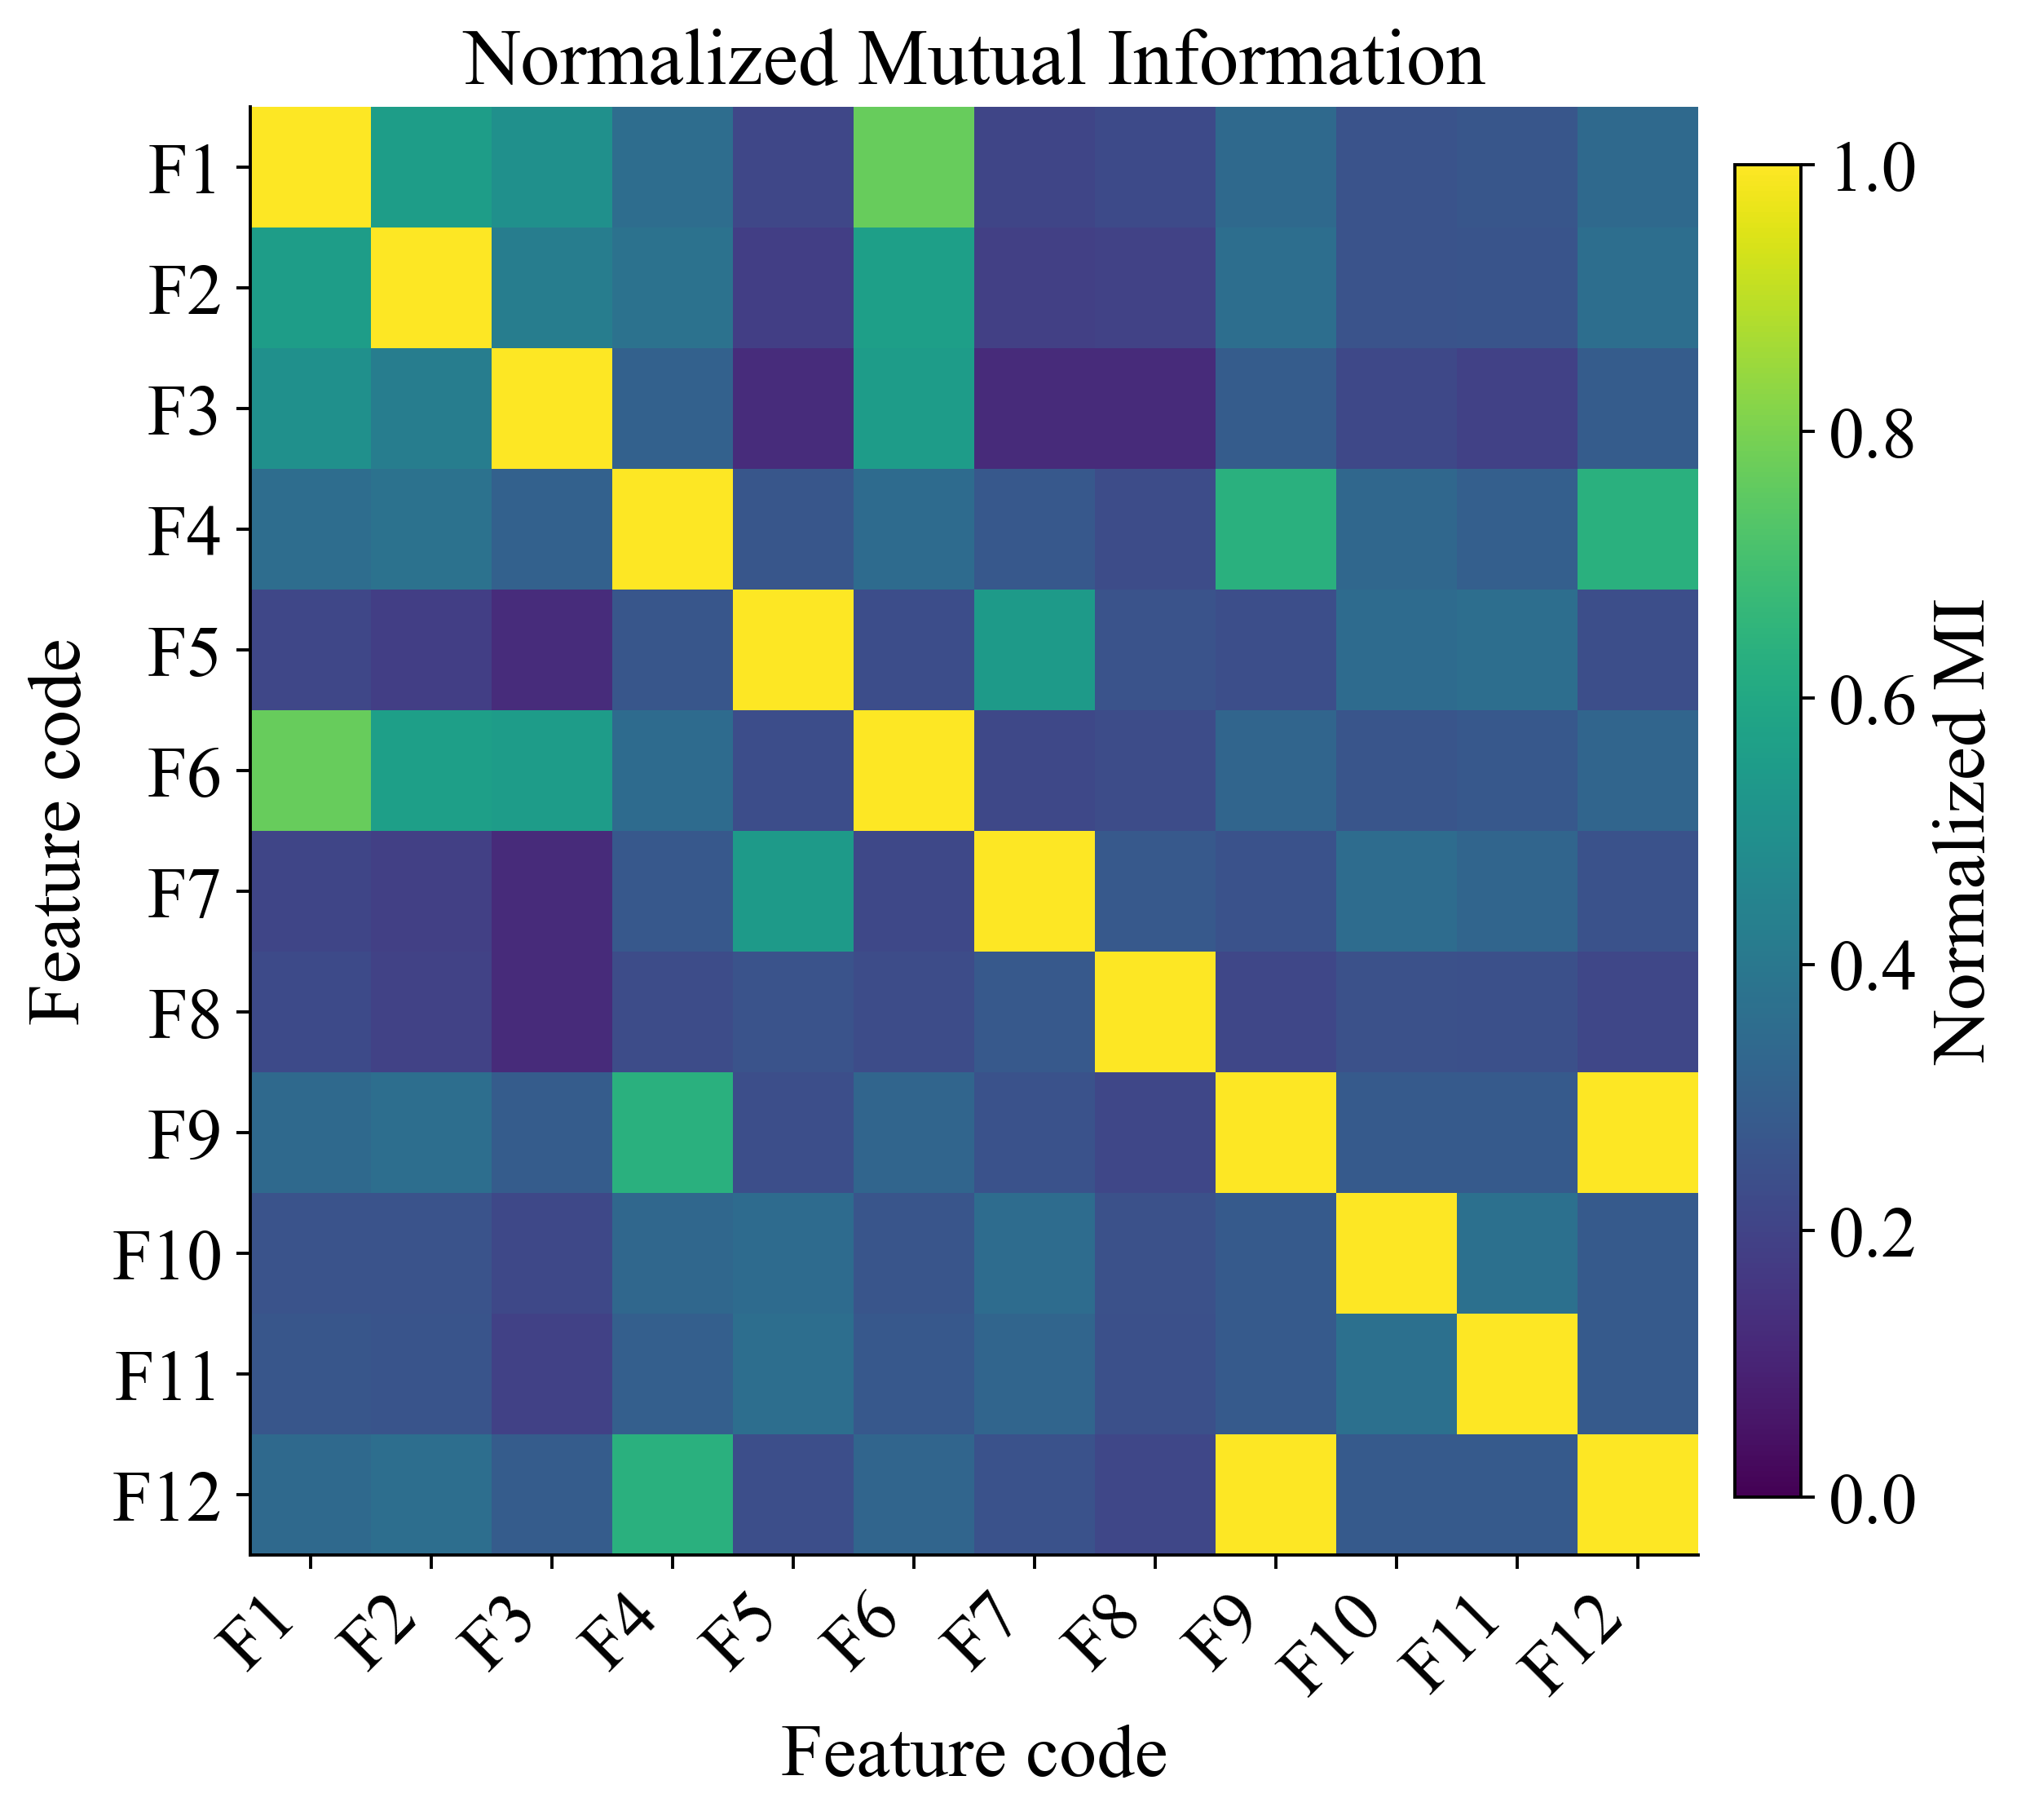

In [39]:
def quantile_codes(values: pd.Series, bins: int = 8) -> np.ndarray:
    """Return deterministic rank-quantile codes for nonlinear MI diagnostics."""
    unique_count = int(values.nunique(dropna=True))
    if unique_count <= 1:
        return np.zeros(len(values), dtype=int)
    quantile_count = min(bins, unique_count)
    return pd.qcut(
        values.rank(method="first"), q=quantile_count,
        labels=False, duplicates="drop",
    ).to_numpy(int)

quantile_matrix = np.column_stack([
    quantile_codes(diagnostic_train_imputed[feature])
    for feature in selected_features
])
mutual_information_matrix = np.eye(len(selected_features), dtype=float)
for left_index in range(len(selected_features)):
    for right_index in range(left_index):
        value = normalized_mutual_info_score(
            quantile_matrix[:, left_index], quantile_matrix[:, right_index]
        )
        mutual_information_matrix[left_index, right_index] = value
        mutual_information_matrix[right_index, left_index] = value
plot_scientific_matrix(
    mutual_information_matrix, relationship_codes,
    "Normalized Mutual Information", "Normalized MI",
    "02_mutual_information_matrix.png",
    vmin=0.0, vmax=1.0, cmap="viridis",
)


Normalized mutual information captures nonlinear dependence after deterministic rank-quantile discretization. Values are symmetric and bounded in [0, 1].


In [40]:
def cross_fitted_univariate_r2(
    predictor: np.ndarray, response: np.ndarray,
    groups: np.ndarray, strata: np.ndarray,
) -> float:
    """Estimate one directed nonlinear association on held-out experiments."""
    oof_prediction = np.full(len(response), np.nan, dtype=float)
    splitter = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
    for fold_index, (fit_index, validation_index) in enumerate(
        splitter.split(predictor, strata, groups)
    ):
        fit_values = predictor[fit_index].reshape(-1, 1)
        validation_values = predictor[validation_index].reshape(-1, 1)
        median = float(np.nanmedian(fit_values))
        fit_values = np.nan_to_num(fit_values, nan=median)
        validation_values = np.nan_to_num(validation_values, nan=median)
        model = XGBRegressor(
            n_estimators=100, max_depth=2, learning_rate=0.05,
            subsample=0.85, colsample_bytree=1.0, min_child_weight=3,
            reg_alpha=0.10, reg_lambda=2.0, objective="reg:squarederror",
            n_jobs=N_JOBS, random_state=SEED + fold_index,
        )
        model.fit(fit_values, response[fit_index])
        oof_prediction[validation_index] = model.predict(validation_values)
    assert np.isfinite(oof_prediction).all()
    return float(r2_score(response, oof_prediction))

In [41]:
diagnostic_groups = modeling_dataset.loc[train_mask, "experiment_group_id"].to_numpy()
diagnostic_target = modeling_dataset.loc[train_mask, "InterventionRequired"].to_numpy(int)
cv_splitter = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
xgb_oof_probability = np.full(len(diagnostic_target), np.nan, dtype=float)
xgb_oof_shap = np.zeros((len(diagnostic_target), len(selected_features)), dtype=float)
xgb_cv_cache = []
for fold_index, (fit_index, validation_index) in enumerate(cv_splitter.split(
    diagnostic_train, diagnostic_target, diagnostic_groups
)):
    fold_medians = diagnostic_train.iloc[fit_index].median()
    fit_values = diagnostic_train.iloc[fit_index].fillna(fold_medians)
    validation_values = diagnostic_train.iloc[validation_index].fillna(fold_medians)
    model = XGBClassifier(
        n_estimators=220, max_depth=3, learning_rate=0.035,
        subsample=0.85, colsample_bytree=0.80, min_child_weight=3,
        reg_alpha=0.10, reg_lambda=2.0, objective="binary:logistic",
        eval_metric="logloss", n_jobs=N_JOBS, random_state=SEED + fold_index,
    )
    model.fit(fit_values, diagnostic_target[fit_index])
    xgb_oof_probability[validation_index] = model.predict_proba(validation_values)[:, 1]
    validation_matrix = DMatrix(validation_values, feature_names=selected_features)
    contributions = model.get_booster().predict(validation_matrix, pred_contribs=True)
    xgb_oof_shap[validation_index] = contributions[:, :-1]
    xgb_cv_cache.append((model, fold_medians, validation_index))
assert np.isfinite(xgb_oof_probability).all()


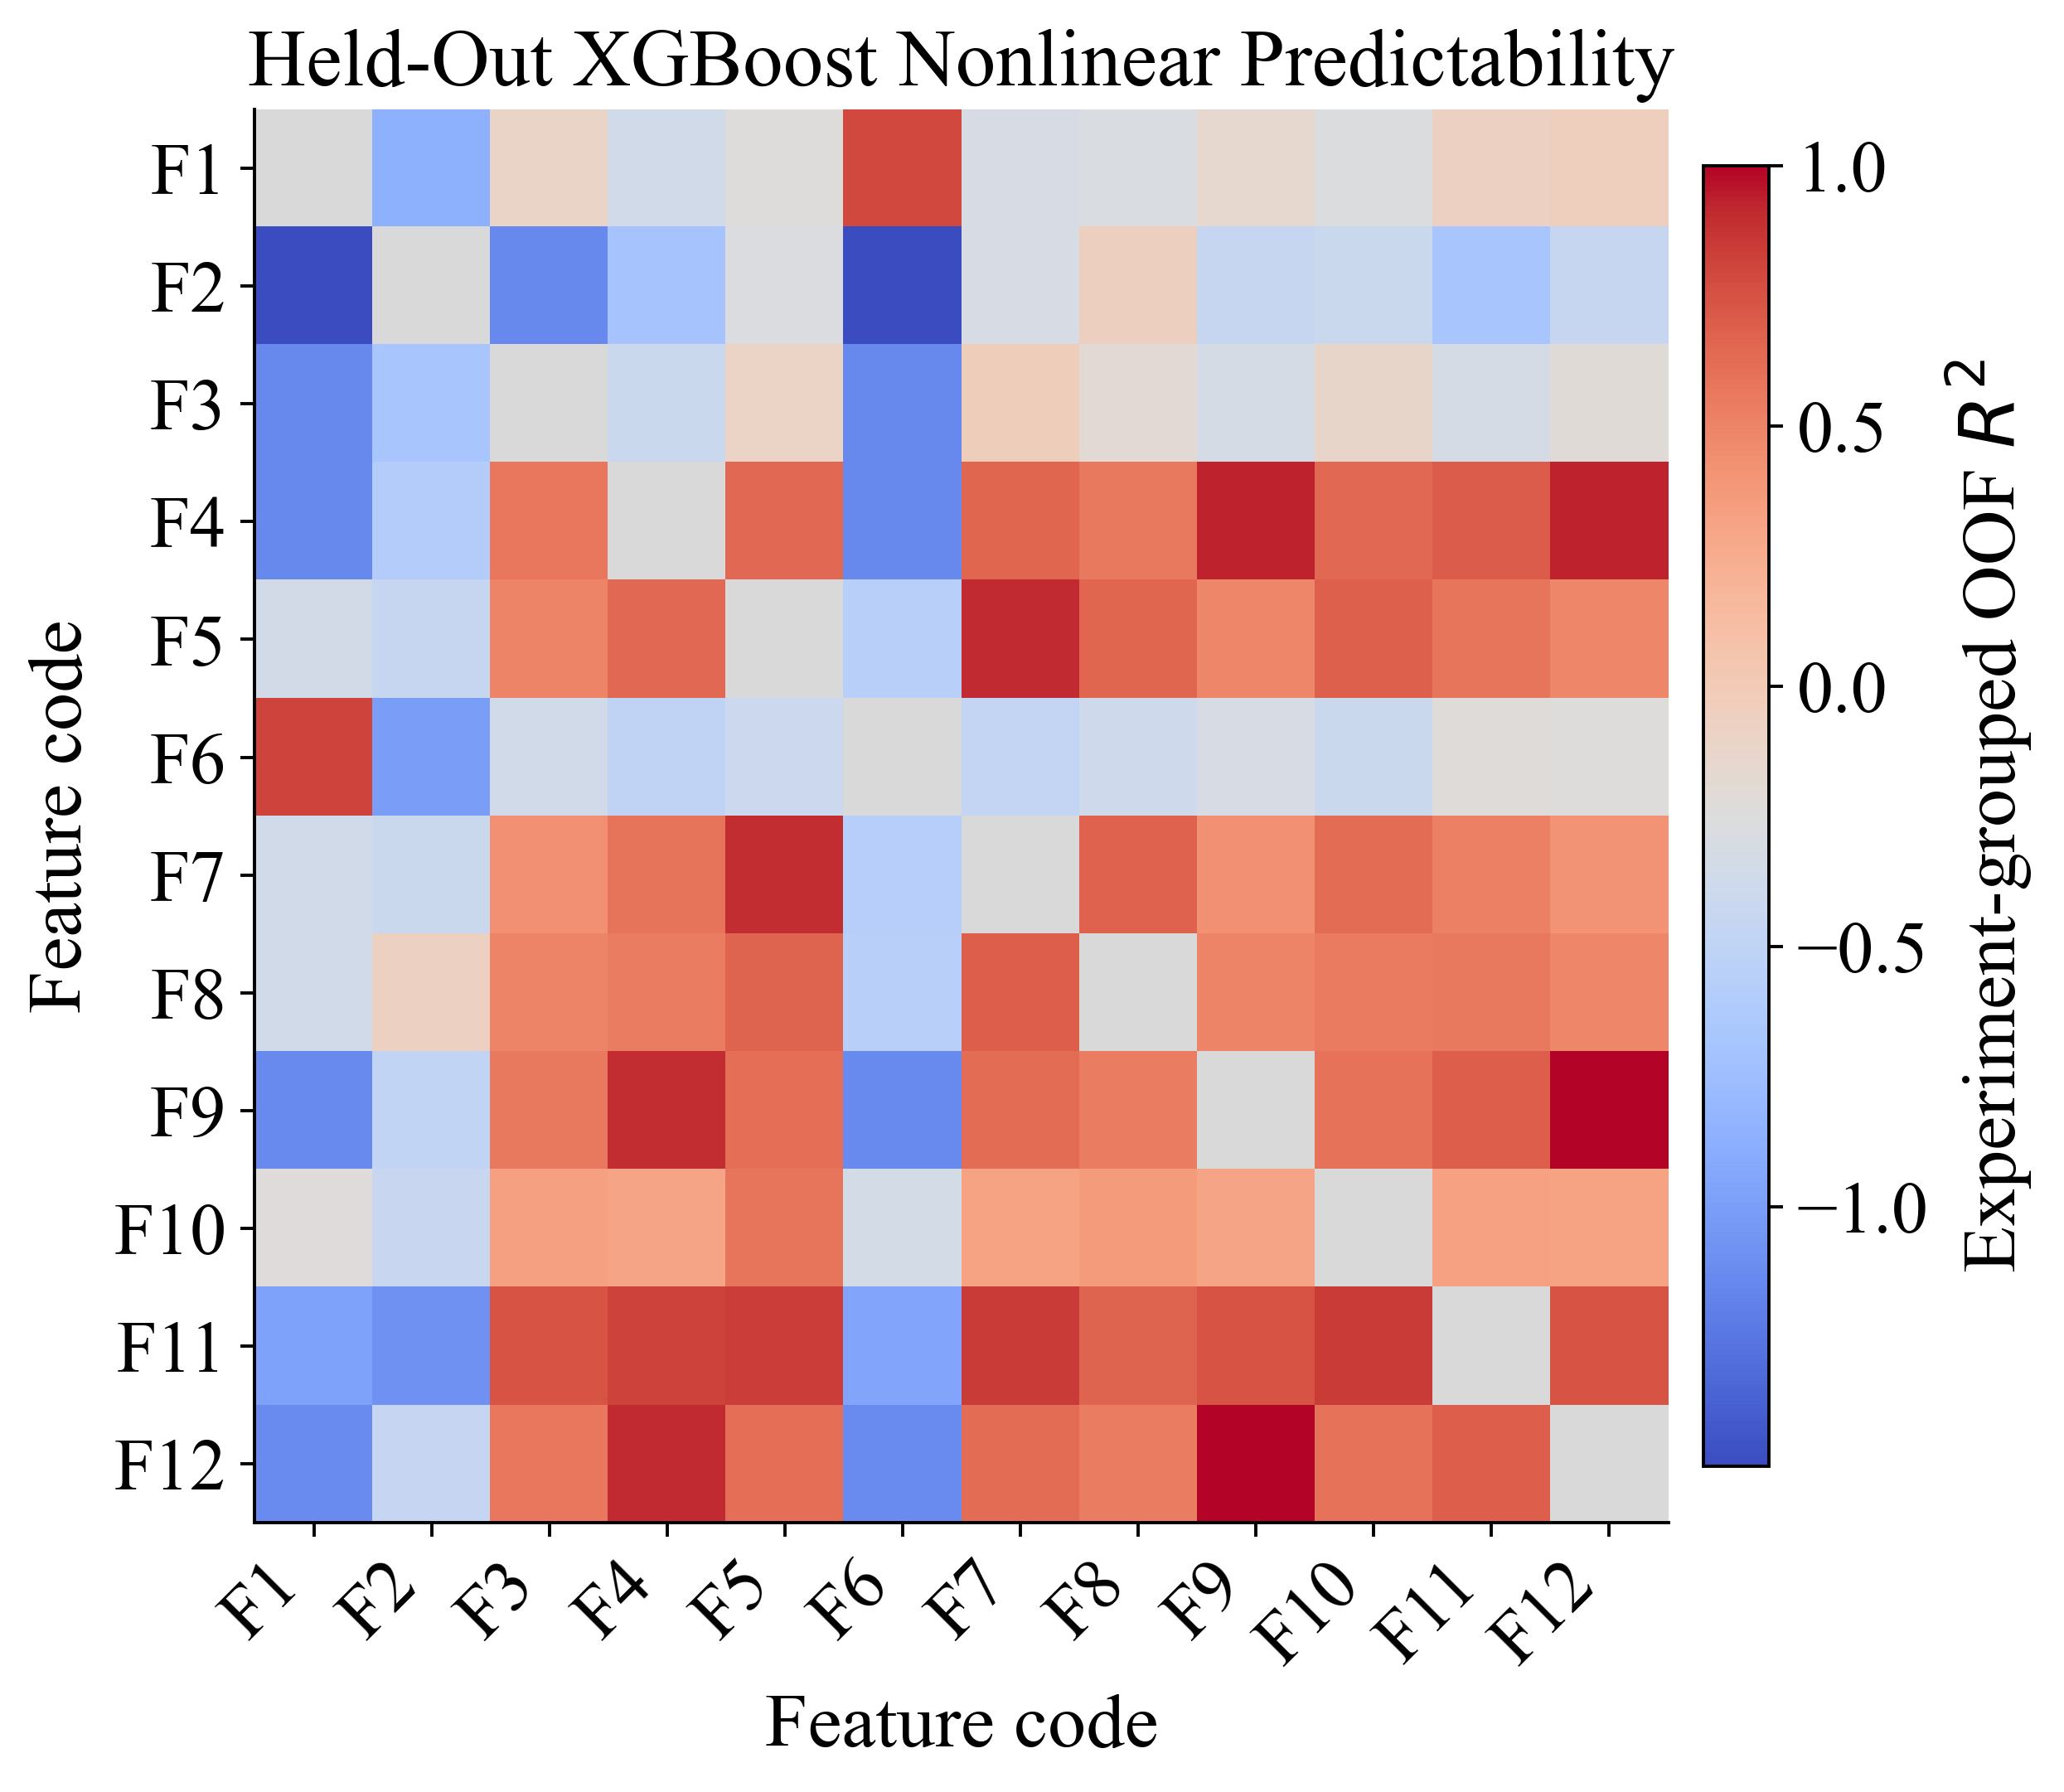

In [42]:
xgb_nonlinear_matrix = np.full(
    (len(selected_features), len(selected_features)), np.nan, dtype=float
)
diagnostic_values = diagnostic_train.to_numpy(float)
for response_index in range(len(selected_features)):
    response = diagnostic_train_imputed.iloc[:, response_index].to_numpy(float)
    for predictor_index in range(len(selected_features)):
        if response_index == predictor_index:
            continue
        xgb_nonlinear_matrix[response_index, predictor_index] = (
            cross_fitted_univariate_r2(
                diagnostic_values[:, predictor_index], response,
                diagnostic_groups, diagnostic_target,
            )
        )
minimum_r2 = min(-1.0, float(np.nanmin(xgb_nonlinear_matrix)))
plot_scientific_matrix(
    xgb_nonlinear_matrix, relationship_codes,
    "Held-Out XGBoost Nonlinear Predictability",
    r"Experiment-grouped OOF $R^2$",
    "02_xgboost_nonlinear_dependency_matrix.png",
    vmin=minimum_r2, vmax=1.0, cmap="coolwarm",
)

Each off-diagonal cell is a directed held-out experiment-grouped $R^2$: the row feature is predicted from the column feature. Training scores are never used, negative values are retained, and the diagonal is rendered as NA.

## Cross-fitted grouped importance and target association

Which feature families remain useful after grouped permutation, and how do marginal associations differ from cross-fitted predictive contributions?


In [43]:
diagnostic_families = {
    feature: feature.split("__", 1)[0] if "__" in feature else "process_metadata"
    for feature in selected_features
}
family_to_features = defaultdict(list)
for feature, family in diagnostic_families.items():
    family_to_features[family].append(feature)
permutation_rows = []
for family_index, (family, features) in enumerate(sorted(family_to_features.items())):
    weighted_delta = 0.0
    for fold_index, (model, medians, validation_index) in enumerate(xgb_cv_cache):
        validation_values = diagnostic_train.iloc[validation_index].fillna(medians)
        baseline = log_loss(
            diagnostic_target[validation_index],
            model.predict_proba(validation_values)[:, 1], labels=[0, 1],
        )
        permuted = validation_values.copy()
        rng = np.random.default_rng(SEED + 100 * family_index + fold_index)
        order = rng.permutation(len(permuted))
        permuted.loc[:, features] = permuted.loc[:, features].to_numpy()[order]
        shifted = log_loss(
            diagnostic_target[validation_index],
            model.predict_proba(permuted)[:, 1], labels=[0, 1],
        )
        weighted_delta += (shifted - baseline) * len(validation_index)
    permutation_rows.append({
        "feature_group": family, "features_in_group": len(features),
        "oof_delta_log_loss": weighted_delta / len(diagnostic_target),
    })
grouped_permutation_importance = pd.DataFrame(permutation_rows).sort_values(
    "oof_delta_log_loss", ascending=False
)


In [44]:
display_grouped_tables(
    grouped_permutation_importance,
    identifier_columns=["feature_group"],
    column_groups={"Cross-fitted grouped permutation": [
        "features_in_group", "oof_delta_log_loss",
    ]},
    digits=4,
)


#### Cross-fitted grouped permutation

,feature_group,features_in_group,oof_delta_log_loss
0,ymapeak,1,0.0833
1,zmapeak,1,0.0526
2,process_metadata,1,0.0352
3,z_position,1,0.0034
4,smarms,1,0.0025
5,smvrms,1,0.0023
6,Tool,1,0.0001
7,part_count,1,−0.0001
8,spindle_time,1,−0.0019
9,smapeak,1,−0.0038


A positive OOF log-loss increase indicates that permuting the entire feature family harms predictions. Negative values are retained rather than hidden.


In [45]:
permutation_by_group = grouped_permutation_importance.set_index("feature_group")
mean_absolute_shap = np.mean(np.abs(xgb_oof_shap), axis=0)
shap_scale = max(float(mean_absolute_shap.max()), np.finfo(float).eps)
association_rows = []
for feature_index, feature in enumerate(selected_features):
    values = diagnostic_train_imputed[feature]
    family = diagnostic_families[feature]
    pearson_value = stats.pointbiserialr(diagnostic_target, values).statistic
    normalized_mi = normalized_mutual_info_score(
        quantile_codes(values), diagnostic_target
    )
    association_rows.append({
        "feature_code": feature_codes[feature], "feature": feature,
        "n_train": len(values), "absolute_pearson": abs(float(pearson_value)),
        "normalized_mutual_information": float(normalized_mi),
        "xgboost_oof_shap_association": mean_absolute_shap[feature_index] / shap_scale,
        "grouped_permutation_delta_log_loss": permutation_by_group.loc[
            family, "oof_delta_log_loss"
        ],
    })
target_association_comparison = pd.DataFrame(association_rows)
display_grouped_tables(
    target_association_comparison,
    identifier_columns=["feature_code", "feature", "n_train"],
    column_groups={
        "Target relationship comparison": [
            "absolute_pearson", "normalized_mutual_information",
            "xgboost_oof_shap_association",
        ],
        "Cross-fitted grouped reliance": ["grouped_permutation_delta_log_loss"],
    }, digits=4,
)

#### Target relationship comparison

,feature_code,feature,n_train,absolute_pearson,normalized_mutual_information,xgboost_oof_shap_association
0,F1,machine_time__mean,563,0.2246,0.2139,0.2106
1,F2,z_position__mean,563,0.0328,0.1752,0.2115
2,F3,Tool__train_frequency,563,0.2251,0.0856,0.0144
3,F4,available_duration_s,563,0.7917,0.2696,0.8297
4,F5,smarms__energy,563,0.7634,0.2909,0.1982
5,F6,part_count__mean,563,0.2072,0.2139,0.0081
6,F7,smapeak__energy,563,0.7542,0.2898,0.3580
7,F8,ymapeak__energy,563,0.7813,0.2849,1.0000
8,F9,machine_time__energy,563,0.7792,0.2533,0.3132
9,F10,zmapeak__energy,563,0.5816,0.2723,0.9615


#### Cross-fitted grouped reliance

,feature_code,feature,n_train,grouped_permutation_delta_log_loss
0,F1,machine_time__mean,563,−0.0100
1,F2,z_position__mean,563,0.0034
2,F3,Tool__train_frequency,563,0.0001
3,F4,available_duration_s,563,0.0352
4,F5,smarms__energy,563,0.0025
5,F6,part_count__mean,563,−0.0001
6,F7,smapeak__energy,563,−0.0038
7,F8,ymapeak__energy,563,0.0833
8,F9,machine_time__energy,563,−0.0100
9,F10,zmapeak__energy,563,0.0526


The comparison separates marginal correlation and mutual information from cross-fitted TreeSHAP and grouped permutation evidence. Agreement is evidence of stability; disagreement indicates conditional or redundant effects.


## Cross-fitted SHAP distribution

How do the signed held-out TreeSHAP contributions vary across paths and within-feature percentiles?


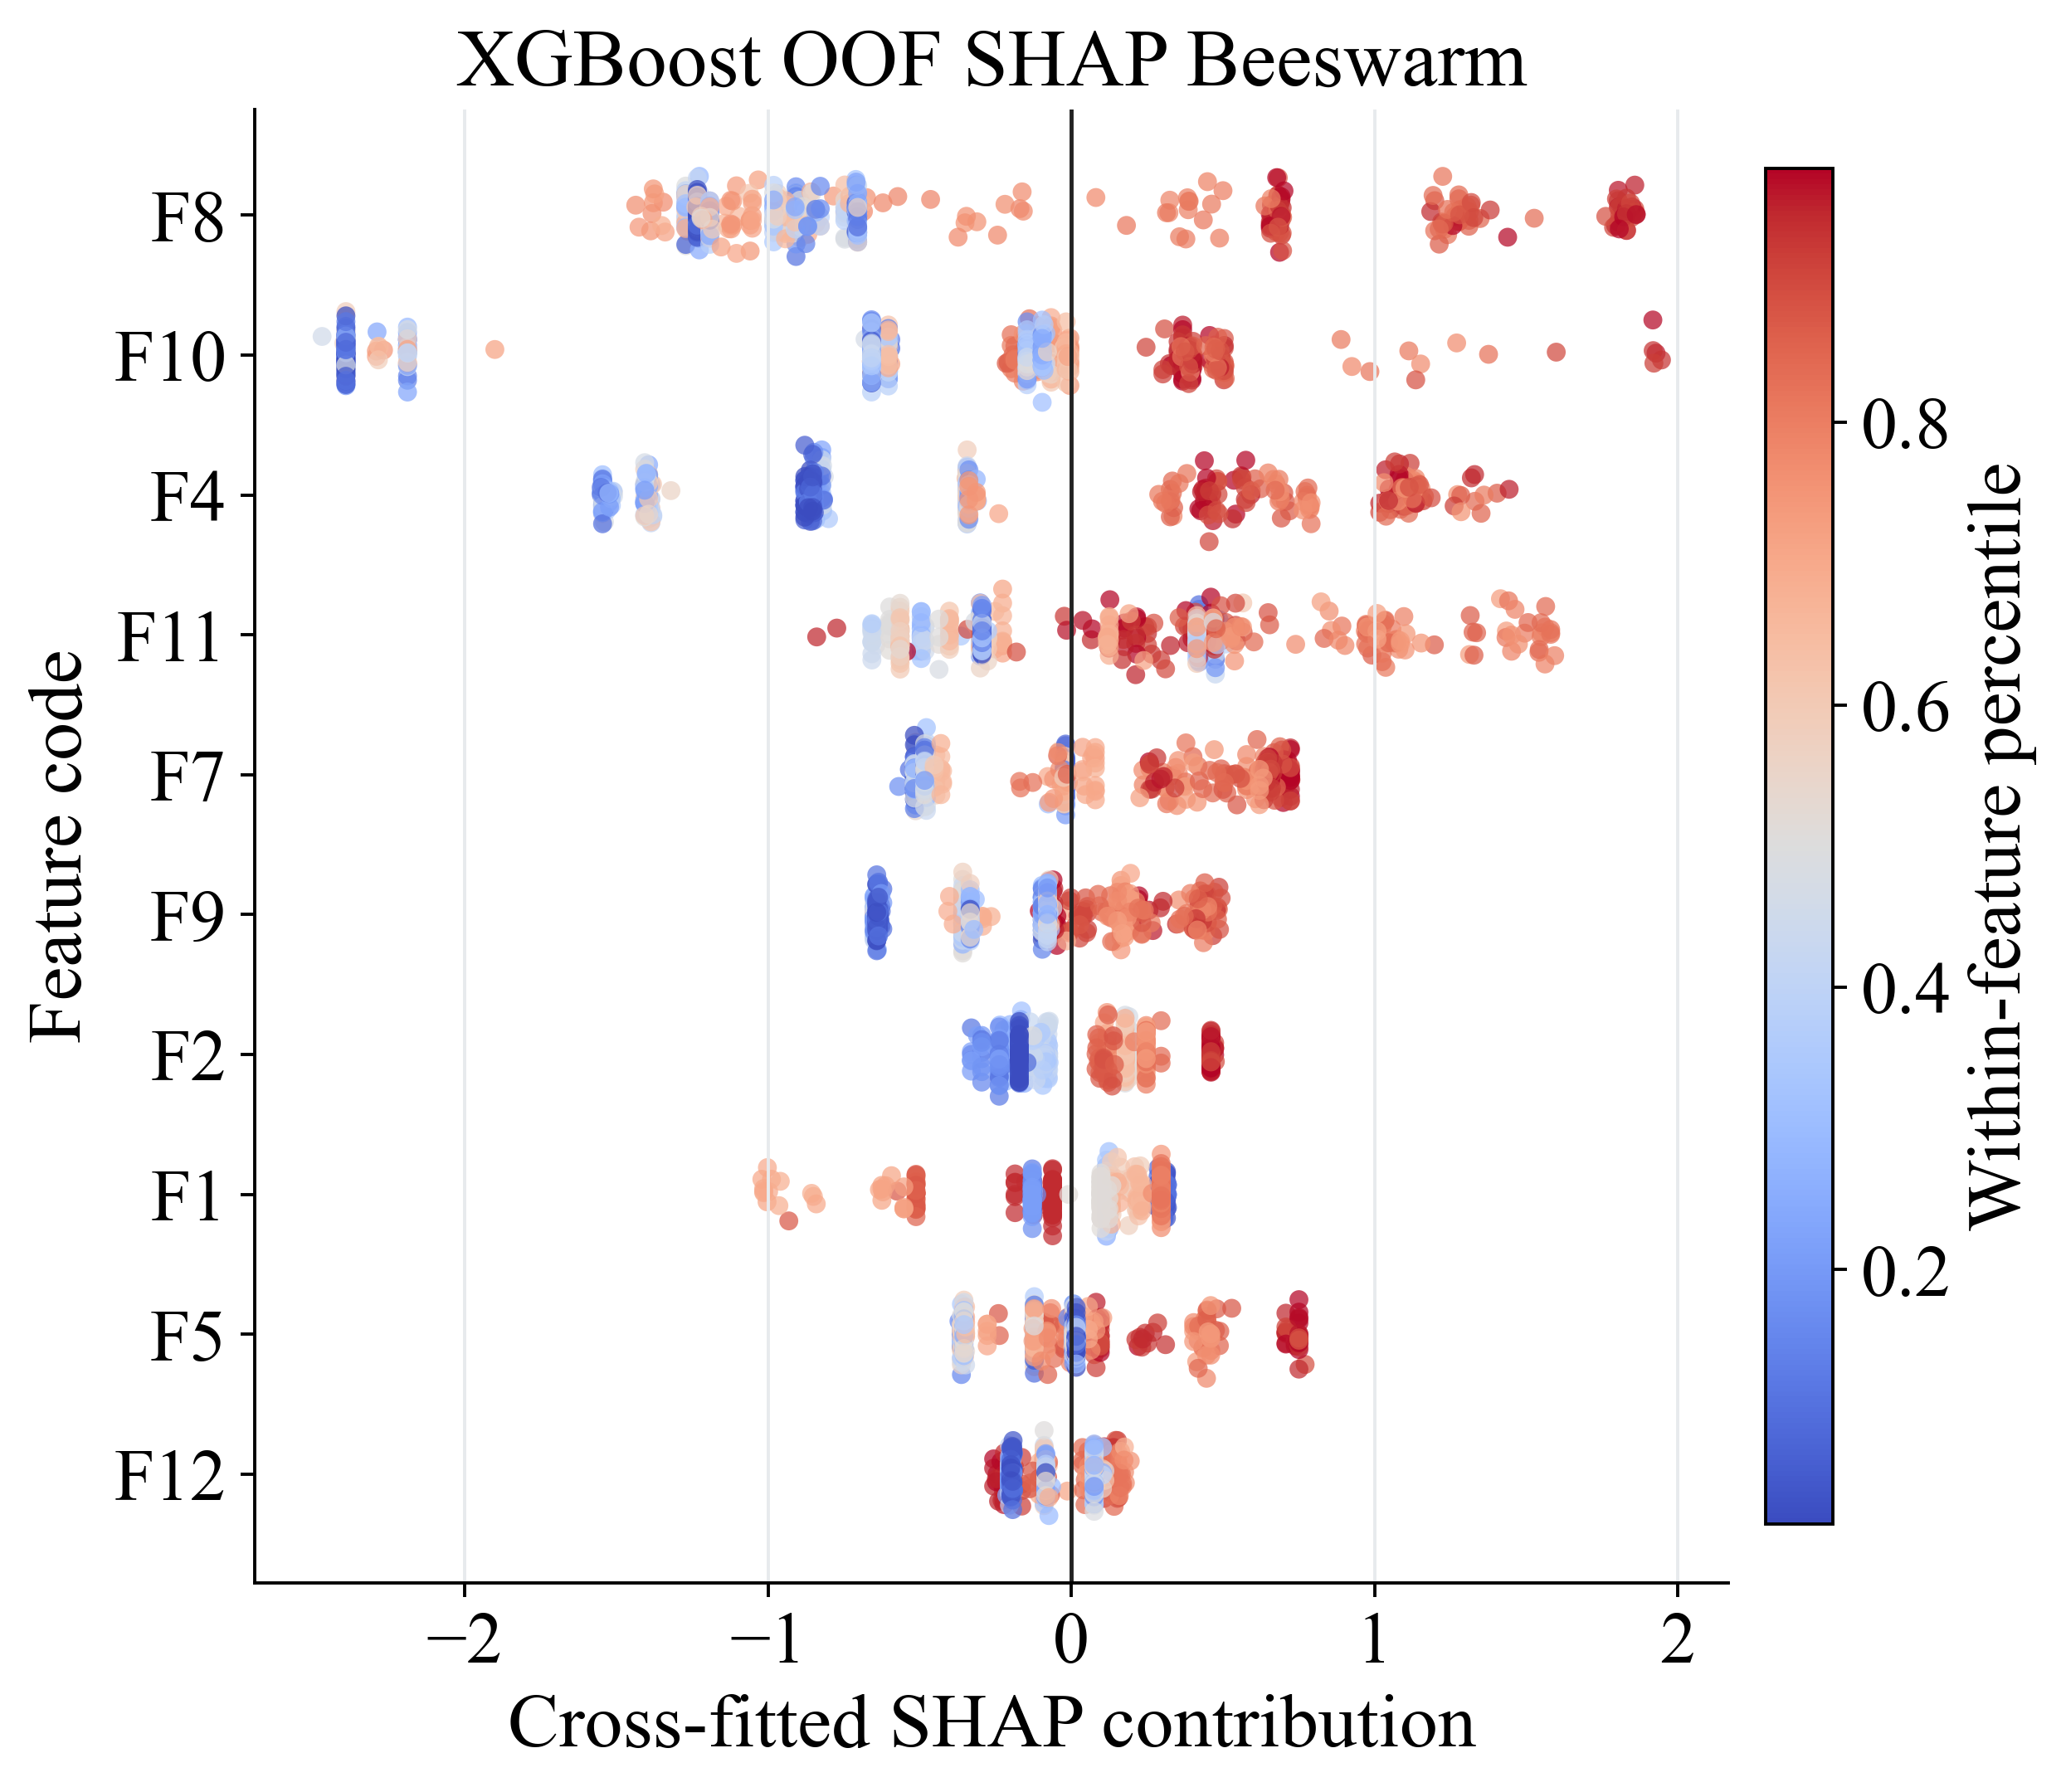

In [46]:
mean_absolute_shap = np.mean(np.abs(xgb_oof_shap), axis=0)
top_indices = np.argsort(mean_absolute_shap)[-10:]
fig, axis = figure_subplots(
    1, 1, span="double", labels=[feature_codes[selected_features[i]] for i in top_indices],
    square_panel=True, height_mm=178.0,
)
rng = np.random.default_rng(SEED)
color_normalizer = Normalize(vmin=0.02, vmax=0.98, clip=True)
for row_index, feature_index in enumerate(top_indices):
    feature_values = diagnostic_train_imputed.iloc[:, feature_index].rank(pct=True).to_numpy()
    jitter = rng.normal(0.0, 0.10, len(feature_values))
    axis.scatter(
        xgb_oof_shap[:, feature_index], row_index + jitter,
        c=feature_values, cmap="coolwarm", norm=color_normalizer,
        s=22, alpha=0.72, edgecolor="none",
    )
axis.axvline(0.0, color=PALETTE["black"], linewidth=1.0)
axis.set_yticks(np.arange(len(top_indices)), [
    feature_codes[selected_features[index]] for index in top_indices
])
axis.set_xlabel("Cross-fitted SHAP contribution")
axis.set_ylabel("Feature code")
axis.set_title("XGBoost OOF SHAP Beeswarm")
axis.grid(axis="x", color=PALETTE["grid"])
colorbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=color_normalizer, cmap="coolwarm"),
    ax=axis, fraction=0.046, pad=0.025,
)
colorbar.set_label("Within-feature percentile")
_ = save_show_figure(fig, FIGURES / "02_xgboost_shap_beeswarm.png", span="double")


The beeswarm uses only OOF contributions from development Group-CV. Feature codes map to the complete association table, avoiding clipped long labels.


### Cross-fitted SHAP effect dependence

How does the held-out contribution change across the observed percentile range of the two strongest continuous features?

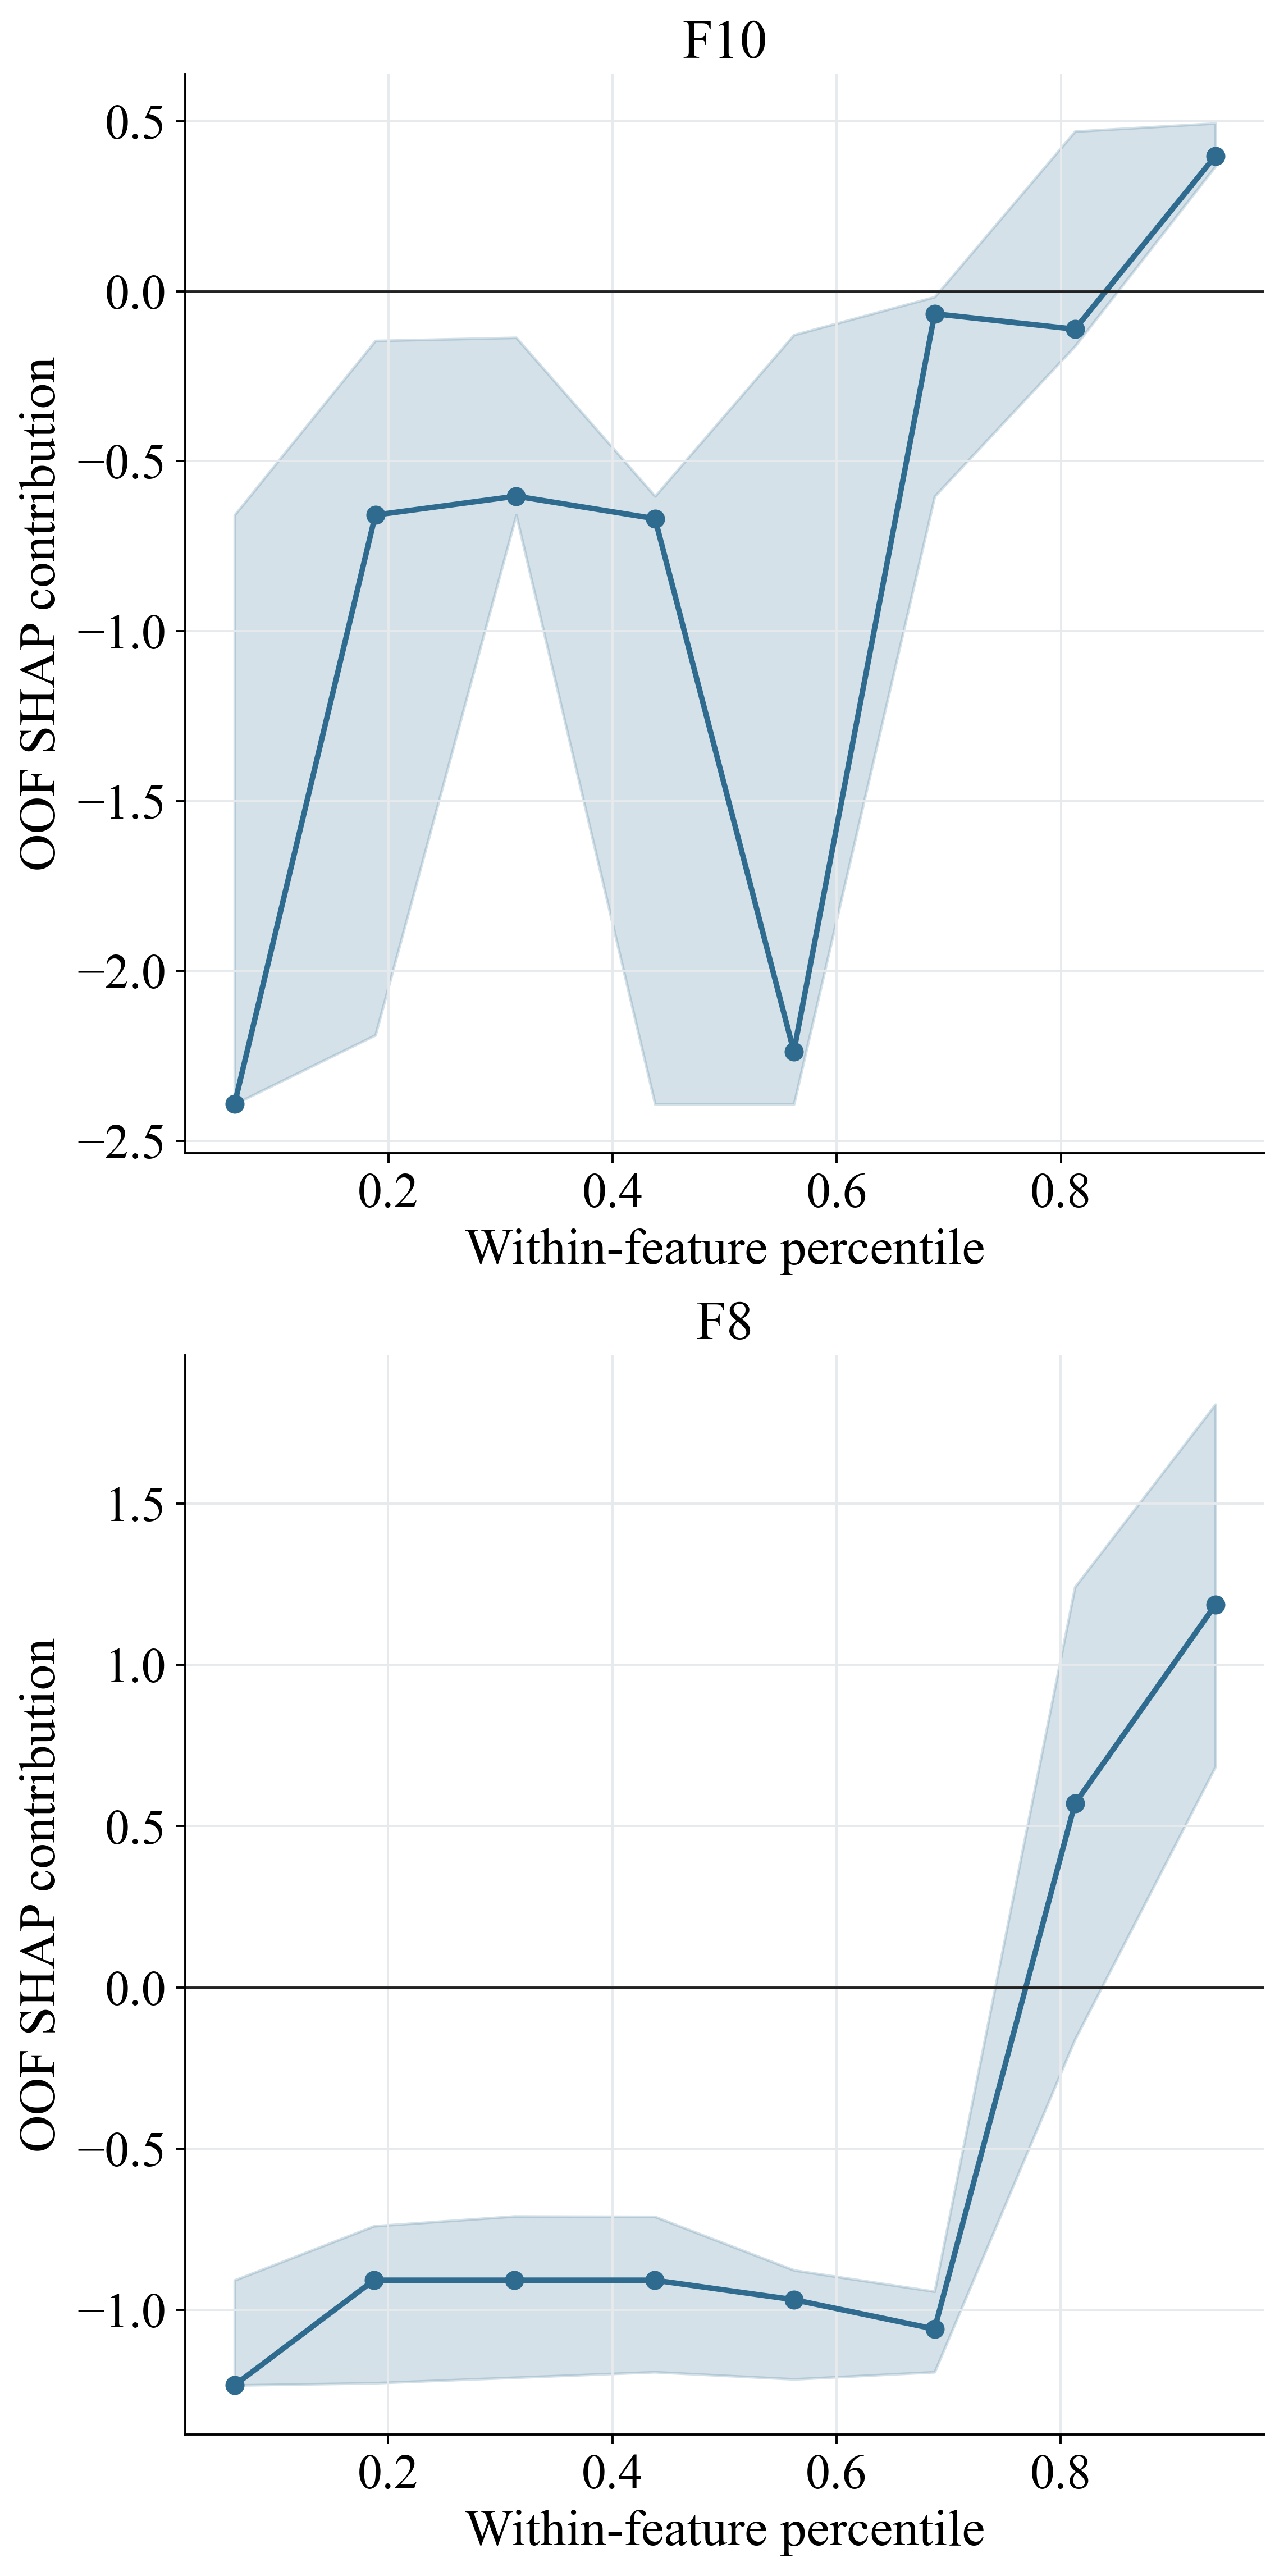

In [47]:
effect_indices = top_indices[-2:]
fig, axes = figure_subplots(
    2, 1, span="double", square_axes=True, height_mm=330.0
)
for axis, feature_index in zip(axes, effect_indices):
    percentiles = diagnostic_train_imputed.iloc[:, feature_index].rank(pct=True)
    effect_frame = pd.DataFrame({
        "percentile": percentiles,
        "shap": xgb_oof_shap[:, feature_index],
    })
    effect_frame["bin"] = pd.cut(
        effect_frame["percentile"], np.linspace(0.0, 1.0, 9),
        include_lowest=True,
    )
    summary = effect_frame.groupby("bin", observed=True).agg(
        x=("percentile", "median"), median=("shap", "median"),
        q25=("shap", lambda values: values.quantile(0.25)),
        q75=("shap", lambda values: values.quantile(0.75)),
    )
    axis.fill_between(summary["x"], summary["q25"], summary["q75"],
                      color=PALETTE["baseline"], alpha=0.20)
    axis.plot(summary["x"], summary["median"], color=PALETTE["baseline"],
              marker="o", linewidth=2.0)
    axis.axhline(0.0, color=PALETTE["black"], linewidth=1.0)
    axis.set_xlabel("Within-feature percentile")
    axis.set_ylabel("OOF SHAP contribution")
    axis.set_title(feature_codes[selected_features[feature_index]])
    axis.grid(color=PALETTE["grid"])
_ = save_show_figure(
    fig, FIGURES / "02_xgboost_shap_dependence.png", span="double"
)

The lines summarize median held-out SHAP effects and interquartile uncertainty without implying causality; complete feature names remain available in the association table.

## Missingness mechanisms

How much incomplete engineered information remains by split after deterministic exclusions, and is it concentrated by row or by feature?

In [48]:
missingness_rows = []
for split_name in split_order:
    split_frame = modeling_dataset.loc[
        modeling_dataset["split"].eq(split_name), clean_feature_columns
    ]
    feature_missing = split_frame.isna().mean()
    row_missing = split_frame.isna().mean(axis=1)
    missingness_rows.append(
        {
            "split": split_name,
            "n": len(split_frame),
            "features_evaluated": len(clean_feature_columns),
            "overall_missing_percent": 100.0 * split_frame.isna().to_numpy().mean(),
            "rows_with_any_missing_percent": 100.0 * split_frame.isna().any(axis=1).mean(),
            "median_row_missing_percent": 100.0 * row_missing.median(),
            "median_feature_missing_percent": 100.0 * feature_missing.median(),
            "maximum_feature_missing_percent": 100.0 * feature_missing.max(),
        }
    )
missingness_summary = pd.DataFrame(missingness_rows)
display_grouped_tables(
    missingness_summary,
    identifier_columns=["split", "n"],
    column_groups={
        "Missingness scope": ["features_evaluated", "overall_missing_percent"],
        "Row-wise missingness": [
            "rows_with_any_missing_percent", "median_row_missing_percent",
        ],
        "Feature-wise missingness": [
            "median_feature_missing_percent", "maximum_feature_missing_percent",
        ],
    },
    digits=3,
)


#### Missingness scope

,split,n,features_evaluated,overall_missing_percent
0,train,563,748,0.243
1,validation,192,748,0.534
2,internal_test,172,748,0.065
3,external,1585,748,0.485


#### Row-wise missingness

,split,n,rows_with_any_missing_percent,median_row_missing_percent
0,train,563,25.222,0.000
1,validation,192,8.333,0.000
2,internal_test,172,24.419,0.000
3,external,1585,96.151,0.267


#### Feature-wise missingness

,split,n,median_feature_missing_percent,maximum_feature_missing_percent
0,train,563,0.178,23.623
1,validation,192,0.521,6.250
2,internal_test,172,0.000,21.512
3,external,1585,0.126,95.205


Missingness is retained as information rather than used as an automatic deletion rule. The table separates row-wise and feature-wise burden; causal-prefix masks and categorical unknown tokens are quantified separately in the preprocessing representation table.

### Co-missingness structure

Which incompleteness patterns co-occur among partially observed engineered features, and do their marginal rates differ across splits?

In [49]:
partial_missingness = (
    modeling_dataset.loc[train_mask, clean_feature_columns]
    .isna().mean()
    .loc[lambda series: series.between(0.01, 0.99)]
    .sort_values(ascending=False)
)
missing_features = partial_missingness.head(8).index.tolist()
assert len(missing_features) >= 4
missing_codes = [f"M{index + 1}" for index in range(len(missing_features))]
missing_split_point = math.ceil(len(missing_features) / 2)
indicator_frame = modeling_dataset.loc[train_mask, missing_features].isna().astype(float)
phi_matrix = indicator_frame.corr().fillna(0.0).to_numpy()


In [50]:
def plot_phi_block(
    row_indices: list[int] | range, column_indices: list[int] | range,
    title: str, output_name: str,
    height_mm: float = 98.0,
) -> dict[str, object]:
    """Plot one compact unique block of the train co-missingness matrix."""
    rows, columns = list(row_indices), list(column_indices)
    row_codes = [missing_codes[index] for index in rows]
    column_codes = [missing_codes[index] for index in columns]
    matrix_block = phi_matrix[np.ix_(rows, columns)]
    fig, ax = figure_subplots(
        1, 1, span="single", labels=row_codes + column_codes,
        annotation_rows=max(len(rows), len(columns)), square_panel=True,
        height_mm=height_mm,
    )
    image = ax.imshow(
        matrix_block, cmap=mpl.colormaps["RdBu_r"], vmin=-1.0, vmax=1.0,
        aspect="equal", interpolation="nearest",
    )
    ax.set_xticks(np.arange(len(columns)), column_codes, rotation=0, ha="center")
    ax.set_yticks(np.arange(len(rows)), row_codes)
    ax.set_xlabel("Column code")
    ax.set_ylabel("Row code", labelpad=2)
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.025)
    colorbar.set_label(r"$\phi$")
    annotate_heatmap_values(image, digits=2)
    ax.set_title(title.replace(": ", ":\n"), pad=10)
    return save_show_figure(fig, FIGURES / output_name, span="single")


#### Within-block co-missingness for the first feature block

Which missingness indicators co-occur inside the first partially observed feature block?

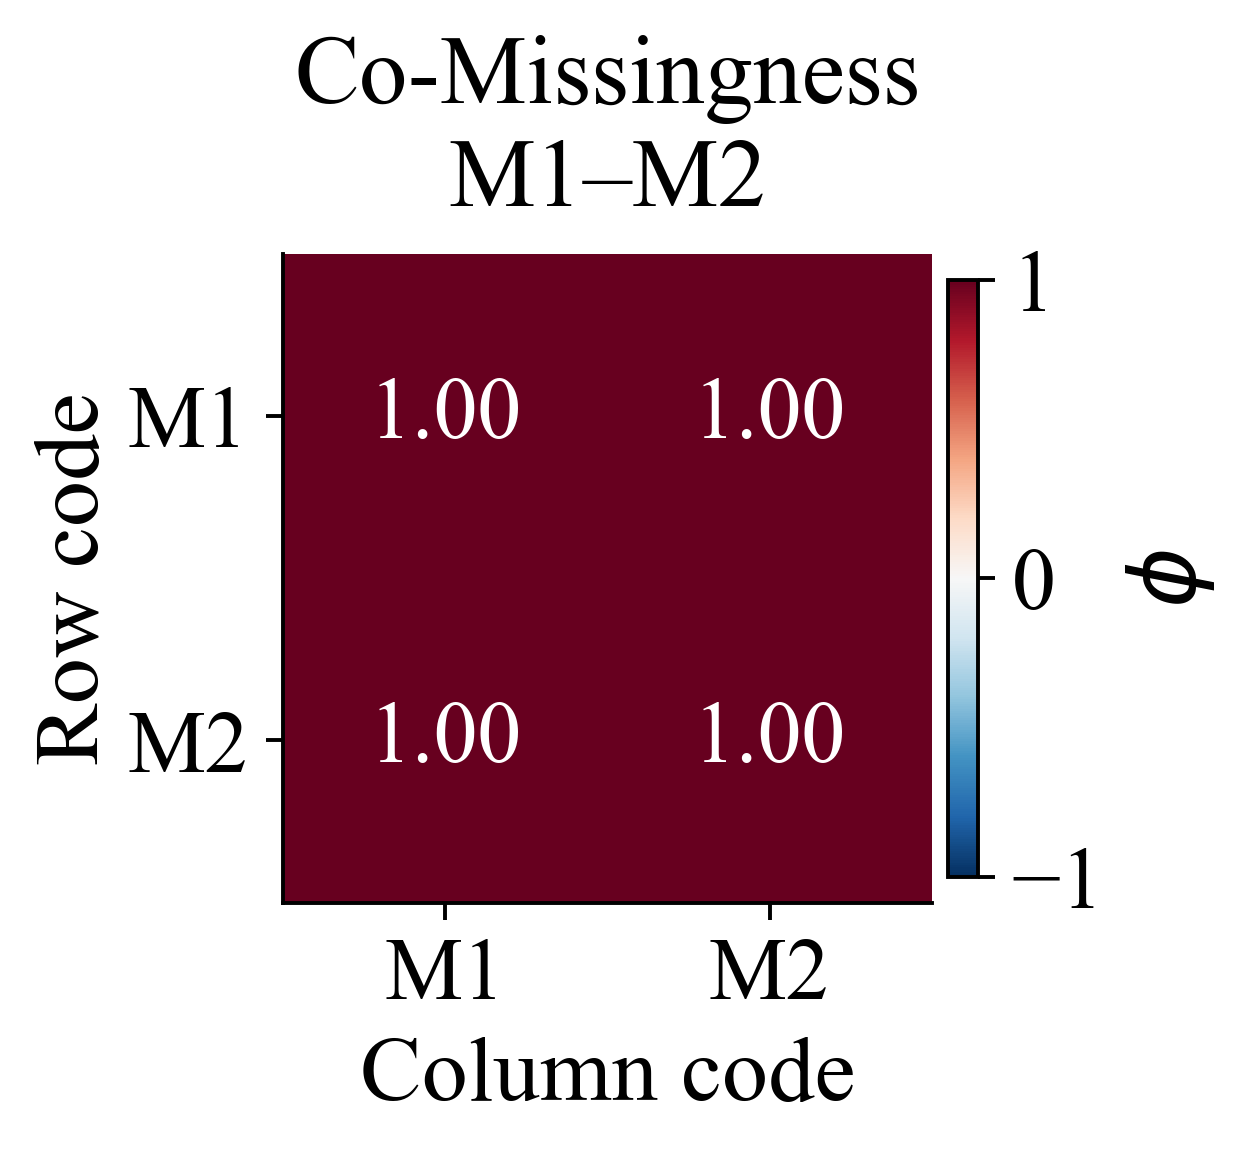

In [51]:
_ = plot_phi_block(
    range(0, missing_split_point), range(0, missing_split_point),
    f"Co-Missingness\n{missing_codes[0]}–{missing_codes[missing_split_point - 1]}",
    "02_comissingness_structure.png",
)


The first diagonal block isolates joint missingness inside the data-determined first half of the observed indicators. Contrast-adaptive annotations preserve every displayed $\phi$ coefficient without reducing the scientific font size.

#### Cross-block co-missingness

Which missingness patterns connect the two data-determined indicator blocks?

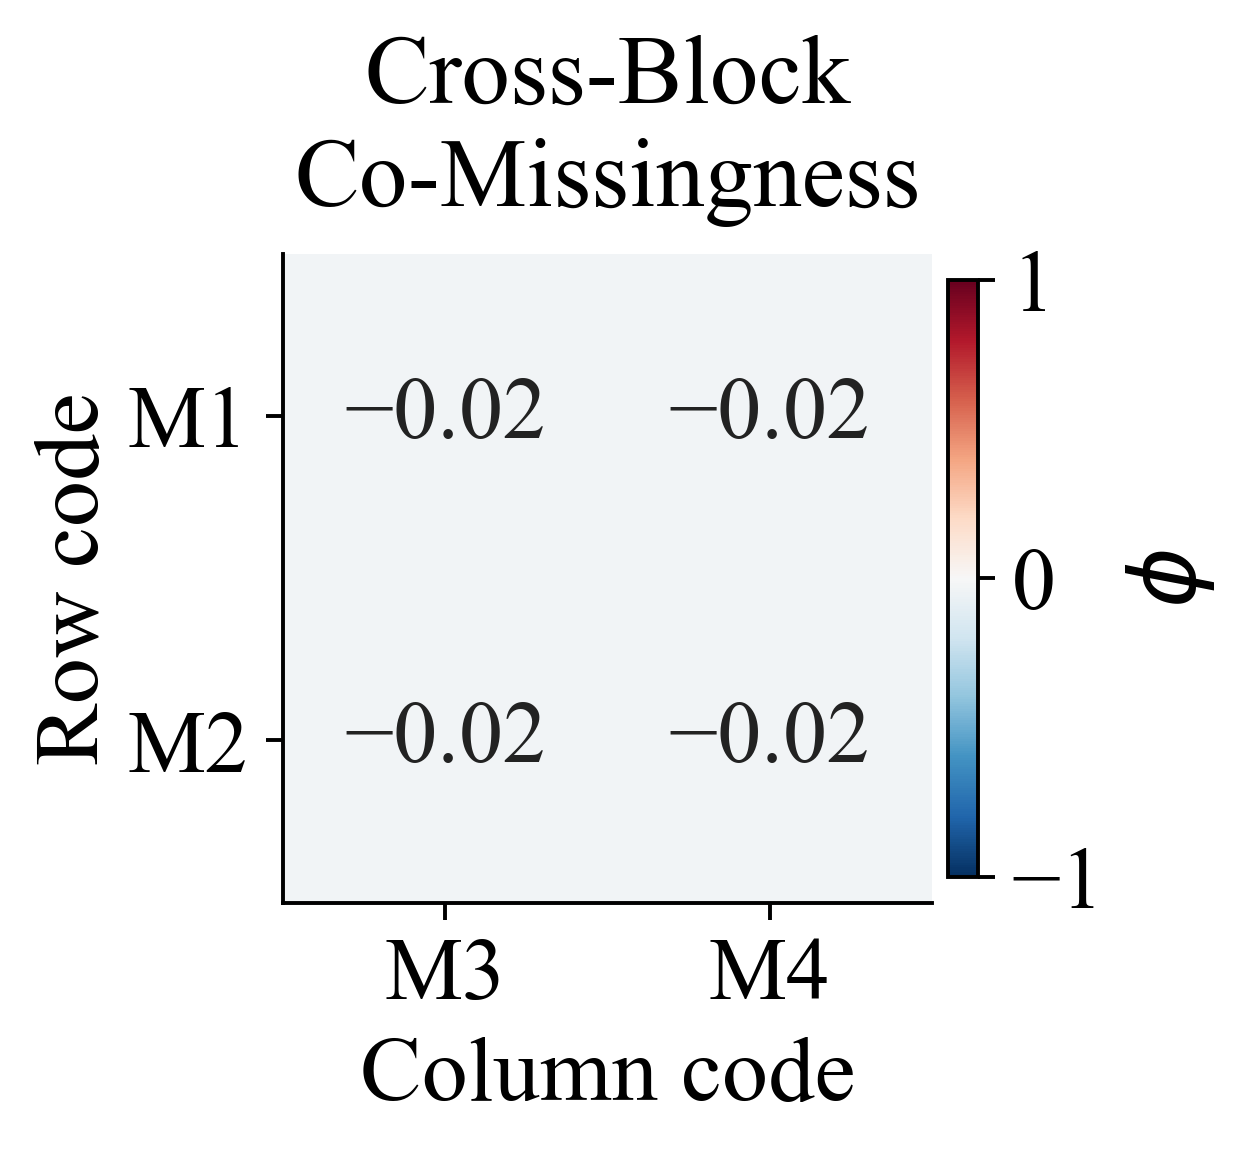

In [52]:
_ = plot_phi_block(
    range(0, missing_split_point), range(missing_split_point, len(missing_features)),
    "Cross-Block\nCo-Missingness",
    "02_comissingness_structure_cross.png",
    height_mm=112.0,
)


The cross-block canvas reports every coefficient between the two observed indicator blocks once; its symmetric transpose is intentionally omitted as redundant.

#### Within-block co-missingness for the second feature block

Which incompleteness patterns co-occur inside the second feature block?

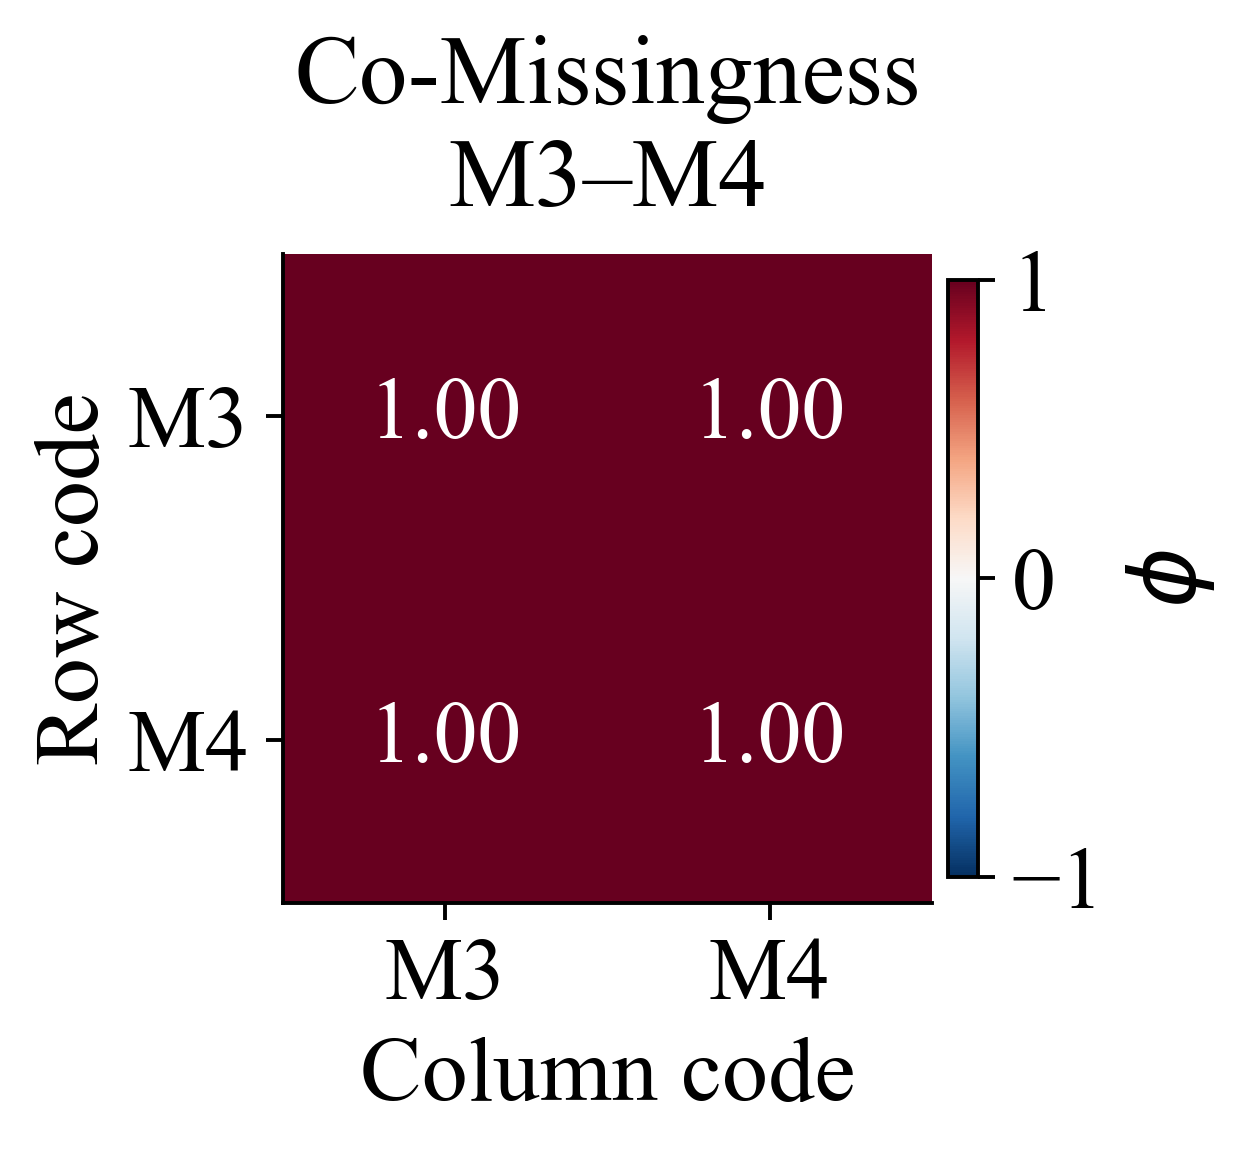

In [53]:
_ = plot_phi_block(
    range(missing_split_point, len(missing_features)),
    range(missing_split_point, len(missing_features)),
    f"Co-Missingness\n{missing_codes[missing_split_point]}–{missing_codes[-1]}",
    "02_comissingness_structure_block_b.png",
)


The two diagonal blocks and one cross-block canvas cover all unique entries of the symmetric observed-feature $\phi$ matrix. Full feature names remain available through the persisted code mapping.

### Marginal missingness across data domains

Does the marginal missingness burden of the same partially observed features change across train, validation, internal test, and external data?

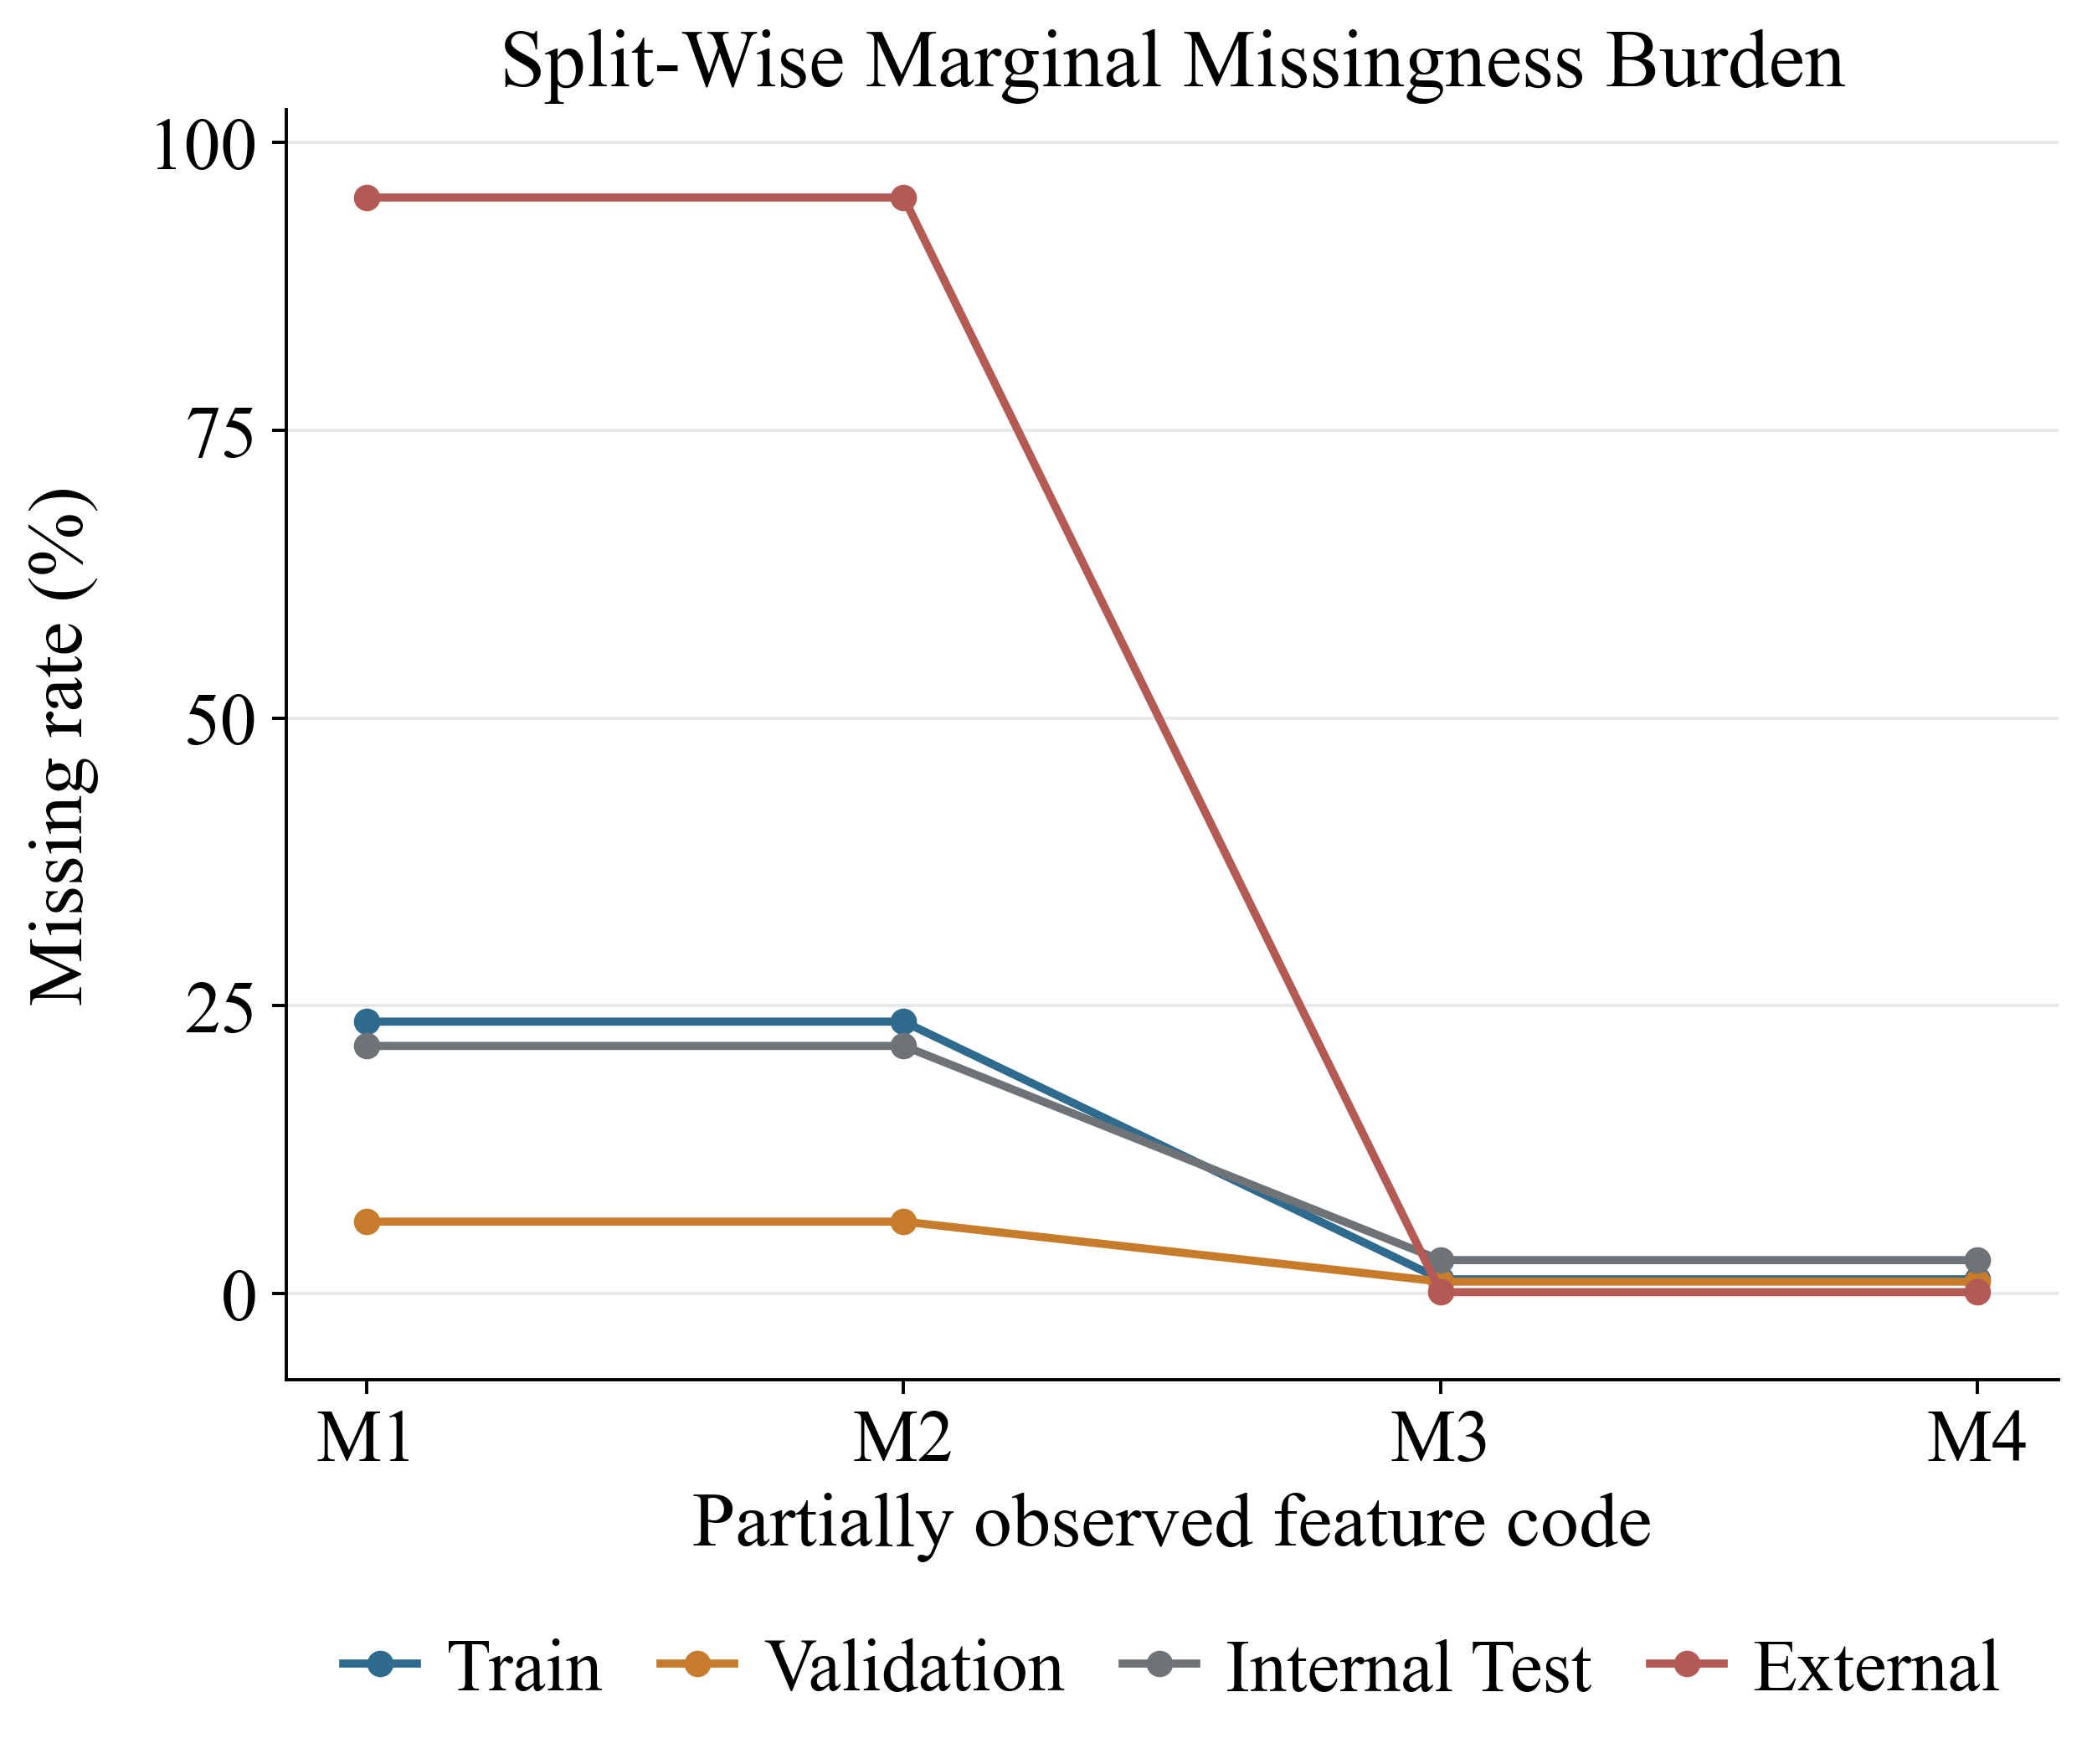

In [54]:
positions = np.arange(len(missing_features))
comissingness_mapping = pd.DataFrame(
    {
        "feature_code": missing_codes,
        "feature": missing_features,
        "train_missing_percent": [
            100.0 * partial_missingness[feature] for feature in missing_features
        ],
    }
)
split_missingness = pd.DataFrame(
    {
        split_name: 100.0 * modeling_dataset.loc[
            modeling_dataset["split"].eq(split_name), missing_features
        ].isna().mean()
        for split_name in split_order
    }
)
fig, ax = figure_subplots(
    1, 1, span="double", labels=missing_codes, legend_items=4, height_mm=150.0,
)
for split_name in split_order:
    ax.plot(
        positions, split_missingness[split_name].to_numpy(),
        marker="o", linewidth=2.0, markersize=5.5,
        color=split_colors[split_name],
        label=split_name.replace("_", " ").title(),
    )
ax.set_xticks(positions, missing_codes)
ax.set_xlabel("Partially observed feature code")
ax.set_ylabel("Missing rate (%)", labelpad=12)
ax.set_title("Split-Wise Marginal Missingness Burden")
ax.margins(y=0.08)
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, prune="upper"))
ax.grid(axis="y", color=PALETTE["grid"])
legend_below(
    ax, ncol=4, columnspacing=0.8, handlelength=1.0, handletextpad=0.4
)
_ = save_show_figure(fig, FIGURES / "02_missingness_by_split.png", span="double")


The separate domain canvas compares marginal burden without compressing the co-missingness matrix. Differences across splits quantify support change and do not trigger automatic observation deletion.

## Train-to-domain distribution shift

How strongly do validation, internal-test, and cross-machine external distributions depart from development train over the same diagnostic features?

In [55]:
def distribution_shift(
    reference_values: pd.Series,
    comparison_values: pd.Series,
    bins: int = 10,
) -> tuple[float, float]:
    '''Return train-quantile PSI and Jensen–Shannon divergence.'''

    reference = pd.to_numeric(reference_values, errors="coerce").replace(
        [np.inf, -np.inf], np.nan
    ).dropna().to_numpy(float)
    comparison = pd.to_numeric(comparison_values, errors="coerce").replace(
        [np.inf, -np.inf], np.nan
    ).dropna().to_numpy(float)
    if len(reference) < 5 or len(comparison) < 5 or np.nanstd(reference) == 0:
        return np.nan, np.nan
    edges = np.unique(np.quantile(reference, np.linspace(0.0, 1.0, bins + 1)))
    edges = np.r_[-np.inf, edges[1:-1], np.inf]
    reference_probability = np.histogram(reference, bins=edges)[0].astype(float)
    comparison_probability = np.histogram(comparison, bins=edges)[0].astype(float)
    reference_probability = (reference_probability + 0.5) / (
        reference_probability.sum() + 0.5 * len(reference_probability)
    )
    comparison_probability = (comparison_probability + 0.5) / (
        comparison_probability.sum() + 0.5 * len(comparison_probability)
    )
    psi = float(
        np.sum(
            (comparison_probability - reference_probability)
            * np.log(comparison_probability / reference_probability)
        )
    )
    js_divergence = float(
        jensenshannon(reference_probability, comparison_probability, base=2) ** 2
    )
    return psi, js_divergence


In [56]:
def holm_adjust(p_values: np.ndarray) -> np.ndarray:
    '''Return monotone Holm-adjusted p-values for one test family.'''

    values = np.asarray(p_values, dtype=float)
    order = np.argsort(values)
    adjusted = np.empty_like(values)
    running = 0.0
    family_size = len(values)
    for rank, index in enumerate(order):
        running = max(running, (family_size - rank) * values[index])
        adjusted[index] = min(1.0, running)
    return adjusted
shift_rows = []
reference_rows = modeling_dataset["split"].eq("train")


In [57]:
for comparison_split in ["validation", "internal_test", "external"]:
    comparison_rows = modeling_dataset["split"].eq(comparison_split)
    family_start = len(shift_rows)
    p_values = []
    for feature in selected_features:
        reference = modeling_dataset.loc[reference_rows, feature]
        comparison = modeling_dataset.loc[comparison_rows, feature]
        psi, js_divergence = distribution_shift(reference, comparison)
        finite_reference = pd.to_numeric(reference, errors="coerce").dropna()
        finite_comparison = pd.to_numeric(comparison, errors="coerce").dropna()
        ks_result = stats.ks_2samp(
            finite_reference,
            finite_comparison,
            alternative="two-sided",
            method="auto",
        )
        p_values.append(float(ks_result.pvalue))
        shift_rows.append(
            {
                "reference_split": "train",
                "comparison_split": comparison_split,
                "feature": feature,
                "n_reference": int(reference_rows.sum()),
                "n_comparison": int(comparison_rows.sum()),
                "population_stability_index": psi,
                "jensen_shannon_divergence": js_divergence,
                "ks_statistic": float(ks_result.statistic),
                "ks_p_value": float(ks_result.pvalue),
                "holm_adjusted_p_value": np.nan,
                "missingness_shift_percentage_points": 100.0 * (
                    comparison.isna().mean() - reference.isna().mean()
                ),
            }
        )
    adjusted = holm_adjust(np.asarray(p_values))
    for offset, adjusted_value in enumerate(adjusted):
        shift_rows[family_start + offset]["holm_adjusted_p_value"] = adjusted_value
domain_shift_metrics = pd.DataFrame(shift_rows)
domain_shift_metrics["feature_code"] = domain_shift_metrics["feature"].map(feature_codes)


In [58]:
display_grouped_tables(
    domain_shift_metrics,
    identifier_columns=[
        "reference_split", "comparison_split", "feature_code", "feature", "n_reference", "n_comparison",
    ],
    column_groups={
        "Distribution distance": [
            "population_stability_index", "jensen_shannon_divergence", "ks_statistic",
        ],
        "Multiplicity-corrected inference": [
            "ks_p_value", "holm_adjusted_p_value",
        ],
        "Completeness shift": ["missingness_shift_percentage_points"],
    },
    digits=4,
)


#### Distribution distance

,reference_split,comparison_split,feature_code,feature,n_reference,n_comparison,population_stability_index,jensen_shannon_divergence,ks_statistic
0,train,validation,F1,machine_time__mean,563,192,2.6541,0.3472,0.4389
1,train,validation,F2,z_position__mean,563,192,2.8055,0.3698,0.4442
2,train,validation,F3,Tool__train_frequency,563,192,5.0485,0.5331,0.6667
3,train,validation,F4,available_duration_s,563,192,1.4471,0.2044,0.2611
4,train,validation,F5,smarms__energy,563,192,0.6097,0.1027,0.2179
5,train,validation,F6,part_count__mean,563,192,2.2747,0.2942,0.4389
6,train,validation,F7,smapeak__energy,563,192,0.5351,0.0864,0.2042
7,train,validation,F8,ymapeak__energy,563,192,0.4144,0.0719,0.2071
8,train,validation,F9,machine_time__energy,563,192,1.3515,0.1930,0.2295
9,train,validation,F10,zmapeak__energy,563,192,0.5135,0.0880,0.1865


#### Multiplicity-corrected inference

,reference_split,comparison_split,feature_code,feature,n_reference,n_comparison,ks_p_value,holm_adjusted_p_value
0,train,validation,F1,machine_time__mean,563,192,0.0000,0.0000
1,train,validation,F2,z_position__mean,563,192,0.0000,0.0000
2,train,validation,F3,Tool__train_frequency,563,192,0.0000,0.0000
3,train,validation,F4,available_duration_s,563,192,0.0000,0.0000
4,train,validation,F5,smarms__energy,563,192,0.0000,0.0000
5,train,validation,F6,part_count__mean,563,192,0.0000,0.0000
6,train,validation,F7,smapeak__energy,563,192,0.0000,0.0000
7,train,validation,F8,ymapeak__energy,563,192,0.0000,0.0000
8,train,validation,F9,machine_time__energy,563,192,0.0000,0.0000
9,train,validation,F10,zmapeak__energy,563,192,0.0001,0.0001


#### Completeness shift

,reference_split,comparison_split,feature_code,feature,n_reference,n_comparison,missingness_shift_percentage_points
0,train,validation,F1,machine_time__mean,563,192,0.3432
1,train,validation,F2,z_position__mean,563,192,0.3432
2,train,validation,F3,Tool__train_frequency,563,192,0.0000
3,train,validation,F4,available_duration_s,563,192,0.0000
4,train,validation,F5,smarms__energy,563,192,0.3432
5,train,validation,F6,part_count__mean,563,192,0.3432
6,train,validation,F7,smapeak__energy,563,192,0.3432
7,train,validation,F8,ymapeak__energy,563,192,0.3432
8,train,validation,F9,machine_time__energy,563,192,0.3432
9,train,validation,F10,zmapeak__energy,563,192,0.3432


PSI and Jensen–Shannon divergence quantify effect magnitude. KS and Holm-adjusted p-values are path-level descriptive diagnostics because paths are nested in experiments; they are not presented as group-independent confirmatory inference.

### Experiment-grouped domain classifier

Can a classifier distinguish development-train paths from external-machine paths using only features and held-out experiments?

In [59]:
domain_rows = modeling_dataset["split"].isin(["train", "external"])
domain_frame = modeling_dataset.loc[domain_rows, selected_features].reset_index(drop=True)
domain_groups = modeling_dataset.loc[
    domain_rows, "experiment_group_id"
].to_numpy()
domain_target = modeling_dataset.loc[
    domain_rows, "split"
].eq("external").to_numpy(int)
domain_oof = np.full(len(domain_target), np.nan, dtype=float)
domain_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)
for fold_index, (fit_index, validation_index) in enumerate(
    domain_cv.split(domain_frame, domain_target, domain_groups)
):
    medians = domain_frame.iloc[fit_index].median()
    fit_values = domain_frame.iloc[fit_index].fillna(medians)
    validation_values = domain_frame.iloc[validation_index].fillna(medians)
    classifier = XGBClassifier(
        n_estimators=180, max_depth=3, learning_rate=0.04,
        subsample=0.85, colsample_bytree=0.85, min_child_weight=3,
        reg_alpha=0.10, reg_lambda=2.0, objective="binary:logistic",
        eval_metric="logloss", n_jobs=N_JOBS,
        random_state=SEED + fold_index,
    )
    classifier.fit(fit_values, domain_target[fit_index])
    domain_oof[validation_index] = classifier.predict_proba(validation_values)[:, 1]
assert np.isfinite(domain_oof).all()

In [60]:
domain_classifier_summary = pd.DataFrame([{
    "comparison": "train vs external",
    "n_paths": len(domain_target),
    "independent_experiments": int(pd.Series(domain_groups).nunique()),
    "oof_auroc": roc_auc_score(domain_target, domain_oof),
    "oof_balanced_accuracy": balanced_accuracy_score(
        domain_target, domain_oof >= 0.5
    ),
}])
display_grouped_tables(
    domain_classifier_summary,
    identifier_columns=["comparison", "n_paths", "independent_experiments"],
    column_groups={"Experiment-grouped domain discrimination": [
        "oof_auroc", "oof_balanced_accuracy",
    ]}, digits=4,
)

#### Experiment-grouped domain discrimination

,comparison,n_paths,independent_experiments,oof_auroc,oof_balanced_accuracy
0,train vs external,2148,48,0.9962,0.8863


High held-out domain discrimination is interpreted as covariate shift, not as evidence about intervention prediction. Outcome labels are not used.

### External shift geometry

For the four largest external PSI effects, where do the empirical distributions separate from development train?

In [61]:
external_shift_features = (
    domain_shift_metrics.loc[
        domain_shift_metrics["comparison_split"].eq("external")
    ]
    .nlargest(4, "population_stability_index")["feature"]
    .tolist()
)


In [62]:
def plot_external_ecdf_axis(axis, feature: str) -> None:
    """Draw one train-versus-external ECDF panel."""
    train_values = pd.to_numeric(
        modeling_dataset.loc[reference_rows, feature], errors="coerce"
    ).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
    external_values = pd.to_numeric(
        modeling_dataset.loc[modeling_dataset["split"].eq("external"), feature],
        errors="coerce",
    ).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
    pooled = np.r_[train_values, external_values]
    lower, upper = np.quantile(pooled, [0.01, 0.99])
    magnitude = max(abs(float(lower)), abs(float(upper)))
    exponent = int(3 * np.floor(np.log10(magnitude) / 3.0)) if magnitude > 0.0 else 0
    exponent = exponent if abs(exponent) >= 3 else 0
    scale = float(10.0 ** exponent)
    for values, label, color in [
        (train_values, "Train", split_colors["train"]),
        (external_values, "External", split_colors["external"]),
    ]:
        visible = np.sort(values[(values >= lower) & (values <= upper)]) / scale
        cumulative = np.arange(1, len(visible) + 1) / max(len(visible), 1)
        axis.plot(visible, cumulative, linewidth=2.1, color=color, label=label)
    axis.margins(x=0.10)
    axis.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, prune="both"))
    axis.set_title(feature_codes[feature])
    axis.set_xlabel(
        f"Feature value / $10^{{{exponent}}}$\n(central 98% pooled)"
        if exponent else "Feature value\n(central 98% pooled)"
    )
    axis.ticklabel_format(axis="x", style="plain", useOffset=False)
    axis.tick_params(axis="x", pad=8)
    axis.set_ylabel(r"ECDF, $F(x)$", labelpad=10)
    axis.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=4, prune="both"))
    axis.grid(color=PALETTE["grid"])


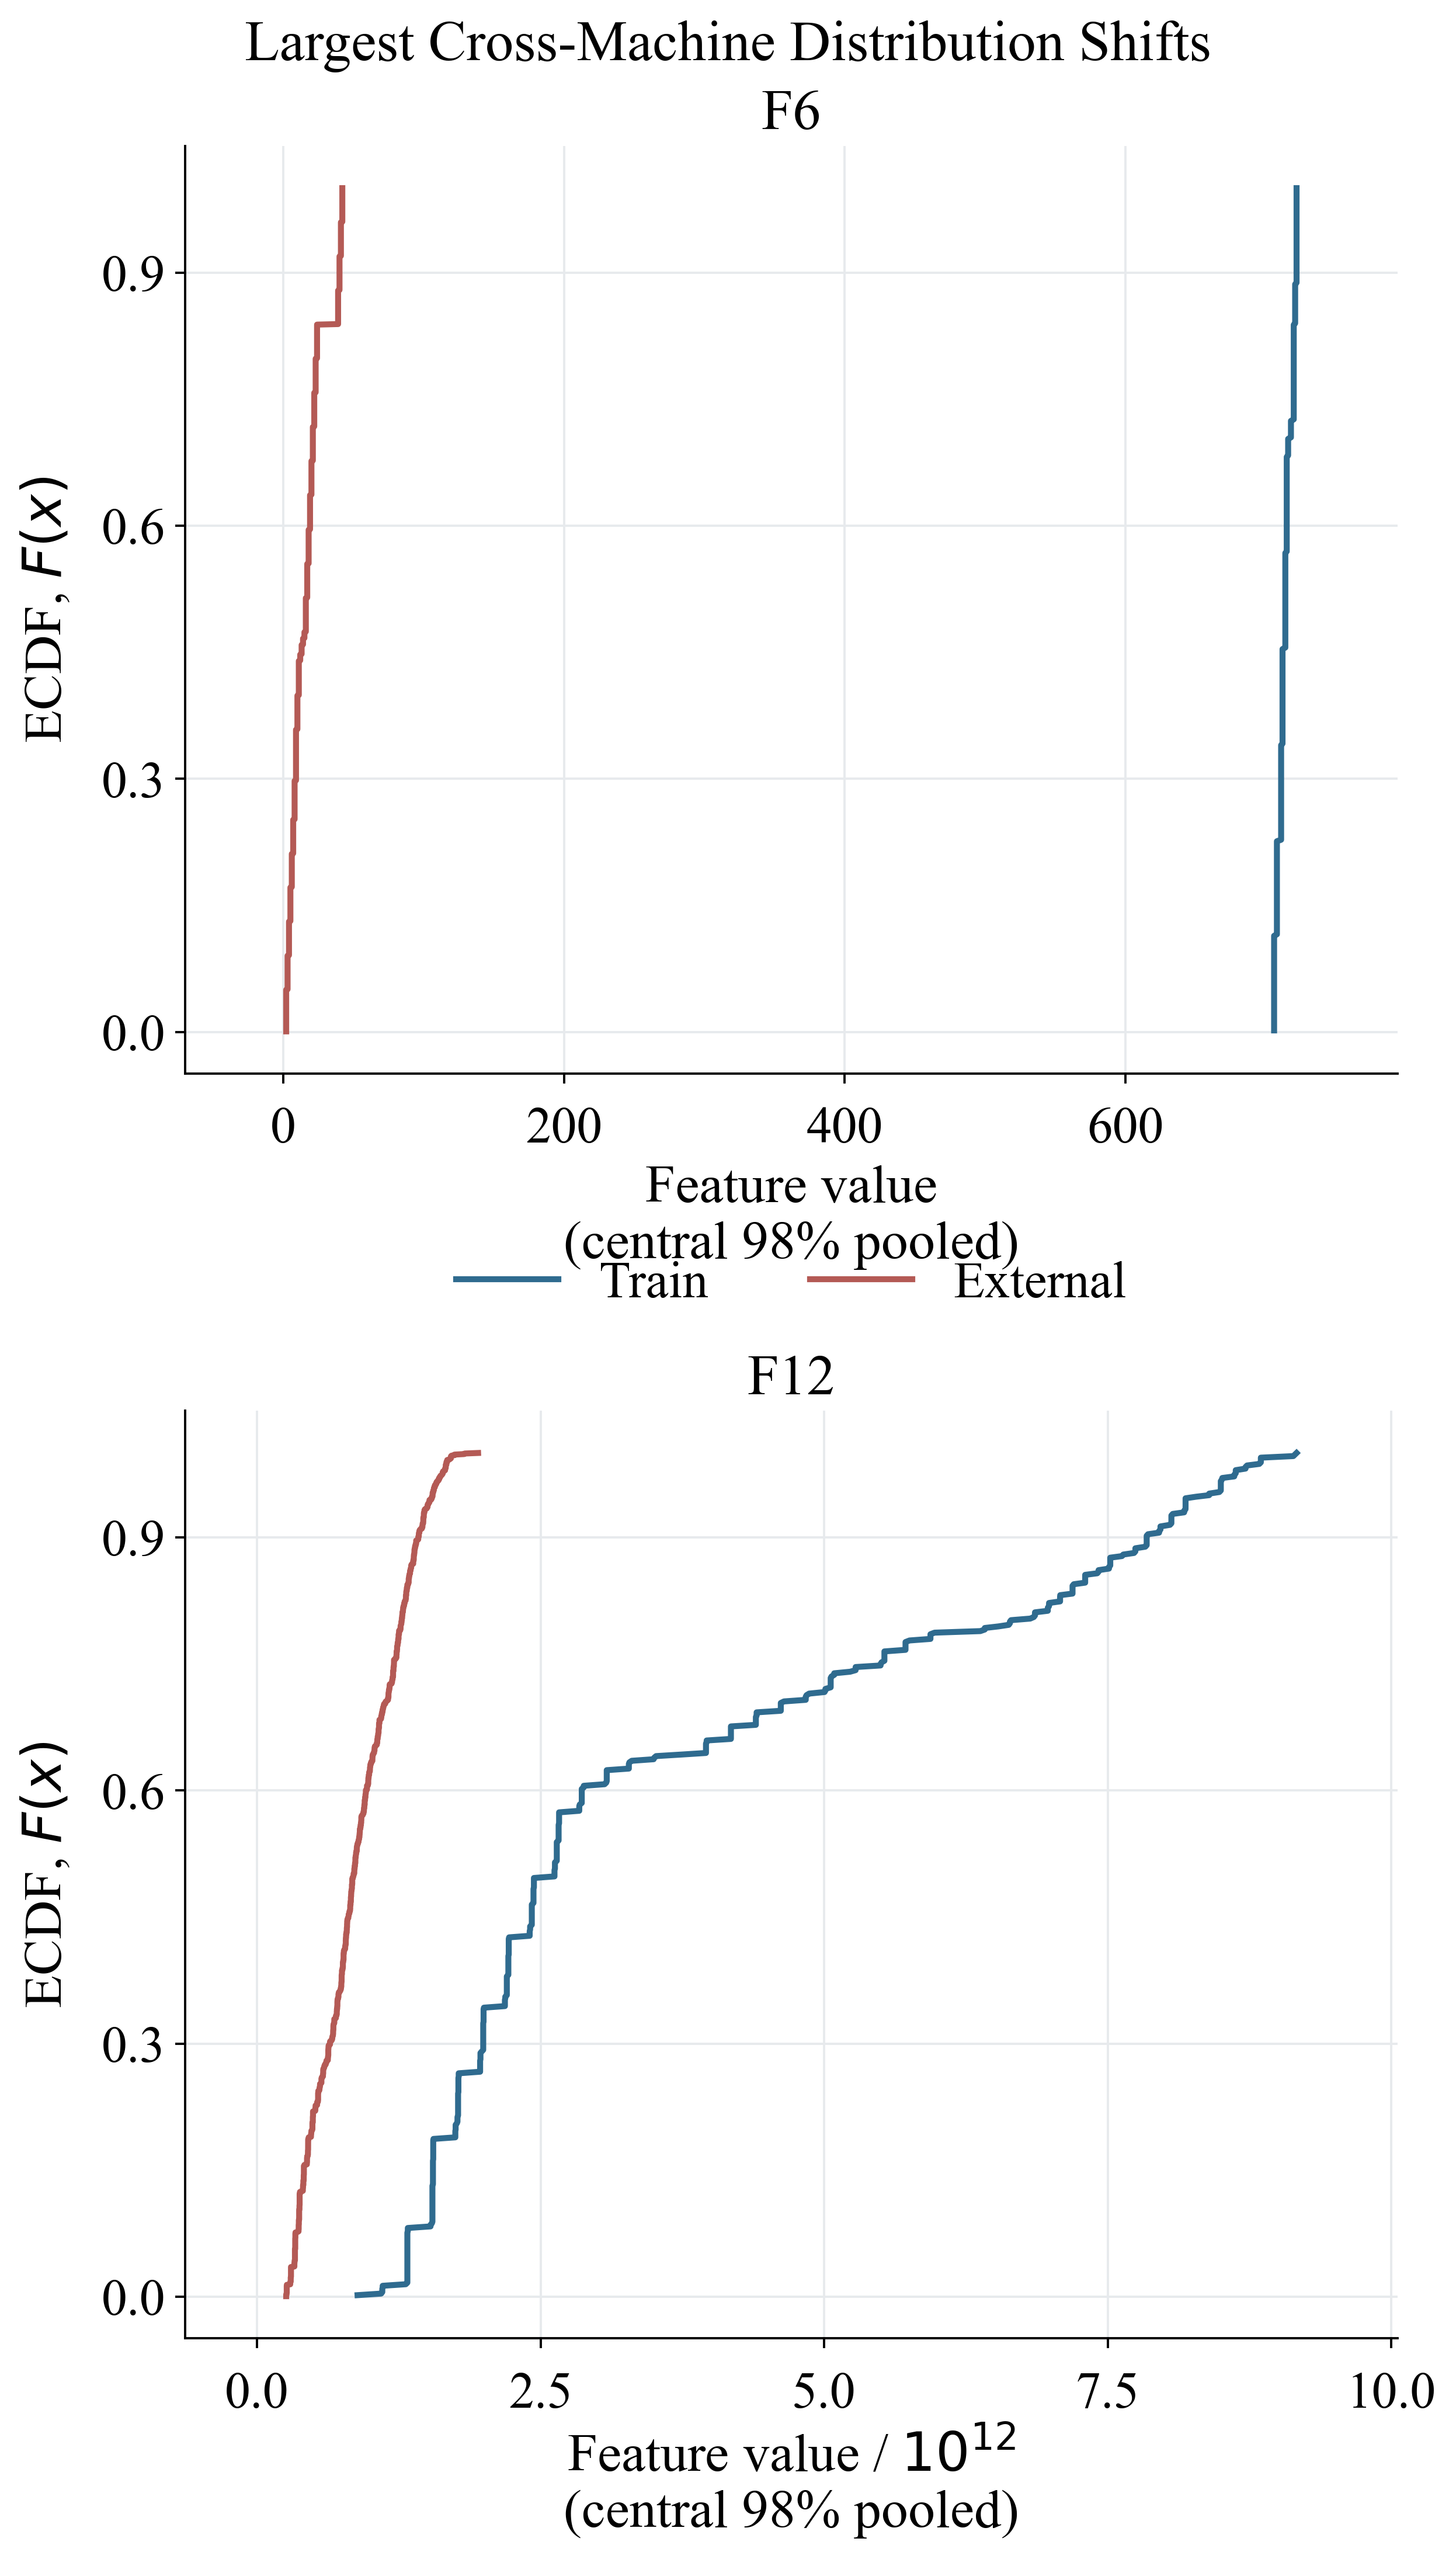

In [63]:
def plot_external_shift_ecdfs(features, output_name):
    """Plot two vertically aligned train-versus-external ECDFs."""
    fig, axes = figure_subplots(
        2, 1, span="double", legend_items=2, annotation_rows=2,
        square_axes=False, height_mm=315.0,
    )
    for axis, feature in zip(axes, features, strict=True):
        plot_external_ecdf_axis(axis, feature)
    legend_below(axes[0], ncol=2)
    fig.suptitle("Largest Cross-Machine Distribution Shifts")
    return save_show_figure(fig, FIGURES / output_name, span="double")
_ = plot_external_shift_ecdfs(
    external_shift_features[:2], "02_external_shift_ecdf.png"
)


### Additional external-shift distributions

The remaining two high-PSI features are shown on a separate canvas so that every panel retains full scientific typography and readable axes.

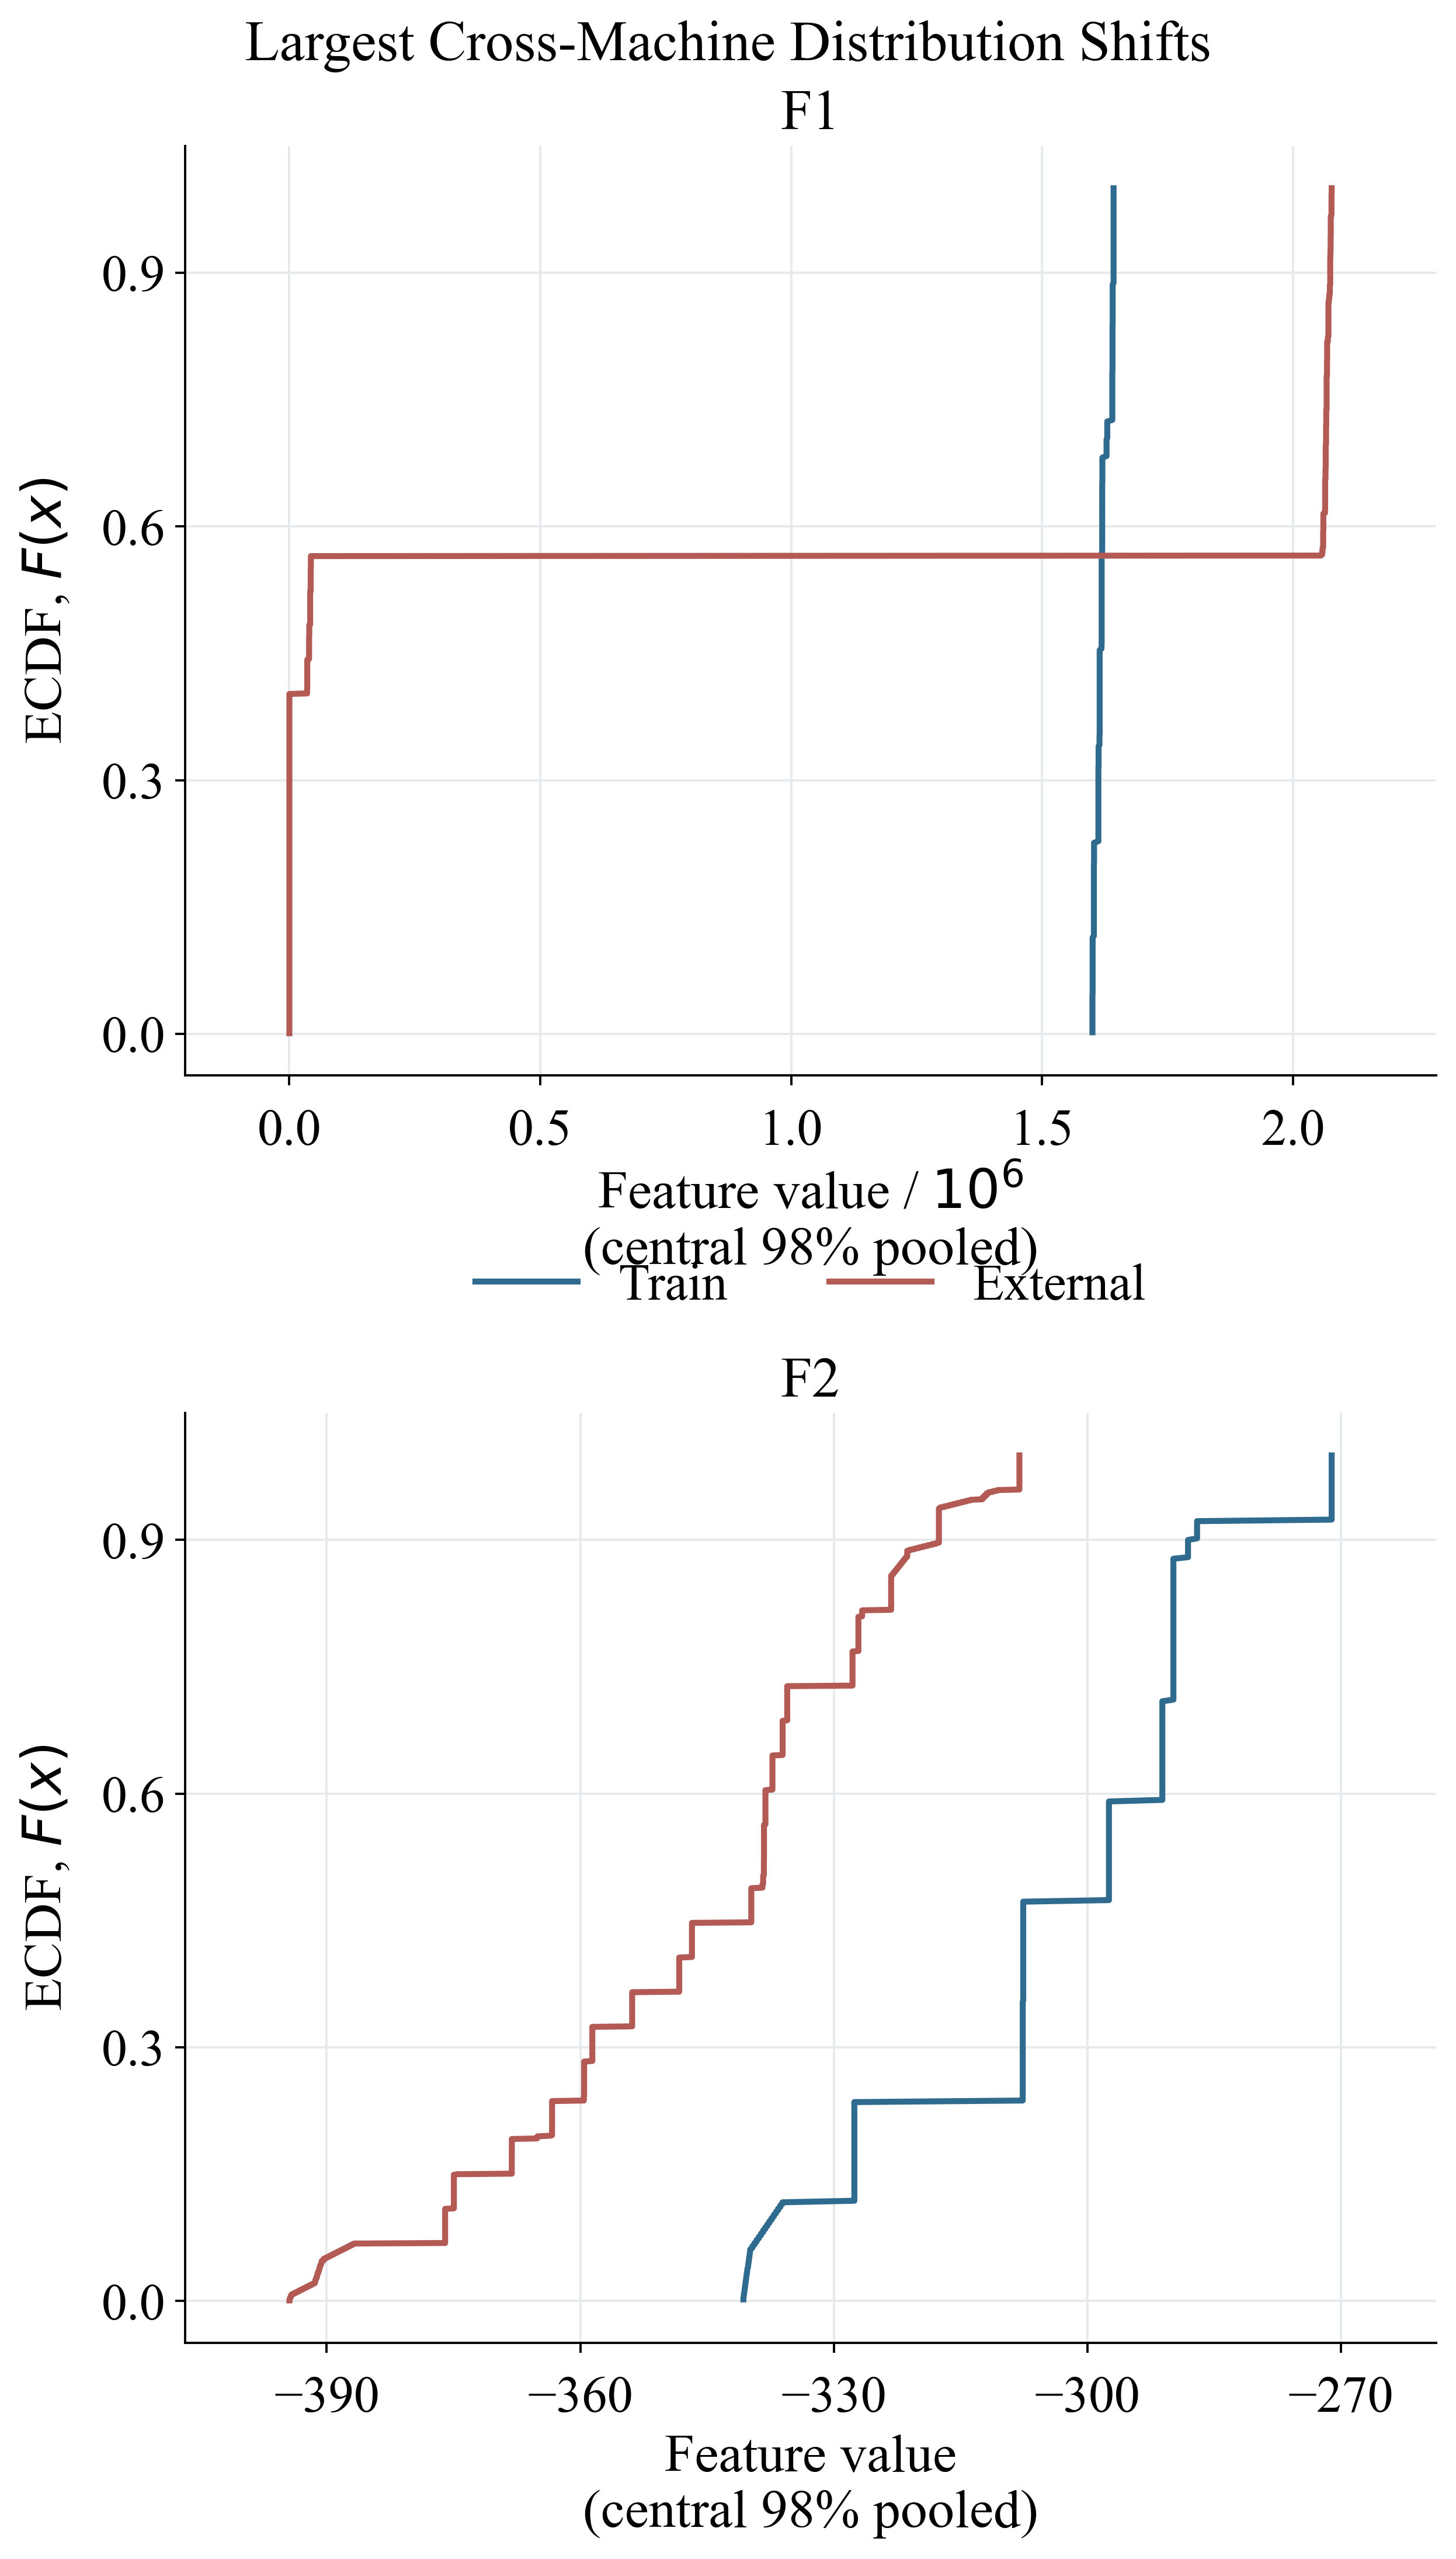

In [64]:
_ = plot_external_shift_ecdfs(
    external_shift_features[2:4], "02_external_shift_ecdf_additional.png"
)


These ECDFs localize the largest label-free cross-machine discrepancies. They justify explicit external transportability reporting and prohibit treating the external machine as exchangeable with development data.

## Leakage-safe representation contract

What exact static and temporal spaces are handed to modeling, and which decisions are fitted exclusively inside development train?

In [65]:
preprocessing_rows = []
preprocessing_rows.append({
    "representation": "Full-path static candidates", "observational_units": len(modeling_dataset),
    "checkpoints": 1, "input_features_or_channels": len(candidate_feature_columns),
    "observed_share": 1.0 - modeling_dataset[candidate_feature_columns].isna().to_numpy().mean(),
    "train_fitted_decision": "No global cleaning; repeated inside each outer training fold",
    "causal_audit_passed": True,
})
preprocessing_rows.append({
    "representation": "Representative static diagnostics", "observational_units": len(modeling_dataset),
    "checkpoints": 1, "input_features_or_channels": len(selected_features),
    "observed_share": 1.0 - modeling_dataset[selected_features].isna().to_numpy().mean(),
    "train_fitted_decision": "Fold-local MI Top 64 after cleaning",
    "causal_audit_passed": True,
})
preprocessing_rows.append({
    "representation": "Fold-local static candidate pool", "observational_units": len(modeling_dataset),
    "checkpoints": len(PREFIXES), "input_features_or_channels": len(candidate_feature_columns),
    "observed_share": 1.0 - modeling_dataset[candidate_feature_columns].isna().to_numpy().mean(),
    "train_fitted_decision": "Fold-local MI Top 64 after cleaning",
    "causal_audit_passed": True,
})
preprocessing_rows.append({
    "representation": "Causal static prefixes",
    "observational_units": prefix_features["cutting_path_id"].nunique(),
    "checkpoints": len(PREFIXES), "input_features_or_channels": len(MODEL_FEATURE_COLUMNS),
    "observed_share": 1.0 - prefix_features[MODEL_FEATURE_COLUMNS].isna().to_numpy().mean(),
    "train_fitted_decision": "Train-only categorical frequency maps",
    "causal_audit_passed": bool(leakage_check["all_source_times_causal"].all()),
})
preprocessing_rows.append({
    "representation": "Temporal numeric tensors", "observational_units": len(ordered_paths),
    "checkpoints": len(prefix_steps), "input_features_or_channels": len(NUMERIC_SEQUENCE_NAMES),
    "observed_share": float(M_num.mean()),
    "train_fitted_decision": "Masked interpolation on causal prefix grids",
    "causal_audit_passed": True,
})


In [66]:
preprocessing_rows.append({
    "representation": "Temporal categorical tensors", "observational_units": len(ordered_paths),
    "checkpoints": len(prefix_steps),
    "input_features_or_channels": len(CATEGORICAL_SEQUENCE_NAMES),
    "observed_share": float(M_cat.mean()),
    "train_fitted_decision": "Train-only vocabularies with unknown token",
    "causal_audit_passed": True,
})
preprocessing_space = pd.DataFrame(preprocessing_rows)
display_grouped_tables(
    preprocessing_space.drop(columns="causal_audit_passed"),
    identifier_columns=["representation"],
    column_groups={
        "Representation dimensions": [
            "observational_units", "checkpoints", "input_features_or_channels", "observed_share",
        ],
        "Training transformations": ["train_fitted_decision"],
    },
    digits=4,
)


#### Representation dimensions

,representation,observational_units,checkpoints,input_features_or_channels,observed_share
0,Full-path static candidates,2512,1,1015,0.9947
1,Representative static diagnostics,2512,1,12,0.9987
2,Fold-local static candidate pool,2512,4,1015,0.9947
3,Causal static prefixes,2512,4,1026,0.9910
4,Temporal numeric tensors,2512,4,35,0.5738
5,Temporal categorical tensors,2512,4,8,0.5738


#### Training transformations

,representation,train_fitted_decision
0,Full-path static candidates,No global cleaning; repeated inside each outer training fold
1,Representative static diagnostics,Fold-local MI Top 64 after cleaning
2,Fold-local static candidate pool,Fold-local MI Top 64 after cleaning
3,Causal static prefixes,Train-only categorical frequency maps
4,Temporal numeric tensors,Masked interpolation on causal prefix grids
5,Temporal categorical tensors,Train-only vocabularies with unknown token


Causal prefixes, masks, train-only vocabularies, and train-fitted static transformations form distinct representations. The diagnostic MI shortlist does not authorize a global downstream selector: every model-selection fold must repeat feature selection inside its own training partition.

## Experiment-aware feature-selection stability

Are the train-selected features reproducibly ranked when each independent development-training experiment is left out, and do they behave as experiment-identity proxies?

In [67]:
train_experiment_ids = sorted(
    modeling_dataset.loc[train_mask, "experiment_group_id"].unique()
)
stability_records = []
for held_experiment in train_experiment_ids:
    fit_rows = train_mask & ~modeling_dataset["experiment_group_id"].eq(held_experiment)
    fit_frame = modeling_dataset.loc[fit_rows, clean_feature_columns]
    fit_target = modeling_dataset.loc[fit_rows, "InterventionRequired"].to_numpy(dtype=int)
    fit_medians = fit_frame.median()
    fit_imputed = fit_frame.fillna(fit_medians)
    usable = [
        feature for feature in clean_feature_columns
        if fit_imputed[feature].notna().all() and fit_imputed[feature].nunique() > 1
    ]
    mi_values = mutual_info_classif(
        fit_imputed[usable], fit_target,
        random_state=SEED + len(stability_records),
    )
    ranking = pd.Series(mi_values, index=usable).sort_values(ascending=False)
    fold_selected = []
    family_counts = defaultdict(int)
    for feature in ranking.index:
        family = feature.split("__", 1)[0] if "__" in feature else "process_metadata"
        if family_counts[family] < 2:
            fold_selected.append(feature)
            family_counts[family] += 1
        if len(fold_selected) == 12:
            break
    ranks = {feature: rank + 1 for rank, feature in enumerate(ranking.index)}
    for feature in selected_features:
        stability_records.append(
            {
                "held_experiment": held_experiment,
                "feature": feature,
                "rank": ranks.get(feature, np.nan),
                "selected": feature in fold_selected,
            }
        )
stability_long = pd.DataFrame(stability_records)
proxy_rows = []


In [68]:
train_frame = modeling_dataset.loc[train_mask]
for feature in selected_features:
    values = pd.to_numeric(train_frame[feature], errors="coerce")
    filled = values.fillna(values.median())
    group_means = filled.groupby(train_frame["experiment_group_id"]).mean()
    total_variance = float(np.var(filled.to_numpy(), ddof=1))
    between_variance = float(np.var(group_means.to_numpy(), ddof=1))
    proxy_rows.append(
        {
            "feature": feature,
            "between_experiment_variance_ratio": (
                min(1.0, between_variance / total_variance) if total_variance > 0 else 0.0
            ),
            "pooled_absolute_pearson_with_target": abs(float(
                stats.pearsonr(filled, train_frame["InterventionRequired"]).statistic
            )),
        }
    )
proxy_diagnostics = pd.DataFrame(proxy_rows)
feature_selection_stability = (
    stability_long.groupby("feature", as_index=False)
    .agg(
        loeo_selection_frequency=("selected", "mean"),
        median_loeo_rank=("rank", "median"),
        q25_loeo_rank=("rank", lambda values: values.quantile(0.25)),
        q75_loeo_rank=("rank", lambda values: values.quantile(0.75)),
    )
    .merge(proxy_diagnostics, on="feature", validate="one_to_one")
)
feature_selection_stability["feature_code"] = feature_selection_stability["feature"].map(feature_codes)
feature_selection_stability["full_train_mutual_information"] = feature_selection_stability["feature"].map(mutual_information_rank)
feature_selection_stability = feature_selection_stability.sort_values("feature_code")


In [69]:
display_grouped_tables(
    feature_selection_stability,
    identifier_columns=["feature_code", "feature"],
    column_groups={
        "Leave-one-experiment-out stability": [
            "loeo_selection_frequency", "median_loeo_rank", "q25_loeo_rank", "q75_loeo_rank",
        ],
        "Association and identity-proxy diagnostics": [
            "full_train_mutual_information", "pooled_absolute_pearson_with_target",
            "between_experiment_variance_ratio",
        ],
    },
    digits=4,
)


#### Leave-one-experiment-out stability

,feature_code,feature,loeo_selection_frequency,median_loeo_rank,q25_loeo_rank,q75_loeo_rank
0,F1,machine_time__mean,1.0000,1.0000,1.0000,1.0000
1,F10,zmapeak__energy,0.3636,15.0000,11.5000,19.5000
2,F11,smvrms__energy,0.6364,11.0000,10.0000,16.0000
3,F12,spindle_time__energy,0.4545,13.0000,11.5000,18.5000
4,F2,z_position__mean,1.0000,3.0000,3.0000,4.5000
5,F3,Tool__train_frequency,1.0000,4.0000,2.0000,5.0000
6,F4,available_duration_s,1.0000,5.0000,4.5000,8.0000
7,F5,smarms__energy,0.9091,6.0000,5.0000,9.0000
8,F6,part_count__mean,1.0000,5.0000,3.5000,7.0000
9,F7,smapeak__energy,0.9091,7.0000,7.0000,9.0000


#### Association and identity-proxy diagnostics

,feature_code,feature,full_train_mutual_information,pooled_absolute_pearson_with_target,between_experiment_variance_ratio
0,F1,machine_time__mean,0.4588,0.2246,1.0000
1,F10,zmapeak__energy,0.3678,0.5816,0.3630
2,F11,smvrms__energy,0.3677,0.7814,0.9202
3,F12,spindle_time__energy,0.3676,0.7771,0.9709
4,F2,z_position__mean,0.4143,0.0328,0.9634
5,F3,Tool__train_frequency,0.4086,0.2251,1.0000
6,F4,available_duration_s,0.4011,0.7917,1.0000
7,F5,smarms__energy,0.4009,0.7634,0.7628
8,F6,part_count__mean,0.3995,0.2072,1.0000
9,F7,smapeak__energy,0.3933,0.7542,0.7088


Selection frequency and rank dispersion expose instability hidden by a single pooled MI ranking. A large between-experiment variance ratio flags potential experiment/machine identity proxies; such features require fold-local selection and subgroup sensitivity rather than causal interpretation.

## Multicollinearity diagnostics

Which selected features are linearly redundant after train-only robust scaling, and what is the global conditioning of the diagnostic matrix?

In [70]:
condition_number = float(np.linalg.cond(selected_train_scaled))
vif_rows = []
for feature_index, feature in enumerate(selected_features):
    other_indices = [index for index in range(len(selected_features)) if index != feature_index]
    regression = LinearRegression().fit(
        selected_train_scaled[:, other_indices],
        selected_train_scaled[:, feature_index],
    )
    r_squared = regression.score(
        selected_train_scaled[:, other_indices],
        selected_train_scaled[:, feature_index],
    )
    tolerance = max(1.0 - r_squared, np.finfo(float).eps)
    vif_rows.append(
        {
            "feature": feature,
            "n_train": int(train_mask.sum()),
            "r_squared_from_others": r_squared,
            "tolerance": tolerance,
            "variance_inflation_factor": 1.0 / tolerance,
            "global_condition_number": condition_number,
        }
    )
multicollinearity_diagnostics = pd.DataFrame(vif_rows).sort_values(
    "variance_inflation_factor", ascending=False
)
multicollinearity_diagnostics["feature_code"] = multicollinearity_diagnostics["feature"].map(feature_codes)
display_grouped_tables(
    multicollinearity_diagnostics,
    identifier_columns=["feature_code", "feature", "n_train"],
    column_groups={
        "Feature-level collinearity": [
            "r_squared_from_others", "tolerance", "variance_inflation_factor",
        ],
        "Global matrix conditioning": ["global_condition_number"],
    },
    digits=4,
)


#### Feature-level collinearity

,feature_code,feature,n_train,r_squared_from_others,tolerance,variance_inflation_factor
0,F12,spindle_time__energy,563,1.0000,0.0000,41388.0023
1,F9,machine_time__energy,563,1.0000,0.0000,41032.7488
2,F6,part_count__mean,563,0.9883,0.0117,85.4428
3,F1,machine_time__mean,563,0.9882,0.0118,84.9355
4,F4,available_duration_s,563,0.9747,0.0253,39.4655
5,F7,smapeak__energy,563,0.9567,0.0433,23.0757
6,F5,smarms__energy,563,0.9457,0.0543,18.4073
7,F11,smvrms__energy,563,0.8207,0.1793,5.5761
8,F8,ymapeak__energy,563,0.7889,0.2111,4.7379
9,F10,zmapeak__energy,563,0.6424,0.3576,2.7965


#### Global matrix conditioning

,feature_code,feature,n_train,global_condition_number
0,F12,spindle_time__energy,563,3683.3069
1,F9,machine_time__energy,563,3683.3069
2,F6,part_count__mean,563,3683.3069
3,F1,machine_time__mean,563,3683.3069
4,F4,available_duration_s,563,3683.3069
5,F7,smapeak__energy,563,3683.3069
6,F5,smarms__energy,563,3683.3069
7,F11,smvrms__energy,563,3683.3069
8,F8,ymapeak__energy,563,3683.3069
9,F10,zmapeak__energy,563,3683.3069


VIF, the condition number, and Pearson $r$ diagnose linear redundancy; normalized MI and held-out XGBoost $R^2$ address nonlinear dependence. No feature is removed solely because a pooled diagnostic is large.

## Outlier and support diagnostics

How large is the split-wise outlier burden under train-fitted isolation and robust-distance criteria?

In [71]:
isolation_model = IsolationForest(
    n_estimators=400,
    contamination="auto",
    max_samples="auto",
    n_jobs=N_JOBS,
    random_state=SEED,
)
isolation_model.fit(selected_train_scaled)
isolation_scores = -isolation_model.score_samples(selected_all_scaled)
isolation_threshold = float(np.quantile(isolation_scores[train_mask.to_numpy()], 0.95))
robust_distance = np.sqrt(np.mean(np.square(selected_all_scaled), axis=1))
robust_threshold = float(np.quantile(robust_distance[train_mask.to_numpy()], 0.95))
modeling_dataset["isolation_anomaly_score"] = isolation_scores.astype("float32")
modeling_dataset["robust_anomaly_score"] = robust_distance.astype("float32")
outlier_rows = []
for split_name in split_order:
    rows = modeling_dataset["split"].eq(split_name).to_numpy()
    isolation_outlier = isolation_scores[rows] > isolation_threshold
    robust_outlier = robust_distance[rows] > robust_threshold
    outlier_rows.append(
        {
            "split": split_name,
            "n": int(rows.sum()),
            "isolation_outlier_n": int(isolation_outlier.sum()),
            "isolation_outlier_percent": 100.0 * isolation_outlier.mean(),
            "robust_outlier_n": int(robust_outlier.sum()),
            "robust_outlier_percent": 100.0 * robust_outlier.mean(),
            "criterion_agreement_percent": 100.0 * np.mean(isolation_outlier == robust_outlier),
        }
    )
outlier_summary = pd.DataFrame(outlier_rows)


In [72]:
display_grouped_tables(
    outlier_summary,
    identifier_columns=["split", "n"],
    column_groups={
        "Train-threshold outlier burden": [
            "isolation_outlier_n", "isolation_outlier_percent",
            "robust_outlier_n", "robust_outlier_percent",
        ],
        "Agreement of label-free criteria": ["criterion_agreement_percent"],
    },
    digits=3,
)


#### Train-threshold outlier burden

,split,n,isolation_outlier_n,isolation_outlier_percent,robust_outlier_n,robust_outlier_percent
0,train,563,29,5.151,29,5.151
1,validation,192,13,6.771,4,2.083
2,internal_test,172,1,0.581,1,0.581
3,external,1585,828,52.240,1583,99.874


#### Agreement of label-free criteria

,split,n,criterion_agreement_percent
0,train,563,95.027
1,validation,192,95.312
2,internal_test,172,100.000
3,external,1585,52.366


Thresholds are fixed at development-train 95th percentiles and do not trigger automatic row deletion. A high external burden is interpreted as a failure of support and motivates experiment-level inspection.

### Train-only anomaly enrichment

Are label-free anomalies enriched for intervention paths within development train without using the enrichment to delete rows?

In [73]:
train_positions = np.flatnonzero(train_mask.to_numpy())
enrichment_rows = []
for criterion, scores, threshold in [
    ("Isolation Forest", isolation_scores, isolation_threshold),
    ("Robust distance", robust_distance, robust_threshold),
]:
    flagged = scores[train_positions] > threshold
    outcomes = diagnostic_target.astype(int)
    table = pd.crosstab(flagged, outcomes).reindex(
        index=[False, True], columns=[0, 1], fill_value=0
    )
    flagged_rate = (table.loc[True, 1] + 0.5) / (table.loc[True].sum() + 1.0)
    inlier_rate = (table.loc[False, 1] + 0.5) / (table.loc[False].sum() + 1.0)
    enrichment_rows.append({
        "criterion": criterion, "n_train": len(outcomes),
        "anomaly_n": int(flagged.sum()),
        "anomaly_intervention_rate": flagged_rate,
        "inlier_intervention_rate": inlier_rate,
        "risk_ratio": flagged_rate / inlier_rate,
        "fisher_p_value": stats.fisher_exact(table.to_numpy()).pvalue,
    })
anomaly_enrichment = pd.DataFrame(enrichment_rows)
display_grouped_tables(
    anomaly_enrichment, identifier_columns=["criterion", "n_train"],
    column_groups={"Train-only anomaly enrichment": [
        "anomaly_n", "anomaly_intervention_rate", "inlier_intervention_rate",
        "risk_ratio", "fisher_p_value",
    ]}, digits=4,
)

#### Train-only anomaly enrichment

,criterion,n_train,anomaly_n,anomaly_intervention_rate,inlier_intervention_rate,risk_ratio,fisher_p_value
0,Isolation Forest,563,29,0.9833,0.1841,5.3409,0.0000
1,Robust distance,563,29,0.9833,0.1841,5.3409,0.0000


Enrichment quantifies association only. Both anomaly rules remain label-free, train-fitted diagnostics and never authorize row removal.

### Experiment-level outlier heterogeneity

Is the aggregate outlier burden concentrated in a few experiments, and how do the two label-free scores agree geometrically?

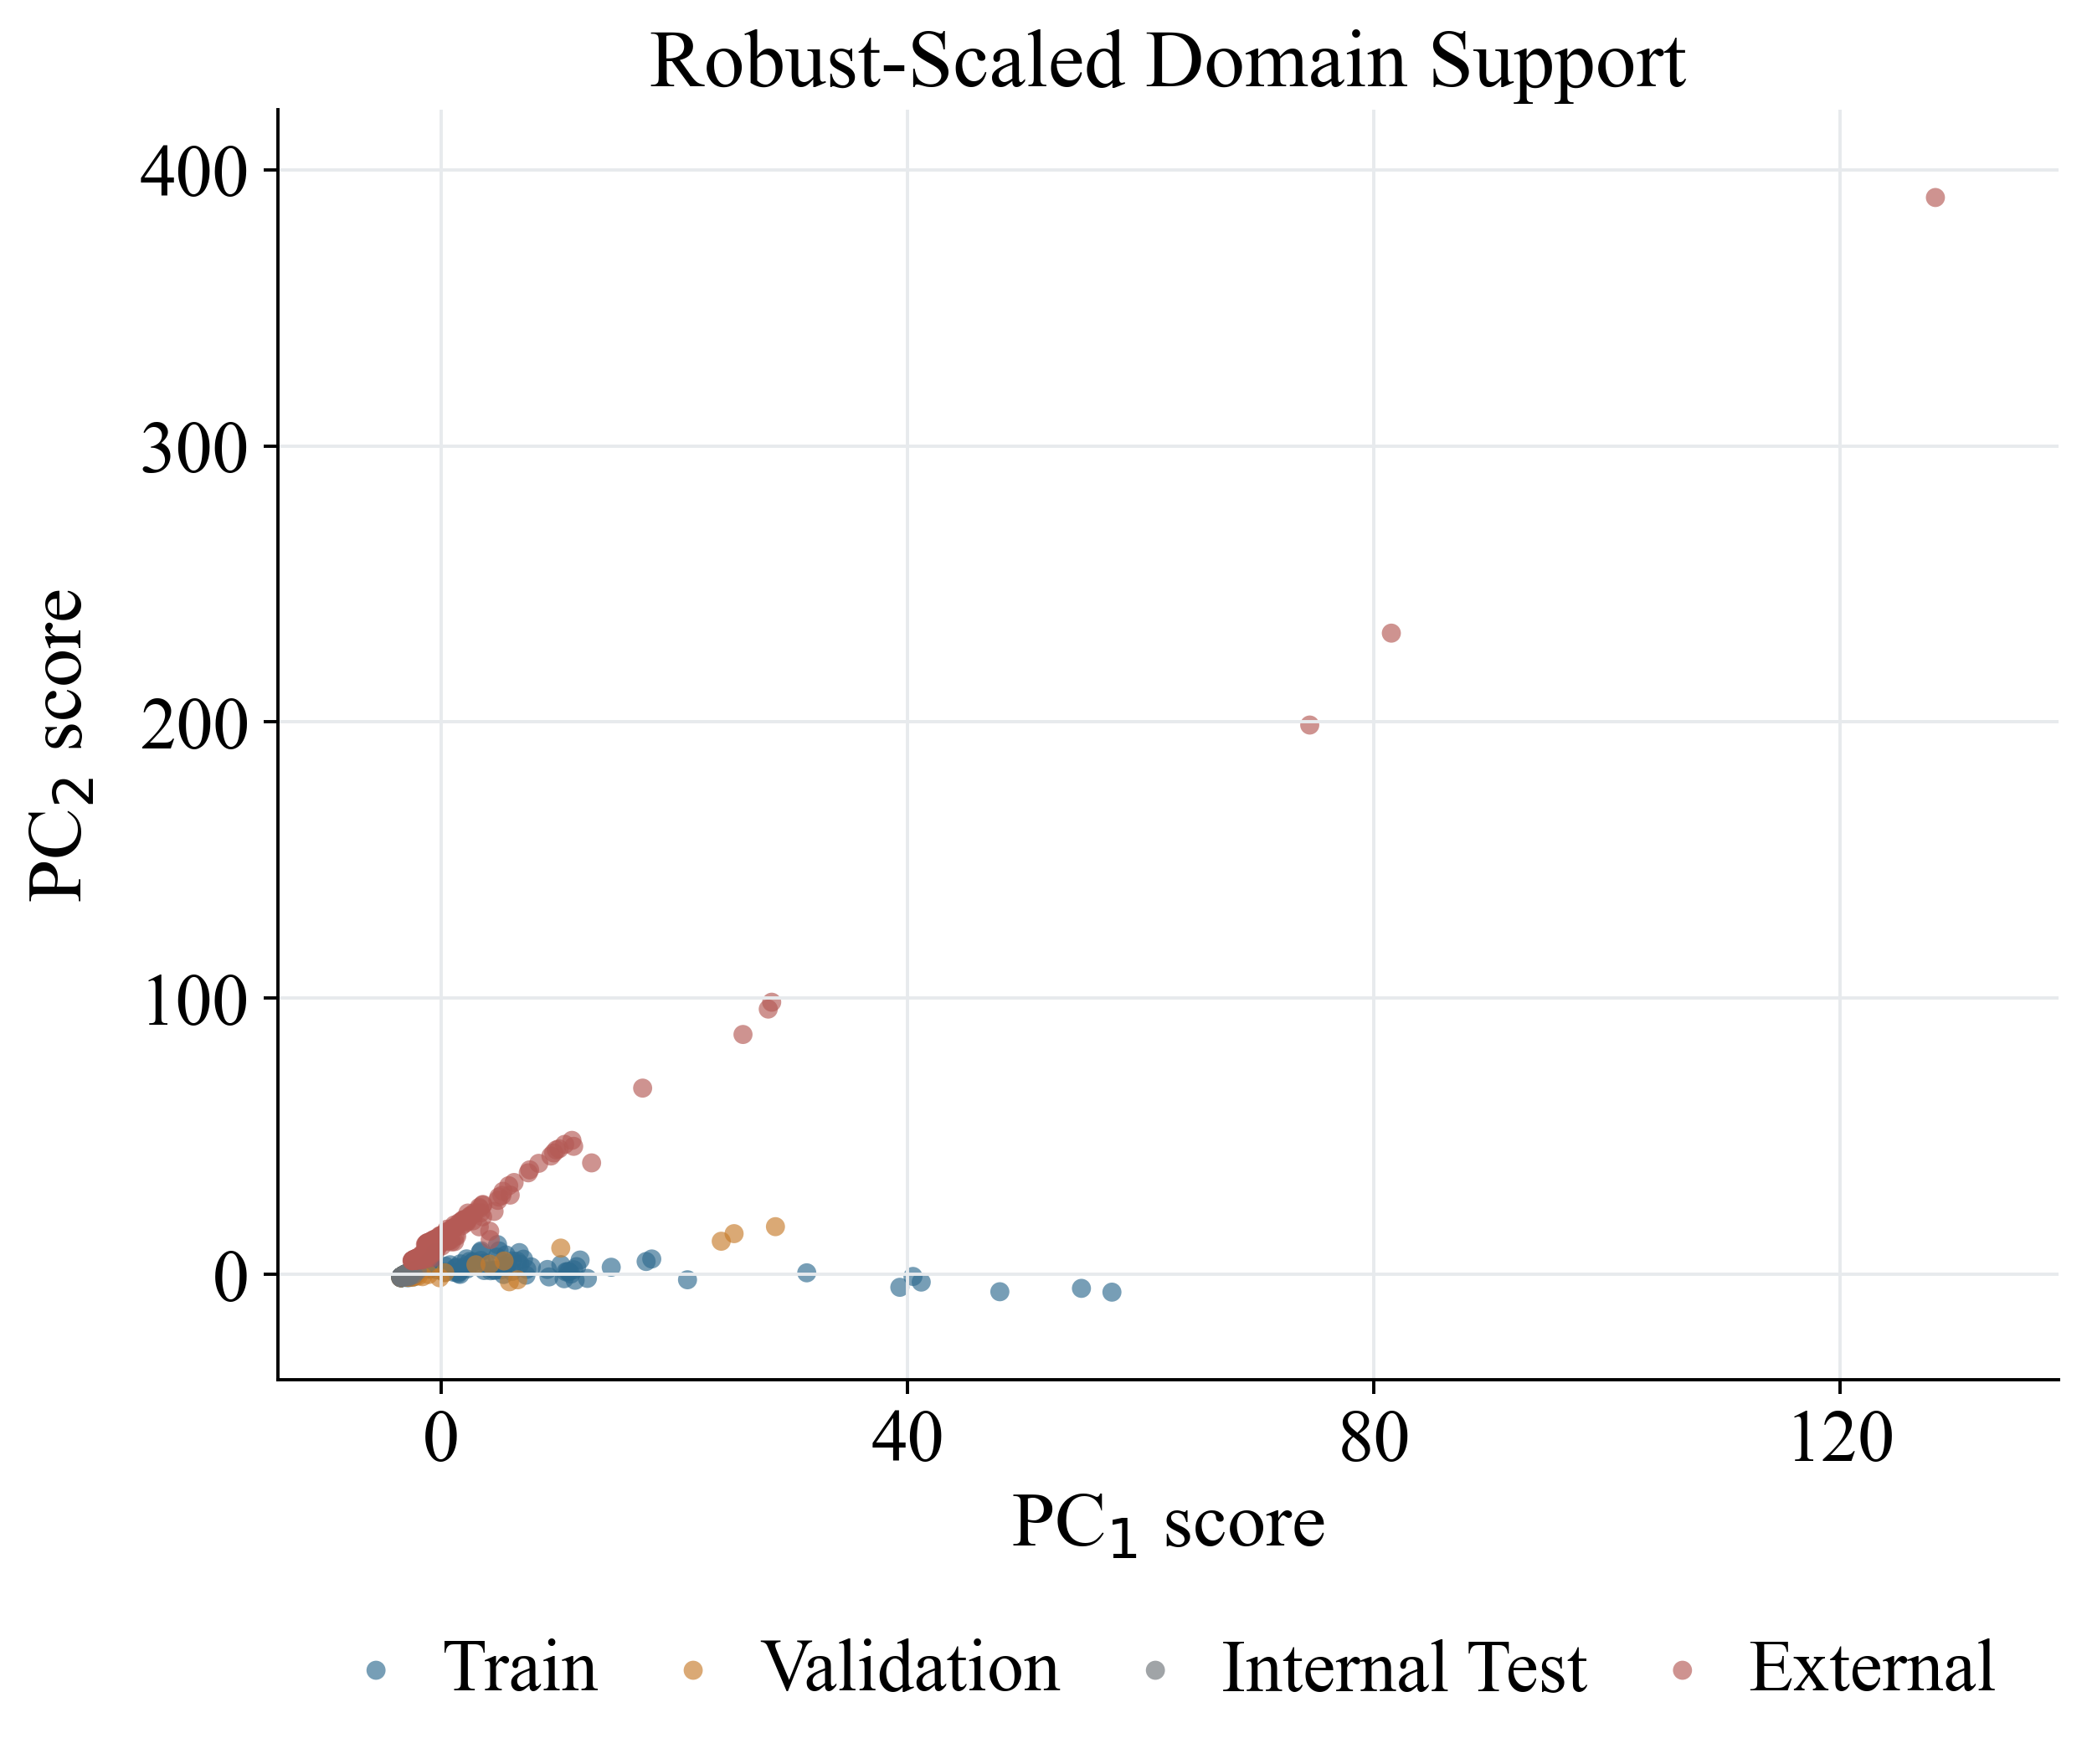

In [74]:
outlier_frame = modeling_dataset[[
    "split", "experiment_group_id", "isolation_anomaly_score", "robust_anomaly_score"
]].copy()
outlier_frame["isolation_flag"] = outlier_frame["isolation_anomaly_score"] > isolation_threshold
outlier_frame["robust_flag"] = outlier_frame["robust_anomaly_score"] > robust_threshold
train_positions = np.flatnonzero(train_mask.to_numpy())
pca = PCA(n_components=2, random_state=SEED)
pca.fit(selected_all_scaled[train_positions])
principal = pca.transform(selected_all_scaled)
fig, ax = figure_subplots(
    1, 1, span="double", legend_items=4, height_mm=150.0
)
for split_index, split_name in enumerate(split_order):
    indices = np.flatnonzero(modeling_dataset["split"].eq(split_name).to_numpy())
    if len(indices) > 320:
        indices = np.random.default_rng(SEED + split_index).choice(indices, size=320, replace=False)
    ax.scatter(
        principal[indices, 0], principal[indices, 1], s=22,
        color=split_colors[split_name], alpha=0.65,
        edgecolor="none", label=split_name.replace("_", " ").title(),
    )
ax.margins(x=0.08, y=0.08)
ax.set_xlabel(r"PC$_1$ score")
ax.set_ylabel(r"PC$_2$ score", labelpad=10)
ax.set_title("Robust-Scaled Domain Support")
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, prune="both"))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, prune="both"))
ax.grid(color=PALETTE["grid"])
legend_below(
    ax, ncol=4, columnspacing=0.8, handlelength=1.0, handletextpad=0.4
)
_ = save_show_figure(fig, FIGURES / "02_outlier_domain_support.png", span="double")


The PCA canvas is a support visualization, not a classifier. Separation or overlap in the robust-scaled PC$_1$–PC$_2$ plane describes multivariate domain support without using outcome labels.

### Experiment-level outlier heterogeneity

Is the train-threshold isolation burden concentrated in a few independent experiments or shifted systematically by domain?

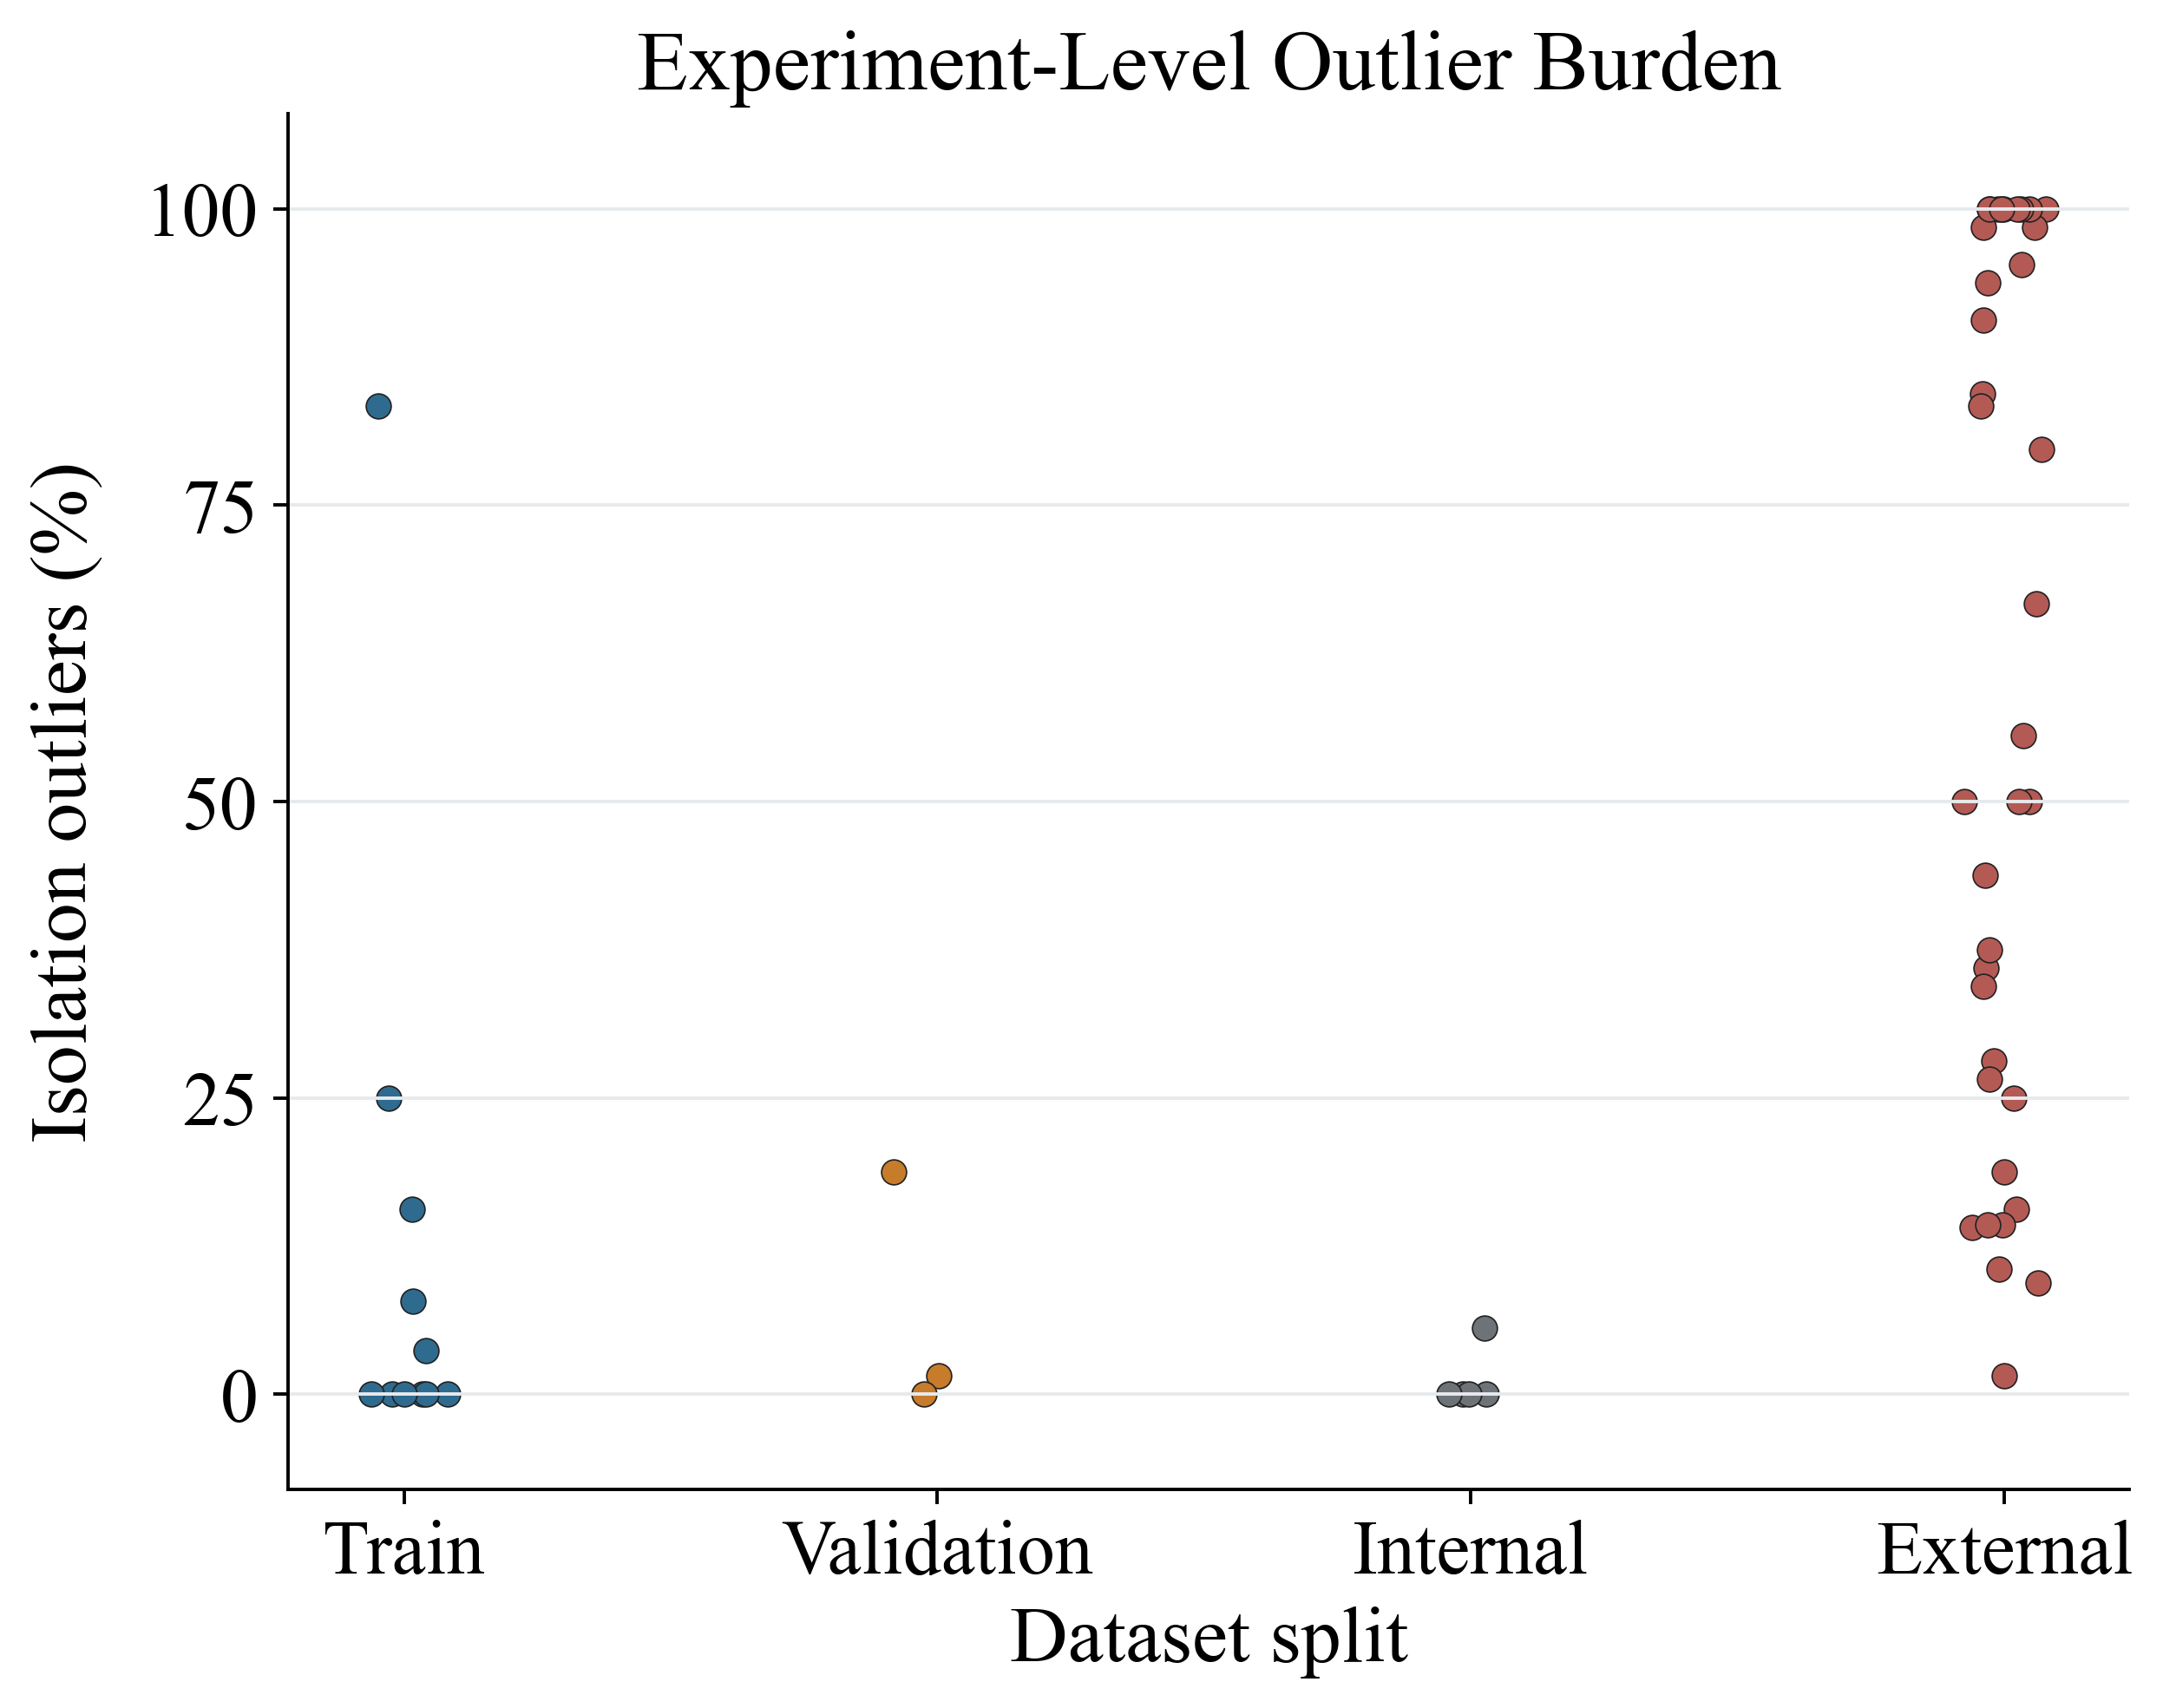

In [75]:
experiment_outlier_support = (
    outlier_frame.groupby(["split", "experiment_group_id"], as_index=False)
    .agg(
        n=("isolation_flag", "size"),
        isolation_outlier_percent=("isolation_flag", lambda values: 100.0 * values.mean()),
        robust_outlier_percent=("robust_flag", lambda values: 100.0 * values.mean()),
    )
)
fig, ax = figure_subplots(1, 1, span="double", height_mm=140.0)
for split_index, split_name in enumerate(split_order):
    values = experiment_outlier_support.loc[
        experiment_outlier_support["split"].eq(split_name),
        "isolation_outlier_percent",
    ].to_numpy()
    x = np.full(len(values), split_index, dtype=float)
    x += np.random.default_rng(SEED + 20 + split_index).normal(0.0, 0.045, len(values))
    ax.scatter(
        x, values, s=35, color=split_colors[split_name],
        edgecolor=PALETTE["black"], linewidth=0.35,
    )
ax.set_xticks(np.arange(4), ["Train", "Validation", "Internal", "External"])
ax.set_xlabel("Dataset split")
ax.set_ylabel("Isolation outliers (%)", labelpad=10)
ax.set_title("Experiment-Level Outlier Burden")
ax.margins(y=0.08)
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, prune="upper"))
ax.grid(axis="y", color=PALETTE["grid"])
_ = save_show_figure(fig, FIGURES / "02_experiment_outlier_burden.png", span="double")


The independent-experiment distribution reveals whether an aggregate external flag rate reflects systematic domain displacement or a small number of isolated paths. No observations are deleted from modeling on this basis.

## Nonlinear train-fitted support geometry

Does an unsupervised UMAP fitted only on development-train reveal domain support or cross-machine separation beyond the linear PCA view?


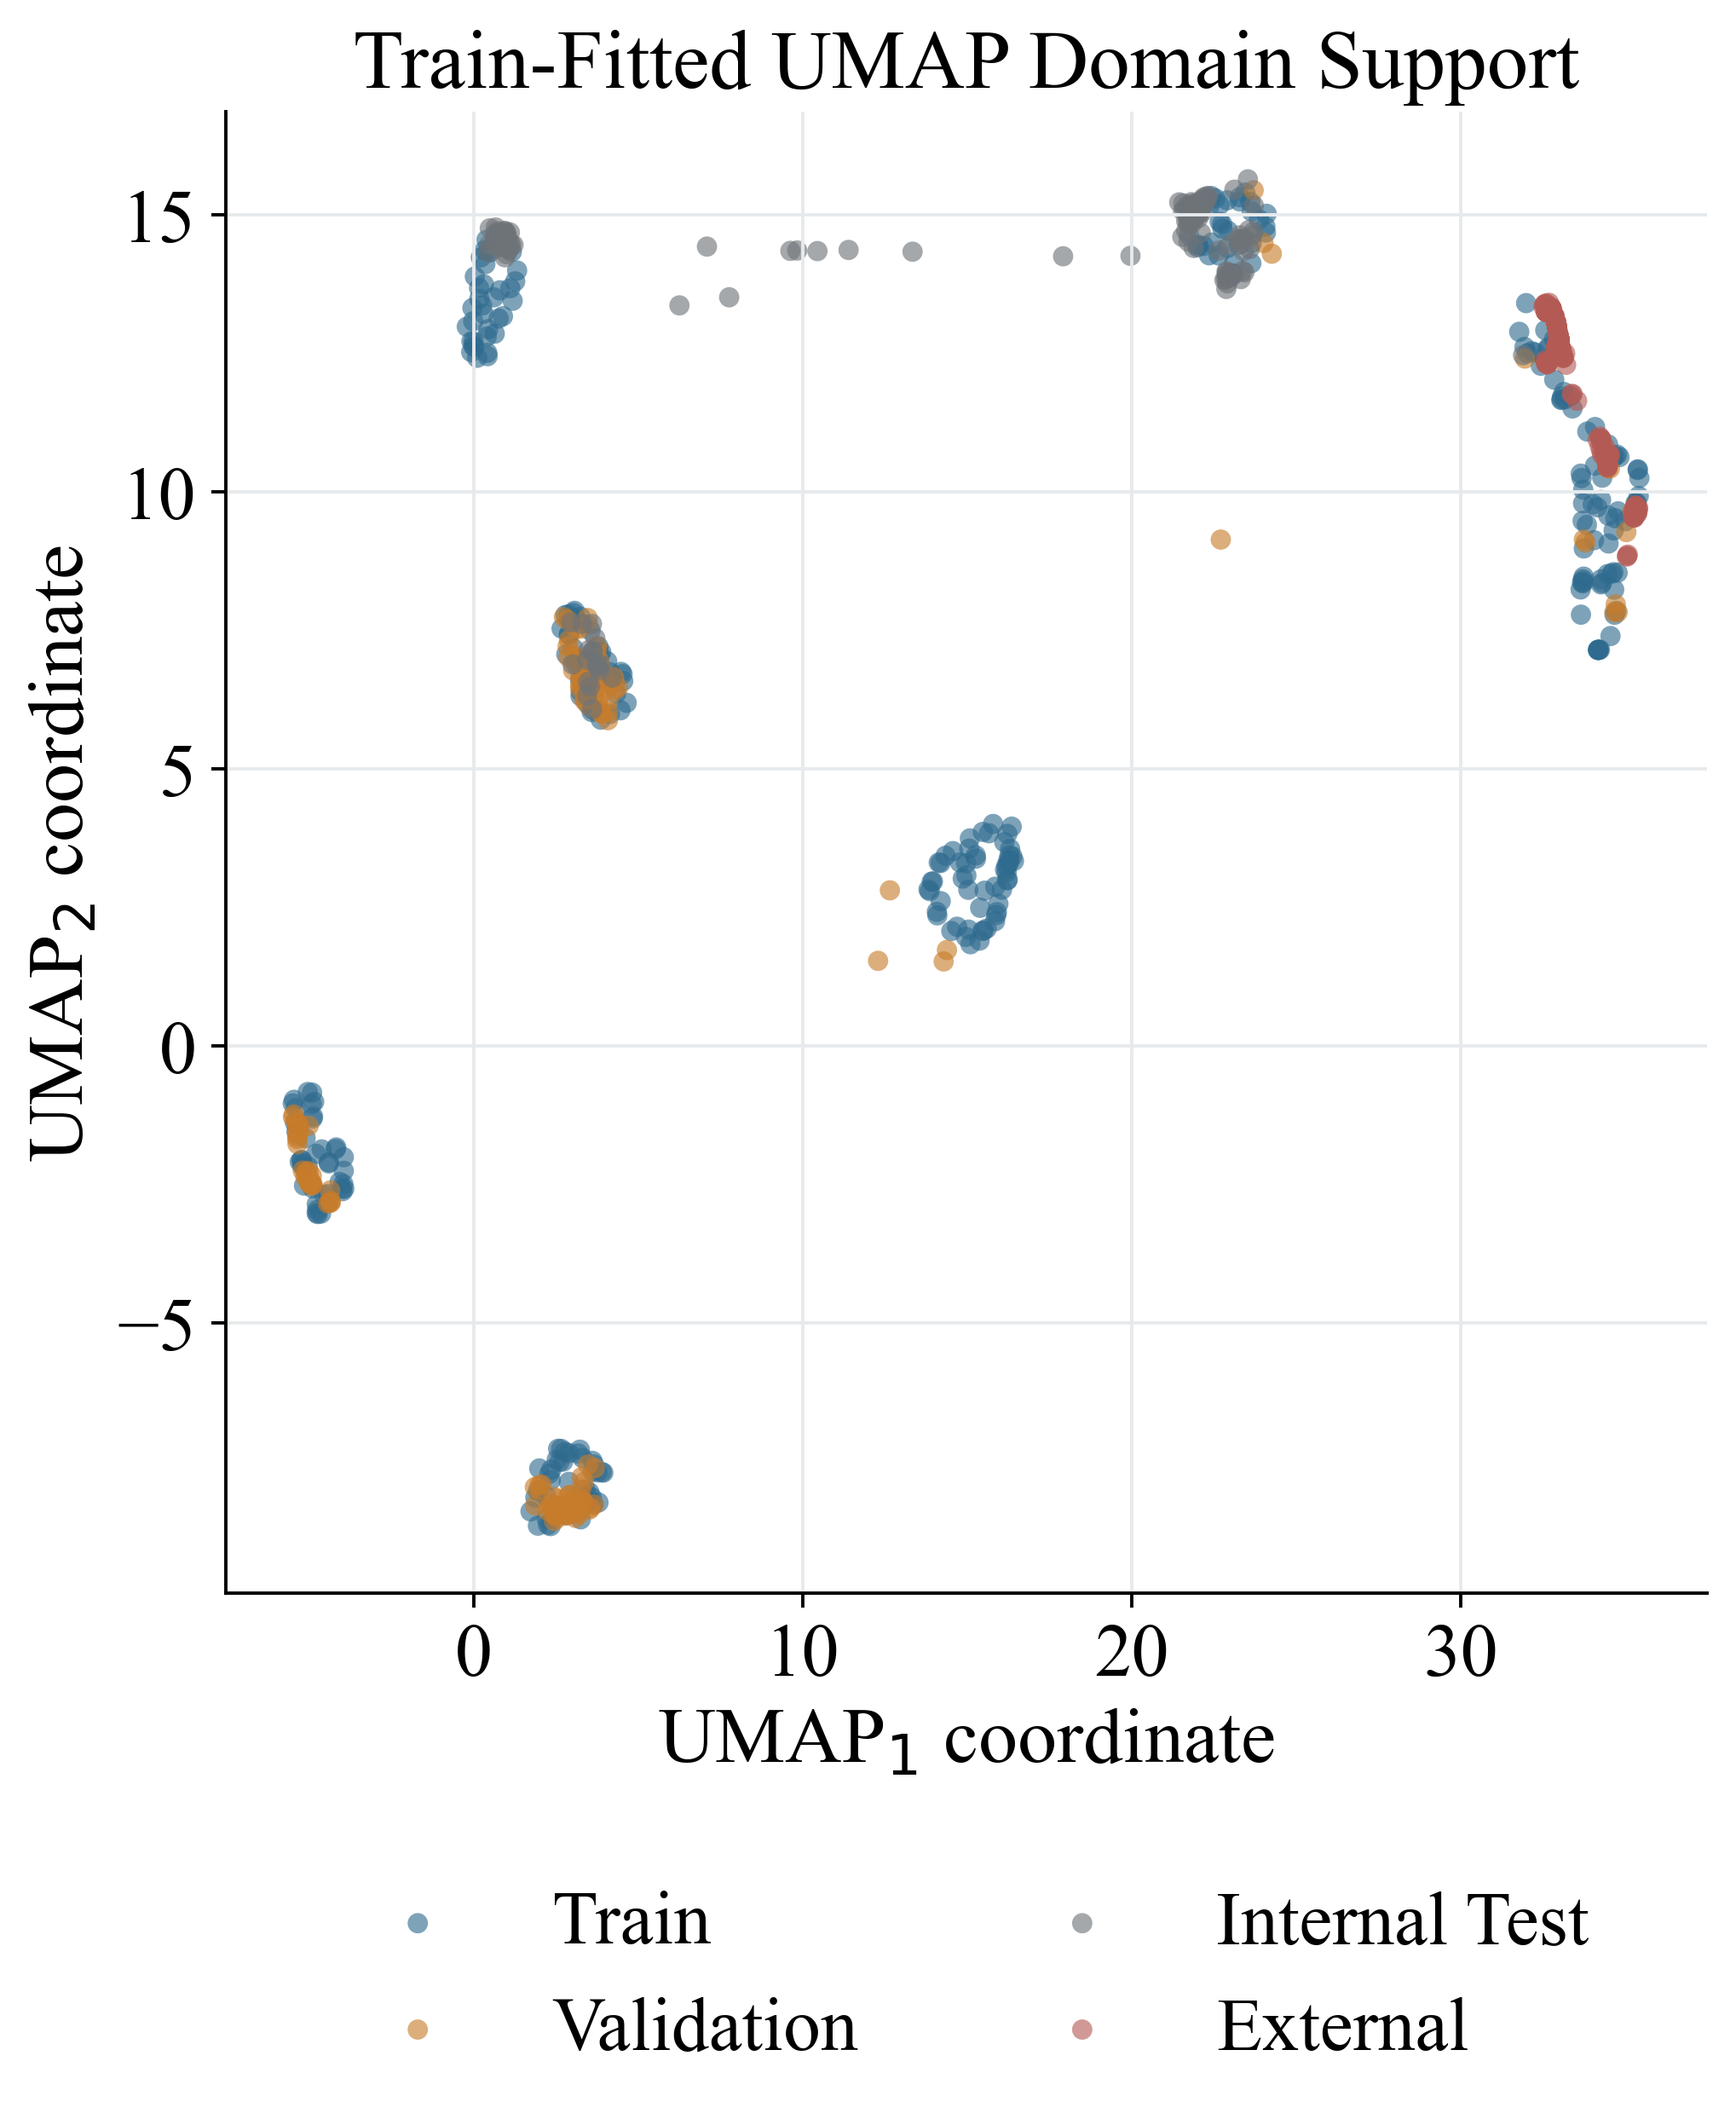

In [76]:
umap_model = UMAP(
    n_components=2, n_neighbors=25, min_dist=0.15,
    metric="euclidean", random_state=SEED, transform_seed=SEED, n_jobs=1,
)
train_positions = np.flatnonzero(train_mask.to_numpy())
umap_model.fit(selected_all_scaled[train_positions])
umap_embedding = umap_model.transform(selected_all_scaled)
fig, axis = figure_subplots(1, 1, span="double", square_panel=True, height_mm=178.0)
for split_index, split_name in enumerate(split_order):
    indices = np.flatnonzero(modeling_dataset["split"].eq(split_name).to_numpy())
    if len(indices) > 320:
        indices = np.random.default_rng(SEED + split_index).choice(
            indices, size=320, replace=False
        )
    axis.scatter(
        umap_embedding[indices, 0], umap_embedding[indices, 1],
        s=24, alpha=0.62, color=split_colors[split_name], edgecolor="none",
        label=split_name.replace("_", " ").title(),
    )
axis.set_xlabel(r"UMAP$_1$ coordinate")
axis.set_ylabel(r"UMAP$_2$ coordinate")
axis.set_title("Train-Fitted UMAP Domain Support")
axis.grid(color=PALETTE["grid"])
legend_below(axis, ncol=2)
_ = save_show_figure(fig, FIGURES / "02_umap_domain_support.png", span="double")


UMAP receives no target labels and is fitted only on the development-training representation. Separation is evidence of covariate support shift, not classification accuracy.


In [77]:
# Save feature representations and result tables
prefix_features.to_parquet(PROCESSED / "causal_prefix_features.parquet", index=False)
modeling_dataset.to_parquet(UNIFIED / "modeling_dataset.parquet", index=False)
np.savez_compressed(
    PROCESSED / "temporal_sequences.npz",
    X_num=X_num,
    num_mask=M_num,
    X_cat=X_cat,
    cat_mask=M_cat,
    path_ids=ordered_paths["cutting_path_id"].to_numpy(str),
    prefix_steps=prefix_steps,
    numeric_features=np.asarray(NUMERIC_SEQUENCE_NAMES),
    categorical_features=np.asarray(CATEGORICAL_SEQUENCE_NAMES),
    category_vocab_sizes=np.asarray(
        [len(category_vocabs[key]) for key in CATEGORICAL_SEQUENCE_NAMES],
        dtype=np.int16,
    ),
)
split_indices = {
    split_name: np.flatnonzero(modeling_dataset["split"].eq(split_name))
    for split_name in split_order
}
np.savez_compressed(
    UNIFIED / "split_indices.npz",
    train=split_indices["train"],
    validation=split_indices["validation"],
    internal_test=split_indices["internal_test"],
    external=split_indices["external"],
    cv_fold=modeling_dataset["cv_fold"].to_numpy(np.int16),
    path_ids=modeling_dataset["cutting_path_id"].to_numpy(str),
)
semantic_harmonization.to_csv(TABLES / "semantic_harmonization.csv", index=False)
semantic_attrition.to_csv(TABLES / "semantic_attrition.csv", index=False)
prefix_tensor_support.to_csv(TABLES / "prefix_tensor_support.csv", index=False)
cleaning_attrition.to_csv(TABLES / "cleaning_attrition.csv", index=False)
feature_group_summary.to_csv(TABLES / "feature_group_summary.csv", index=False)
leakage_check.to_csv(TABLES / "causal_prefix_leakage_check.csv", index=False)
descriptive_statistics.to_csv(TABLES / "descriptive_statistics.csv", index=False)
multicollinearity_diagnostics.to_csv(TABLES / "multicollinearity_diagnostics.csv", index=False)
outlier_summary.to_csv(TABLES / "outlier_summary.csv", index=False)


In [78]:
missingness_summary.to_csv(TABLES / "missingness_summary.csv", index=False)
comissingness_mapping.to_csv(TABLES / "comissingness_mapping.csv", index=False)
feature_selection_stability.to_csv(TABLES / "feature_selection_stability.csv", index=False)
experiment_outlier_support.to_csv(TABLES / "experiment_outlier_support.csv", index=False)
domain_shift_metrics.to_csv(TABLES / "domain_shift_metrics.csv", index=False)
preprocessing_space.to_csv(TABLES / "preprocessing_space.csv", index=False)
domain_classifier_summary.to_csv(TABLES / "domain_classifier_summary.csv", index=False)
anomaly_enrichment.to_csv(TABLES / "anomaly_enrichment.csv", index=False)
proxy_policy.to_csv(TABLES / "proxy_feature_policy.csv", index=False)
target_association_comparison.to_csv(
    TABLES / "target_association_comparison.csv", index=False
)
grouped_permutation_importance.to_csv(
    TABLES / "grouped_permutation_importance.csv", index=False
)
pd.DataFrame(pearson_matrix, index=feature_codes.values(), columns=feature_codes.values()).to_csv(
    TABLES / "pearson_dependence_matrix.csv"
)
pd.DataFrame(mutual_information_matrix, index=feature_codes.values(), columns=feature_codes.values()).to_csv(
    TABLES / "mutual_information_matrix.csv"
)
pd.DataFrame(xgb_nonlinear_matrix, index=feature_codes.values(), columns=feature_codes.values()).to_csv(
    TABLES / "xgboost_nonlinear_dependency_matrix.csv"
)


In [79]:
feature_selection_summary = pd.DataFrame({
    "feature": numeric_candidates,
    "train_mutual_information": [
        mutual_information_rank.get(feature, np.nan) for feature in numeric_candidates
    ],
    "diagnostic_selected": [
        feature in selected_features for feature in numeric_candidates
    ],
    "eligible_primary_candidate": [
        feature in candidate_feature_columns for feature in numeric_candidates
    ],
    "proxy_sensitivity_only": [
        feature in proxy_sensitivity_columns for feature in numeric_candidates
    ],
    "train_missing_percent": [
        100.0 * modeling_dataset.loc[train_mask, feature].isna().mean()
        for feature in numeric_candidates
    ],
})
feature_selection_summary.to_csv(
    TABLES / "preprocessing_feature_summary.csv", index=False
)
candidate_columns = list(dict.fromkeys(
    IDENTIFIER_COLUMNS + ["prefix_fraction"] + candidate_feature_columns
))
modeling_dataset.loc[:, candidate_columns].to_parquet(
    UNIFIED / "full_cleaned_candidate_pool.parquet", index=False
)


In [80]:
fold_local_transform_rules = {
    "seed": SEED,
    "fit_boundary": "each development training fold only",
    "prefixes": PREFIXES,
    "sequence_length": SEQUENCE_LENGTH,
    "candidate_static_features": candidate_feature_columns,
    "categorical_model_features": META_CATEGORICAL,
    "proxy_sensitivity_features": proxy_sensitivity_columns,
    "diagnostic_features_not_frozen_for_modeling": selected_features,
    "cleaning": [
        "remove fold-all-missing", "remove fold-constant",
        "remove exact duplicates",
    ],
    "imputation": "fold median plus missingness indicators",
    "scaling": "fold robust scaler for scale-sensitive models only",
    "selection": "fold-local mutual information Top 64",
    "selection_top_k": 64,
    "final_refit_selection": "recomputed once after architecture freeze",
    "calibration": "inner OOF only",
    "threshold": "inner OOF only",
    "external_labels_used": False,
}
_ = (UNIFIED / "fold_local_transform_rules.json").write_text(
    json.dumps(fold_local_transform_rules, indent=2, sort_keys=True),
    encoding="utf-8",
)
preprocessing_contract = fold_local_transform_rules.copy()
preprocessing_contract.update({
    "numeric_sequence_features": NUMERIC_SEQUENCE_NAMES,
    "categorical_sequence_features": CATEGORICAL_SEQUENCE_NAMES,
})
_ = (UNIFIED / "preprocessing_contract.json").write_text(
    json.dumps(preprocessing_contract, indent=2, sort_keys=True), encoding="utf-8"
)


## Summary

The study space contains experiment nesting, engineered incompleteness, nonlinear dependence, anomaly enrichment, and measurable cross-machine covariate shift. Pearson, normalized MI, and held-out XGBoost diagnostics show complementary structure, while SHAP remains descriptive rather than causal. Notebook 03 receives the full proxy-screened candidate pool with fold-local preprocessing: all-NA removal, constant removal, exact-duplicate removal, MI Top 64 selection, imputation, scaling, calibration, and threshold selection are repeated within the corresponding development-training fold. Internal and external outcome labels remain excluded from fitting and selection.